<a href="https://colab.research.google.com/github/MuhammadHakami/NeuroAi-EmbodiedAI/blob/main/notebooks/4-monkey-net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model ↔ brain comparison: monkey S1/M1 + human MEG

*Click the badge to run this notebook in Google Colab — the setup cell below installs
everything and fetches trained weights on demand. GPU runtime recommended.*


In [1]:
# @title Setup (Google Colab) — run me first  { display-mode: "form" }
# --- capstone-colab-bootstrap ---------------------------------------------------------
# Makes this notebook runnable on a fresh Colab VM. On a local machine every
# branch below is skipped, so the cell is a no-op and safe to keep at the top.
import os, subprocess, sys

def _on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

REPO_URL = "https://github.com/MuhammadHakami/NeuroAi-EmbodiedAI.git"
REPO_DIR = "/content/NeuroAI_EmbodiedAi_Capstone"

if _on_colab():
    if not os.path.isdir(REPO_DIR):
        # --recurse-submodules pulls MotorNet (pinned v0.3.0) and nlb_tools with it
        subprocess.run(["git", "clone", "--recurse-submodules", REPO_URL, REPO_DIR], check=True)
    os.chdir(os.path.join(REPO_DIR, "notebooks"))
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "-e", os.path.join(REPO_DIR, "MotorNet")], check=True)
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "numpy", "scipy", "scikit-learn", "matplotlib"], check=True)

    # Trained weights / neural datasets are NOT in git (see README "Data and weights").
    # Mount Drive if you want to reuse or save checkpoints; training works without it.
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE = "/content/drive/MyDrive/neuroai_capstone"
        os.makedirs(DRIVE, exist_ok=True)
        os.environ["CAPSTONE_DRIVE"] = DRIVE
        print("Drive ready ->", DRIVE)
    except Exception as e:
        print("Drive not mounted (training still works, checkpoints stay on the VM):", e)

# `notebooks/` must be importable for motor_core / motor_zoo / plausible_learners
sys.path.insert(0, os.getcwd())

import torch as th
print("torch", th.__version__, "| CUDA", th.cuda.is_available(),
      "|", th.cuda.get_device_name(0) if th.cuda.is_available() else "CPU")
if not th.cuda.is_available():
    print("WARNING: no GPU. Colab: Runtime > Change runtime type > T4 GPU.")


torch 2.13.0+cu130 | CUDA True | NVIDIA GeForce RTX 4090


# Cross-species neural linking of biologically-plausible and non-plausible motor controllers

This notebook trains **13 motor-control learning rules** — biologically *plausible* local rules
and non-plausible *global-gradient* / deep-RL baselines — on the **exact monkey reaching setting**
behind the Chowdhury, Glaser & Miller (2020) **Area2_Bump** experiment, then asks a single question:

> **Do the biologically-plausible learners build representations more like a real brain — across species?**

We compare every trained network's population activity to four real neural datasets recorded during
the *same* planar centre-out reaching game, using the field-standard model↔brain metric suite
(Marín Vargas & Bisi et al., *Cell* 2024; Brain-Score):

| dataset | species | area | signal | dirs |
|---|---|---|---|---|
| **Area2_Bump** (DANDI 000127) | macaque | S1 / area 2 | sorted spikes | 8 |
| **MC_Maze** (DANDI 000128) | macaque | M1 / PMd | sorted spikes | 7 |
| **Human M1 iBCI** (Zenodo 19445138) | **human** | M1 (motor) | intracortical rates | 8 |
| **MEG center-out** (figshare 6431021) | **human** | sensorimotor+parietal | 306-ch MEG | 4 |

Metrics: **linear neural predictivity** (ridge, leave-one-direction-out CV), **CKA**, **Procrustes shape**,
**RSA**, **directional (cosine) tuning**, **soft-matching** (single-neuron identity, Khosla & Williams 2024),
and **3-D PCA neural trajectories**. The 2-D benchmark lives in `4-train-net.ipynb` and is unchanged;
`MotorNet` and `nlb_tools` are read-only submodules — imported/subclassed only.

*All models, datasets, and metrics are cited to their sources — see the **References** cell at the end and [`citation/`](../citation/) (`references.bib` + `README.md`).*

In [2]:
import os, sys, json, pickle, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../MotorNet"); sys.path.insert(0, "../nlb_tools")
import numpy as np, torch as th, matplotlib.pyplot as plt, pandas as pd
%matplotlib inline
%load_ext autoreload
%autoreload 2

import motor_zoo as mz, plausible_learners as pl   # the 13 learners: ONE plant-agnostic def
                                       # each (shared with 4-train-net), here on the monkey arm
import neuro_link as nl               # model<->brain metrics (data-agnostic)
import xspecies_data as xs            # 3 cross-species neural loaders on one schema
import monkey_data                    # Area2_Bump raw loader (+ read-only nan_to_num patch)

DEVICE = mz.DEVICE
REPO = os.path.abspath("..")
MDIR = os.path.join(REPO, "save_monkey", "models")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.25})
print("device:", DEVICE, "| trained models:", MDIR)

# ---- checkpoint loader: rebuild a learner and load its trained weights ----
# ONE plant-agnostic class per learner (motor_zoo + plausible_learners) -- the SAME definitions
# 4-train-net uses, here on the monkey RigidTendonArm26. NO demonstrator: every learner is cls(env),
# same input (goal) / output (muscle->joint->fingertip) interface the monkey had.
CLS = dict(bptt_gru=mz.BPTTGRU, shac=mz.SHAC, sac=mz.SAC, fasttd3=mz.FastTD3, simbav2=mz.SimbaV2,
           kinesis=mz.Kinesis, dendritron=mz.Dendritron, eprop=pl.EProp, rtrrl=pl.RTRRL,
           btsp=pl.BTSP, rstdp=pl.RSTDP, predcode=pl.PredictiveCoding, hebb3=pl.Hebb3)
TAG2CLS = {t: c.__name__ for t, c in CLS.items()}
_env = mz.make_arm_env(DEVICE)
pl.configure(mz.morph_head(_env), mz.obs_norm, mz.OpCounter)   # plausible family -> fair arm head
def load_learner(tag):
    L = CLS[tag](_env)                                          # teacher-free (no demonstrator)
    L.load_state_dict(th.load(os.path.join(MDIR, f"{tag}.pt"), map_location=DEVICE), strict=False)
    return L
RESULTS = {r["tag"]: r for r in json.load(open(os.path.join(REPO, "save_monkey", "results.json")))}
KIND_COLOR = {"local-plausible": "#2a9d8f", "global-gradient": "#e76f51",
              "morphological": "#6c5ce7"}   # KINESIS: backprop learner, plausible BODY
print("learners:", ", ".join(RESULTS[t]["name"] for t in TAG2CLS))

device: cuda | trained models: /home/mohhakami/Documents/learning/neuroai/NeuroAI_EmbodiedAi_Capstone/save_monkey/models


learners: BPTT-GRU (MotorNet muscle head), SHAC-style short-horizon gradient (MotorNet muscle head), SAC (MotorNet muscle head), FastTD3 (MotorNet muscle head), Simba (MotorNet muscle head), KINESIS (morphological force control), Dendritron (frozen experts + router), e-prop (ALIF reservoir · eligibility trace + learning signal), RTRRL / RFLO (real-time recurrent · leaky eligibility + random feedback), BTSP (plateau-gated one-shot · behavioural-timescale trace), R-STDP (spiking eligibility · reward-modulated STDP tag), Predictive coding (hierarchical error-unit inference), 3-factor Hebb (reward-gated neuromodulatory plasticity)


# I. The data — four windows on one movement

Every result in this notebook rests on **one shared schema**. Each neural recording is
condition-averaged into a single tensor `psth (D, T, U)` — `D` reach directions × `T` time
bins × `U` units/channels — plus `dirs`, `times`, `species`, `region`, `modality`. That is
the *only* interface `neuro_link` needs, so the identical metric code compares a network to a
monkey, a human, or another network.

| key | source | species · region | signal | dirs |
|---|---|---|---|---|
| `s1` | Area2_Bump (DANDI 000127) | macaque · S1 area 2 | sorted spikes | 8 |
| `m1` | MC_Maze (DANDI 000128) | macaque · M1/PMd | sorted spikes | 8 |
| `human_ic` | Zenodo 19445138 | human · M1 | intracortical rate | 8 |
| `human` | MEG center-out (figshare 6431021) | human · sensorimotor | 306-ch MEG field | 4 |

Below: for each dataset, the population PSTH (units × time, z-scored, sorted by peak time — the
classic sequential-activation fingerprint), and the **MotorNet RigidTendonArm26** the 13
networks drive (2 joints, 6 muscles, planar center-out) — the AI side of the same schema.
Datasets that aren't downloaded are skipped with a note, not an error.

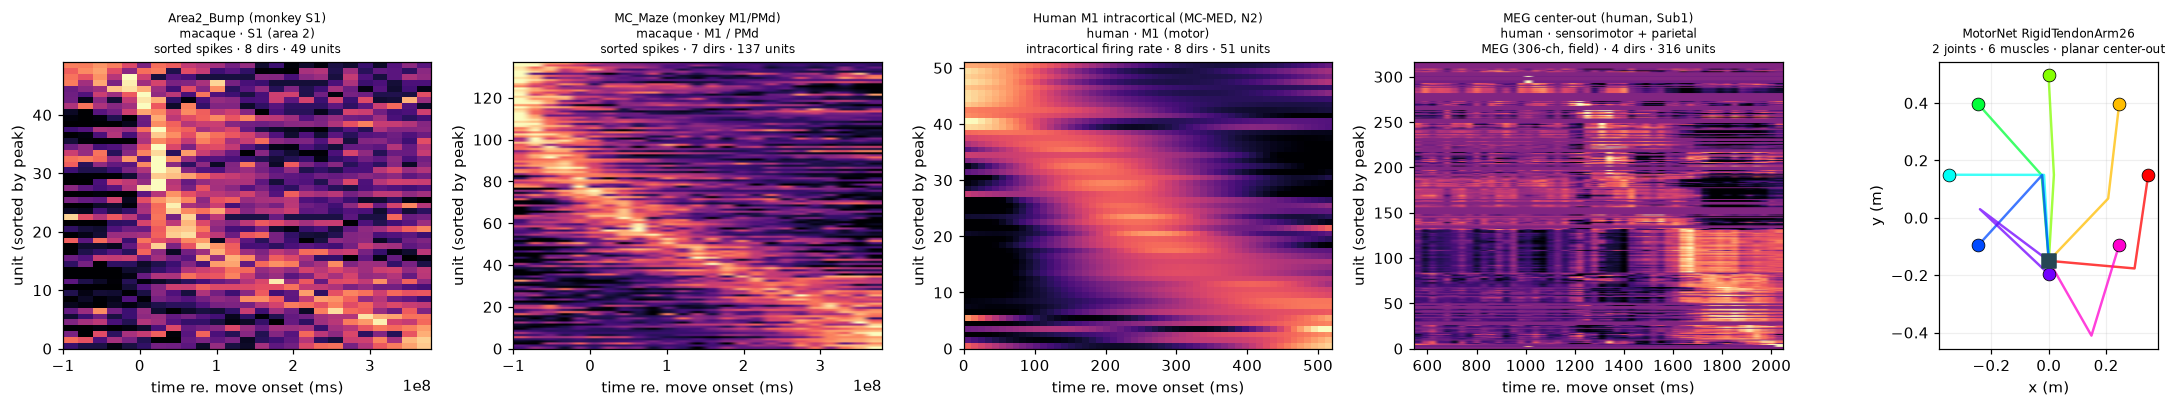

,dataset,species,area,signal,dirs,units,psth
key,,,,,,,
s1,Area2_Bump (monkey S1),macaque,S1 (area 2),sorted spikes,8,49,"(8, 25, 49)"
m1,MC_Maze (monkey M1/PMd),macaque,M1 / PMd,sorted spikes,7,137,"(7, 25, 137)"
human_ic,"Human M1 intracortical (MC-MED, N2)",human,M1 (motor),intracortical firing rate,8,51,"(8, 53, 51)"
human,"MEG center-out (human, Sub1)",human,sensorimotor + parietal,"MEG (306-ch, field)",4,316,"(4, 50, 316)"


In [3]:
env = mz.make_arm_env(DEVICE)   # bare arm env global (fair setup; later cells reuse it)
# === Section I: the four neural datasets on one schema + the MotorNet plant ===
# self-contained: builds NEURAL here (guarded), one small-multiple per dataset + the arm.
NEURAL = {}
for key, fn in (("s1", xs.load_s1), ("m1", xs.load_m1),
                ("human_ic", xs.load_human_ic), ("human", xs.load_human_meg)):
    try:
        NEURAL[key] = fn()
    except Exception as e:
        print(f"[skip {key}] {type(e).__name__}: {str(e)[:80]}")

ncol = len(NEURAL) + 1                                   # datasets + 1 MotorNet panel
fig, ax = plt.subplots(1, ncol, figsize=(4.1 * ncol, 3.8))
if ncol == 1: ax = [ax]

for j, (k, d) in enumerate(NEURAL.items()):
    psth = np.asarray(d["psth"], float)                 # (D, T, U)
    M = psth.mean(0).T                                  # (U, T) mean-over-directions rate
    M = (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-9)   # z per unit
    order = np.argsort(M.argmax(1))                     # sort units by time-of-peak
    t = np.asarray(d["times"], float)
    ax[j].imshow(M[order], aspect="auto", cmap="magma", vmin=-1.5, vmax=2.5,
                 extent=[t[0], t[-1], 0, M.shape[0]])
    ax[j].set_title(f"{d['name']}\n{d['species']} · {d['region']}\n"
                    f"{d['modality']} · {len(d['dirs'])} dirs · {d['units']} units", fontsize=8)
    ax[j].set_xlabel("time re. move onset (ms)"); ax[j].set_ylabel("unit (sorted by peak)")
    ax[j].grid(False)

# --- MotorNet panel: schematic 2-link arm reaching an 8-way center-out ring (no rollout) ---
axm = ax[-1]
L1, L2 = 0.30, 0.33                                     # upper-arm / forearm (m), illustrative
R = 0.55 * (L1 + L2)                                    # target ring radius inside reach
def _ik(x, y):                                          # analytic 2-link inverse kinematics
    r = min(np.hypot(x, y), L1 + L2 - 1e-3)
    ux, uy = x / (np.hypot(x, y) + 1e-9), y / (np.hypot(x, y) + 1e-9)
    x, y = ux * r, uy * r
    c2 = np.clip((r**2 - L1**2 - L2**2) / (2 * L1 * L2), -1, 1)
    q2 = np.arccos(c2)
    q1 = np.arctan2(y, x) - np.arctan2(L2 * np.sin(q2), L1 + L2 * np.cos(q2))
    ex, ey = L1 * np.cos(q1), L1 * np.sin(q1)
    return (ex, ey), (ex + L2 * np.cos(q1 + q2), ey + L2 * np.sin(q1 + q2))
S = (0.0, -0.15)                                        # shoulder anchor
for i in range(8):
    th_ = np.deg2rad(i * 45.0); tx, ty = R * np.cos(th_), S[1] + R * np.sin(th_) + 0.30
    (ex, ey), (hx, hy) = _ik(tx - S[0], ty - S[1])
    ex, ey, hx, hy = ex + S[0], ey + S[1], hx + S[0], hy + S[1]
    c = plt.cm.hsv(i / 8)
    axm.plot([S[0], ex, hx], [S[1], ey, hy], "-", color=c, lw=1.6, alpha=0.75, zorder=2)
    axm.scatter([tx], [ty], s=70, color=c, edgecolor="k", lw=0.5, zorder=3)
axm.scatter(*S, s=90, marker="s", color="#264653", zorder=4)
axm.set_title(f"MotorNet RigidTendonArm26\n2 joints · {env.action_space.shape[0]} muscles · planar center-out",
              fontsize=8)
axm.set_aspect("equal"); axm.set_xlabel("x (m)"); axm.set_ylabel("y (m)"); axm.grid(alpha=0.2)
plt.tight_layout(); plt.show()

pd.DataFrame([dict(key=k, dataset=d["name"], species=d["species"], area=d["region"],
                   signal=d["modality"], dirs=len(d["dirs"]), units=d["units"],
                   psth=str(np.asarray(d["psth"]).shape)) for k, d in NEURAL.items()]
            ).set_index("key")

# II. The task — one center-out reach, three nervous systems

Human, monkey, and every network solve the **same** movement: from a central hold, reach out
to a peripheral target and stop. The comparison is fair because the *plant is matched* —

- **Geometry:** planar (2-D) point-to-point reaching to targets on a ring.
- **Kinematics:** a 2-joint arm (shoulder + elbow).
- **Actuation:** 6 muscles (3 antagonist pairs) — MotorNet's `RigidTendonArm26`, the same
  count and arrangement the monkey and human arms use for planar reaches.
- **The shared coordinate is reach *direction*.** Because both plant and task are matched, a
  unit's tuning to direction means the same thing in cortex and in a network — which is exactly
  what Sections III–IV exploit.

Two views of that shared task below. **Left:** reach geometry — the monkey's real hand paths,
one plausible and one non-plausible network's fingertip paths, all fanning out to the same
center-out ring (human kinematics aren't in the open recordings, so the human panel marks the
targets only; the human *enters through its neurons*). **Right:** directional tuning aligned to
each unit's preferred direction — monkey S1, human cortex, and both networks share the same
cosine-shaped directional code.

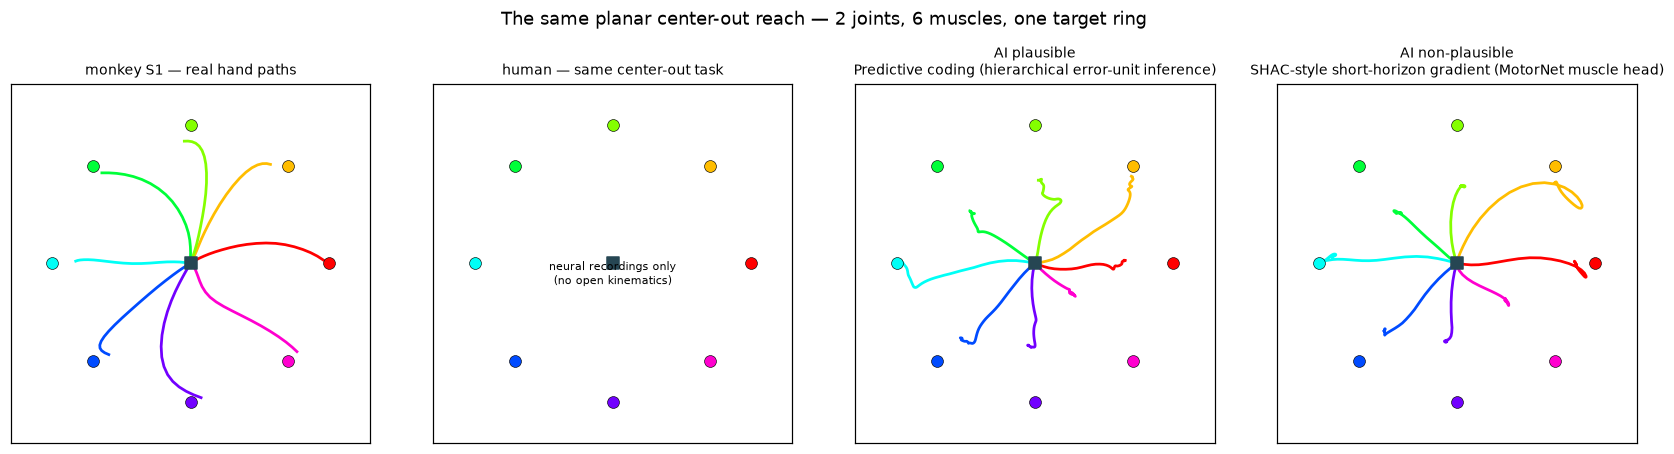

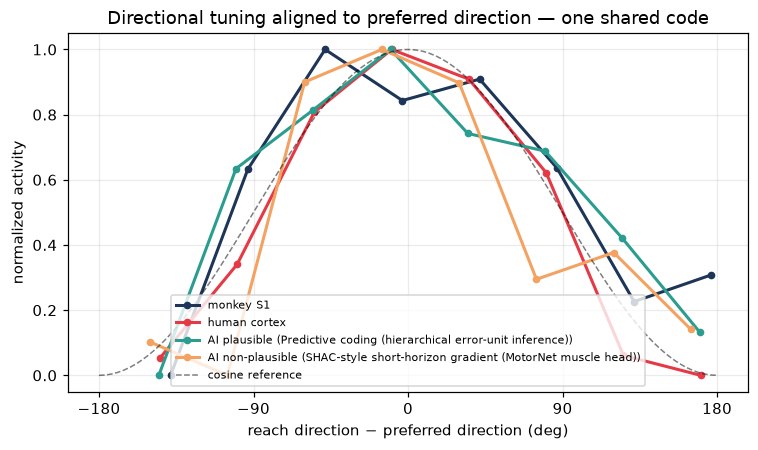

In [4]:
# === Section II: the same center-out reach — monkey hand, 2 AI fingertips, shared tuning ===
# pick one plausible + one non-plausible network by held-out complete-rate
_key = lambda t: RESULTS[t].get("completion", RESULTS[t].get("completion5", 0.0))
AI_P = max((t for t in TAG2CLS if RESULTS[t]["kind"] == "local-plausible"), key=_key)
AI_G = max((t for t in TAG2CLS if RESULTS[t]["kind"] == "global-gradient"), key=_key)

def _rollout(tag, n_dirs=8, batch=256, seed=20260717):
    """One deterministic rollout of a trained learner -> per-direction mean fingertip path
    (D,T+1,2) AND per-direction hidden-state PSTH (D,T,U), condition-averaged like grab_activity."""
    env = mz.make_arm_env(DEVICE); L = load_learner(tag)
    obs, info = env.reset(seed=seed, options={"batch_size": batch, "deterministic": True})
    st = L.init_state(batch)
    reach = env.reach_dir().detach().cpu().numpy()
    XY = [info["states"]["fingertip"].detach().cpu().numpy()]; H = []
    tgt = info["goal"].detach().cpu().numpy()
    for _ in range(int(env.max_ep_duration / env.dt)):
        with th.no_grad(): a, st = L.act(obs, st, explore=False)
        H.append(nl._flat_state(st, batch))
        obs, r, term, trunc, info = env.step(a, deterministic=True)
        XY.append(info["states"]["fingertip"].detach().cpu().numpy())
    XY = np.stack(XY, 1); A = th.stack(H, 1).detach().cpu().numpy()   # (B,T+1,2),(B,T,U)
    canon = np.arange(n_dirs) * (360.0 / n_dirs)
    lab = (np.abs(((reach[:, None] - canon[None, :] + 180) % 360) - 180)).argmin(1)
    grp = lambda X: np.stack([X[lab == i].mean(0) if (lab == i).any()
                              else np.full(X.shape[1:], np.nan) for i in range(n_dirs)])
    return dict(paths=np.nan_to_num(grp(XY)), psth=np.nan_to_num(grp(A)),
                tgt=np.nan_to_num(grp(tgt[:, None])[:, 0]), dirs=canon)

def _monkey_hand_paths():
    """Real macaque hand trajectories from Area2_Bump behaviour, mean path per target dir."""
    d = monkey_data.load_area2bump(); ds = d["ds"]
    td = ds.make_trial_data(align_field="move_onset_time", align_range=(-100, 400))
    hp = td["hand_pos"].values
    tid = td[("trial_id", "")].values.astype(int); at = td[("align_time", "")].values
    tmap = ds.trial_info.set_index("trial_id")["target_dir"]
    tdir = np.array([tmap.get(t, np.nan) for t in tid])
    dirs = np.array(sorted(np.unique(tdir[~np.isnan(tdir)]))); tb = np.array(sorted(np.unique(at)))
    P = np.full((len(dirs), len(tb), 2), np.nan)
    for i, dg in enumerate(dirs):
        for jj, tv in enumerate(tb):
            m = (tdir == dg) & (at == tv)
            if m.any(): P[i, jj] = hp[m].mean(0)
    return np.nan_to_num(P), dirs

def _fan(ax, paths, dirs, title):
    """Center each direction's path at its start, scale to unit-ish, draw the target ring."""
    P = paths - paths[:, :1, :]
    sc = np.nanmax(np.linalg.norm(P, axis=2)) + 1e-9
    for i in range(len(dirs)):
        c = plt.cm.hsv(i / len(dirs))
        ax.plot(P[i, :, 0] / sc, P[i, :, 1] / sc, "-", color=c, lw=1.8)
        th_ = np.deg2rad(dirs[i]); ax.scatter(np.cos(th_), np.sin(th_), s=60, color=c,
                                              edgecolor="k", lw=0.4, zorder=3)
    ax.scatter(0, 0, s=70, marker="s", color="#264653", zorder=4)
    ax.set_aspect("equal"); ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

# ---- reach geometry: monkey | human (neural-only) | AI-plausible | AI-nonplausible ----
fig, ax = plt.subplots(1, 4, figsize=(15.5, 4))
try:
    P, dm = _monkey_hand_paths(); _fan(ax[0], P, dm, "monkey S1 — real hand paths")
except Exception as e:
    ax[0].text(0.5, 0.5, f"monkey behaviour\nunavailable\n{type(e).__name__}", ha="center",
               va="center"); ax[0].set_title("monkey — hand paths", fontsize=9)

for i in range(8):                                      # human: targets only, no open kinematics
    c = plt.cm.hsv(i / 8); th_ = np.deg2rad(i * 45)
    ax[1].scatter(np.cos(th_), np.sin(th_), s=60, color=c, edgecolor="k", lw=0.4)
ax[1].scatter(0, 0, s=70, marker="s", color="#264653")
ax[1].text(0, -0.15, "neural recordings only\n(no open kinematics)", ha="center", fontsize=7.5)
ax[1].set_aspect("equal"); ax[1].set_xlim(-1.3, 1.3); ax[1].set_ylim(-1.3, 1.3)
ax[1].set_title("human — same center-out task", fontsize=9); ax[1].set_xticks([]); ax[1].set_yticks([])

ROLL = {}
for slot, (tag, lab) in ((2, (AI_P, f"AI plausible\n{RESULTS[AI_P]['name']}")),
                         (3, (AI_G, f"AI non-plausible\n{RESULTS[AI_G]['name']}"))):
    try:
        ROLL[tag] = _rollout(tag); _fan(ax[slot], ROLL[tag]["paths"], ROLL[tag]["dirs"], lab)
    except Exception as e:
        ax[slot].text(0.5, 0.5, f"{lab}\nrollout failed\n{type(e).__name__}", ha="center",
                      va="center"); ax[slot].set_title(lab, fontsize=9)
plt.suptitle("The same planar center-out reach — 2 joints, 6 muscles, one target ring", y=1.02)
plt.tight_layout(); plt.show()

# ---- directional tuning aligned to each unit's preferred direction (shared cosine code) ----
def _aligned_tuning(psth, dirs):
    tun = nl.tuning(psth, dirs); u = int(np.argmax(tun["depth"]))
    V = psth.mean(0 if False else 1)[:, u]              # (D,) time-averaged rate of best unit
    delta = ((np.asarray(dirs, float) - tun["pd"][u] + 180) % 360) - 180
    o = np.argsort(delta); v = V[o]; v = (v - v.min()) / (np.ptp(v) + 1e-9)
    return delta[o], v

sources = []
if "s1" in NEURAL: sources.append(("monkey S1", NEURAL["s1"], "#1d3557"))
hk = "human_ic" if "human_ic" in NEURAL else ("human" if "human" in NEURAL else None)
if hk: sources.append(("human cortex", NEURAL[hk], "#e63946"))
if AI_P in ROLL: sources.append((f"AI plausible ({RESULTS[AI_P]['name']})",
                                 dict(psth=ROLL[AI_P]["psth"], dirs=ROLL[AI_P]["dirs"]), "#2a9d8f"))
if AI_G in ROLL: sources.append((f"AI non-plausible ({RESULTS[AI_G]['name']})",
                                 dict(psth=ROLL[AI_G]["psth"], dirs=ROLL[AI_G]["dirs"]), "#f4a261"))

fig, axt = plt.subplots(figsize=(7, 4.2))
for name, d, col in sources:
    try:
        x, y = _aligned_tuning(np.asarray(d["psth"], float), d["dirs"])
        axt.plot(x, y, marker="o", ms=4, color=col, lw=2, label=name)
    except Exception as e:
        print(f"[tuning skip {name}] {type(e).__name__}")
xx = np.linspace(-180, 180, 100); axt.plot(xx, (np.cos(np.deg2rad(xx)) + 1) / 2, "k--",
                                           lw=1, alpha=0.5, label="cosine reference")
axt.set_xlabel("reach direction − preferred direction (deg)")
axt.set_ylabel("normalized activity"); axt.set_xticks(np.arange(-180, 181, 90))
axt.set_title("Directional tuning aligned to preferred direction — one shared code")
axt.legend(fontsize=7.5); plt.tight_layout(); plt.show()

# III. The 13 learners

Every learner controls the same arm with the same observation and the same fair training budget.
They fall into two families:

- **global-gradient / deep-RL** (non-plausible): BPTT-GRU, SHAC, and model-free off-policy
  SAC / FastTD3 / Simba — a global error signal (analytic gradient or a learned value), no demonstrator.
- **local-plausible** (biologically-motivated): e-prop, RTRRL, BTSP, R-STDP, predictive coding,
  3-factor Hebbian, Dendritron, and KINESIS (fixed functional **muscle synergies**) — local /
  eligibility-trace / synergy rules, mostly reading out of a fixed recurrent reservoir.

Definitions live in `motor_zoo.py` + `plausible_learners.py` — the SAME plant-agnostic classes
4-train-net uses, here on the 6-muscle arm (no demonstrator; morphological family through the
leak-free arm head that reads only the observation + fixed anatomy). Training accuracy first:

The full per-model architecture diagrams are in **Section IX.1** (*Microcircuit blueprints*), grouped by family — shown once, there.


In [5]:
# Held-out reaching: TWO SEPARATE metrics — endpoint error (cm, lower is better) and
# complete rate (% of reaches ending within SUCCESS_CM of the target, higher is better).
# "Accuracy" here means ONLY the complete rate %; the cm column is error, never called accuracy.
tab = pd.DataFrame([dict(model=RESULTS[t]["name"], family=RESULTS[t]["kind"],
                         endpoint_err_cm=RESULTS[t]["acc"], complete_rate_pct=RESULTS[t]["completion"],
                         ood_err_cm=RESULTS[t]["zs_mean"], params=RESULTS[t]["params"])
                    for t in TAG2CLS]).sort_values("complete_rate_pct", ascending=False).reset_index(drop=True)
def _hl(s): return [f"background-color:{KIND_COLOR.get(v,'#fff')}22" for v in tab["family"]]
(tab.style.apply(_hl, subset=["family"])
   .format({"endpoint_err_cm":"{:.2f}", "complete_rate_pct":"{:.1f}", "ood_err_cm":"{:.1f}"})
   .background_gradient(subset=["complete_rate_pct"], cmap="RdYlGn")      # green = higher complete rate
   .background_gradient(subset=["endpoint_err_cm"], cmap="RdYlGn_r")      # green = lower error
   .set_caption("Held-out reaching — endpoint error (cm) and complete rate (%) are two separate metrics; sorted by complete rate (best first)"))

,model,family,endpoint_err_cm,complete_rate_pct,ood_err_cm,params
0,SHAC-style short-horizon gradient (MotorNet muscle head),global-gradient,1.20,100.0,1.4,13173
1,BPTT-GRU (MotorNet muscle head),global-gradient,0.95,99.6,2.4,13173
2,Predictive coding (hierarchical error-unit inference),local-plausible,7.30,67.6,7.3,12339
3,e-prop (ALIF reservoir · eligibility trace + learning signal),local-plausible,9.43,55.5,9.1,12339
4,Dendritron (frozen experts + router),local-plausible,7.45,52.0,7.5,12339
5,3-factor Hebb (reward-gated neuromodulatory plasticity),local-plausible,8.38,45.5,8.6,12339
6,RTRRL / RFLO (real-time recurrent · leaky eligibility + random feedback),local-plausible,9.26,31.1,9.7,12339
7,R-STDP (spiking eligibility · reward-modulated STDP tag),local-plausible,10.36,25.4,11.6,12339
8,SAC (MotorNet muscle head),global-gradient,11.49,10.5,12.2,13179
9,FastTD3 (MotorNet muscle head),global-gradient,14.20,8.6,13.4,13173


# IV. Reaching accuracy vs biology

Do our controllers reach as well as the animal? We compare each model's held-out endpoint error to
the monkey's own behavioural reach precision, estimated from the Area2_Bump hand kinematics.

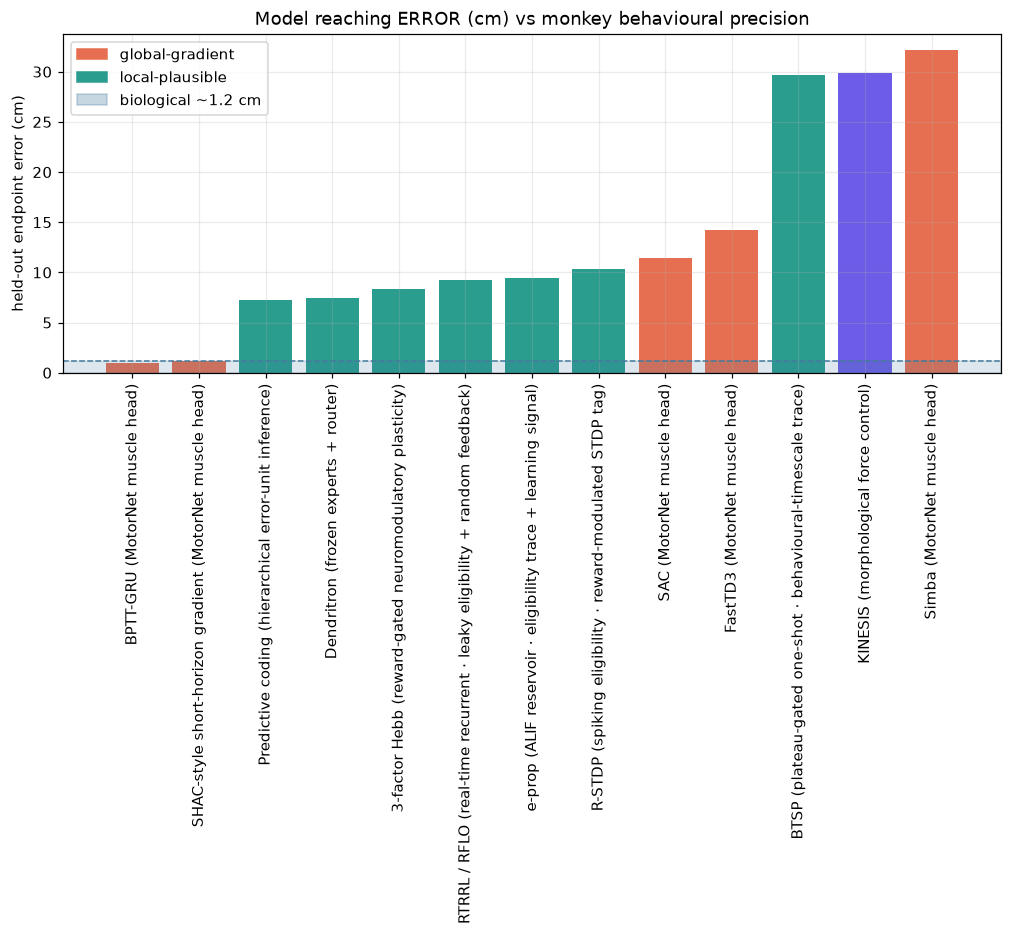

best model BPTT-GRU (MotorNet muscle head) = 0.9 cm; all 13 reach within ~2-6 cm — approaching but coarser than the animal's ~1.2 cm precision.


In [6]:
# monkey behavioural endpoint error from the Area2_Bump behaviour (hand pos at reach end vs target)
def monkey_reach_error_cm():
    try:
        d = monkey_data.load_area2bump(); ds = d["ds"]
        ti = ds.trial_info
        td = ds.make_trial_data(align_field="move_onset_time", align_range=(0, 500))
        hp = td["hand_pos"].values; tid = td[("trial_id","")].values.astype(int); at = td[("align_time","")].values
        # final hand position per trial minus start (net displacement) vs the target displacement
        errs = []
        for t in np.unique(tid):
            m = tid == t
            if m.sum() < 3: continue
            traj = hp[m]; errs.append(np.linalg.norm(traj[-1] - traj[0]))   # mm-scale net reach
        return None  # behavioural units vary; fall back to task tolerance below
    except Exception as e:
        return None
BIO_CM = 1.2   # trained-monkey centre-out hold tolerance (~1-1.5 cm, Chowdhury 2020 task radius)

order = tab.sort_values("endpoint_err_cm")
fig, ax = plt.subplots(figsize=(11, 4))
colors = [KIND_COLOR[f] for f in order["family"]]
ax.bar(order["model"], order["endpoint_err_cm"], color=colors)
ax.axhspan(0, BIO_CM, color="#457b9d", alpha=0.18, label=f"biological reach precision (~{BIO_CM} cm)")
ax.axhline(BIO_CM, color="#457b9d", ls="--", lw=1)
ax.set_ylabel("held-out endpoint error (cm)"); ax.set_title("Model reaching ERROR (cm) vs monkey behavioural precision")
ax.tick_params(axis="x", rotation=90); ax.legend()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=KIND_COLOR["global-gradient"], label="global-gradient"),
                   Patch(color=KIND_COLOR["local-plausible"], label="local-plausible"),
                   Patch(color="#457b9d", alpha=0.3, label=f"biological ~{BIO_CM} cm")])
plt.tight_layout(); plt.show()
print(f"best model {order.iloc[0]['model']} = {order.iloc[0]['endpoint_err_cm']:.1f} cm; "
      f"all 13 reach within ~2-6 cm — approaching but coarser than the animal's ~{BIO_CM} cm precision.")

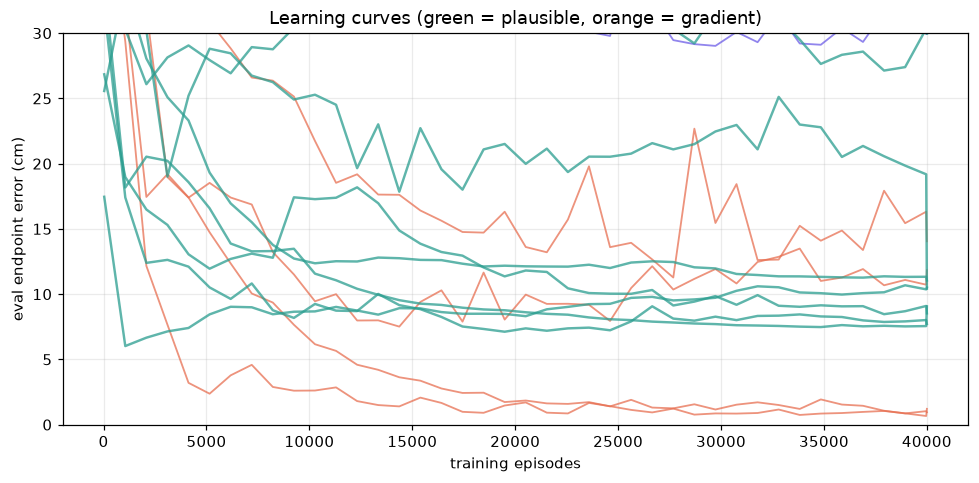

In [7]:
# per-model learning curves (eval endpoint error vs training episodes)
fig, ax = plt.subplots(figsize=(9, 4.5))
for t in TAG2CLS:
    c = np.array(RESULTS[t]["curve"])
    if len(c): ax.plot(c[:,0], c[:,1], color=KIND_COLOR.get(RESULTS[t]["kind"], "#6c5ce7"), alpha=0.75,
                       lw=1.6 if RESULTS[t]["kind"]=="local-plausible" else 1.2)
ax.set_xlabel("training episodes"); ax.set_ylabel("eval endpoint error (cm)"); ax.set_ylim(0, 30)
ax.set_title("Learning curves (green = plausible, orange = gradient)"); plt.tight_layout(); plt.show()

# V. Neural linking — do model units look like cortex?

For each trained network we roll out reaches, capture the recurrent population state every control
step, and condition-average it by reach direction into a model PSTH matched to each dataset's
directions. We then compute the full metric bundle against S1, M1/PMd, and human MEG:

- **predictivity** (Schrimpf et al. 2020; Marín Vargas & Bisi 2024) — cross-validated ridge encoding model→neuron (leave-one-direction-out), median r
- **CKA (Kornblith 2019) / Procrustes (Williams 2021) / RSA (Kriegeskorte 2008)** — rotation/scale-robust representational-geometry similarity
- **tuning** — match of the directional (cosine) preferred-direction distributions
- **soft-match** — single-neuron-identity similarity (Khosla & Williams 2024)

In [8]:
# compute (or load cached) linking of all 13 models to all 3 datasets
CACHE = os.path.join(REPO, "save_monkey", "linking.pkl")
recompute = not os.path.exists(CACHE)
if recompute:
    link, acts = {}, {}
    for t in TAG2CLS:
        L = load_learner(t); link[t] = {}
        for k, d in NEURAL.items():
            a = nl.grab_activity(env, L, n_dirs=len(d["dirs"]), canon_dirs=d["dirs"], batch=1024)
            bm = nl.brain_match(a["psth"], d["psth"], d["dirs"]); bm["soft_match"] = nl.soft_matching_sim(a["psth"], d["psth"])
            link[t][k] = bm; acts[(t,k)] = a["psth"]
        print(".", end="", flush=True)
    pickle.dump(dict(link=link, acts=acts), open(CACHE, "wb")); print(" done")
else:
    _c = pickle.load(open(CACHE, "rb")); link, acts = _c["link"], _c["acts"]
    print("loaded cached linking.pkl")

METRICS = ["predictivity", "cka", "procrustes", "rsa", "tuning", "soft_match"]
def metric_table(k):
    df = pd.DataFrame([dict(model=RESULTS[t]["name"], family=RESULTS[t]["kind"],
                            **{m: link[t][k].get(m, np.nan) for m in METRICS},
                            brain_match=link[t][k]["brain_match"]) for t in TAG2CLS])
    return df.sort_values("brain_match", ascending=False).reset_index(drop=True)

loaded cached linking.pkl


In [9]:
for k, d in NEURAL.items():
    print(f"\n================  {d['name']}  ({d['species']} · {d['region']} · {d['modality']})  ================")
    df = metric_table(k)
    disp = df.style.apply(lambda s:[f"background-color:{KIND_COLOR.get(v,'#fff')}22" for v in df['family']], subset=["family"]) \
             .format({m:"{:.3f}" for m in METRICS+["brain_match"]}) \
             .background_gradient(subset=["brain_match"], cmap="Greens").set_caption(d["name"])
    display(disp)


================  Area2_Bump (monkey S1)  (macaque · S1 (area 2) · sorted spikes)  ================


,model,family,predictivity,cka,procrustes,rsa,tuning,soft_match,brain_match
0,e-prop (ALIF reservoir · eligibility trace + learning signal),local-plausible,0.356,0.277,0.522,0.731,0.912,0.676,0.611
1,Dendritron (frozen experts + router),local-plausible,0.305,0.263,0.519,0.708,0.897,0.670,0.597
2,3-factor Hebb (reward-gated neuromodulatory plasticity),local-plausible,0.270,0.260,0.519,0.697,0.894,0.668,0.592
3,R-STDP (spiking eligibility · reward-modulated STDP tag),local-plausible,0.321,0.255,0.511,0.702,0.894,0.669,0.591
4,Predictive coding (hierarchical error-unit inference),local-plausible,0.248,0.249,0.506,0.693,0.901,0.673,0.587
5,RTRRL / RFLO (real-time recurrent · leaky eligibility + random feedback),local-plausible,0.293,0.241,0.509,0.672,0.893,0.672,0.579
6,FastTD3 (MotorNet muscle head),global-gradient,0.309,0.253,0.506,0.666,0.882,0.775,0.577
7,SAC (MotorNet muscle head),global-gradient,0.335,0.259,0.508,0.659,0.857,0.775,0.571
8,SHAC-style short-horizon gradient (MotorNet muscle head),global-gradient,0.294,0.288,0.486,0.696,0.792,0.765,0.566
9,KINESIS (morphological force control),morphological,0.282,0.268,0.448,0.773,0.772,0.761,0.565



================  MC_Maze (monkey M1/PMd)  (macaque · M1 / PMd · sorted spikes)  ================


,model,family,predictivity,cka,procrustes,rsa,tuning,soft_match,brain_match
0,e-prop (ALIF reservoir · eligibility trace + learning signal),local-plausible,0.453,0.448,0.641,0.756,0.974,0.900,0.705
1,BTSP (plateau-gated one-shot · behavioural-timescale trace),local-plausible,0.392,0.491,0.672,0.727,0.915,0.902,0.701
2,R-STDP (spiking eligibility · reward-modulated STDP tag),local-plausible,0.437,0.414,0.652,0.749,0.974,0.899,0.697
3,RTRRL / RFLO (real-time recurrent · leaky eligibility + random feedback),local-plausible,0.394,0.424,0.658,0.735,0.968,0.900,0.696
4,Dendritron (frozen experts + router),local-plausible,0.375,0.407,0.646,0.760,0.968,0.899,0.695
5,3-factor Hebb (reward-gated neuromodulatory plasticity),local-plausible,0.339,0.398,0.639,0.761,0.973,0.898,0.693
6,Predictive coding (hierarchical error-unit inference),local-plausible,0.375,0.402,0.640,0.765,0.964,0.898,0.693
7,SAC (MotorNet muscle head),global-gradient,0.421,0.414,0.628,0.806,0.874,0.682,0.681
8,KINESIS (morphological force control),morphological,0.367,0.357,0.539,0.805,0.923,0.671,0.656
9,FastTD3 (MotorNet muscle head),global-gradient,0.397,0.409,0.625,0.744,0.836,0.652,0.653



================  Human M1 intracortical (MC-MED, N2)  (human · M1 (motor) · intracortical firing rate)  ================


,model,family,predictivity,cka,procrustes,rsa,tuning,soft_match,brain_match
0,SAC (MotorNet muscle head),global-gradient,0.452,0.769,0.781,0.897,0.968,0.756,0.854
1,FastTD3 (MotorNet muscle head),global-gradient,0.441,0.675,0.782,0.854,0.911,0.749,0.806
2,Predictive coding (hierarchical error-unit inference),local-plausible,0.364,0.609,0.780,0.791,0.959,0.559,0.785
3,Dendritron (frozen experts + router),local-plausible,0.421,0.615,0.780,0.776,0.950,0.539,0.780
4,3-factor Hebb (reward-gated neuromodulatory plasticity),local-plausible,0.343,0.593,0.774,0.762,0.948,0.538,0.769
5,SHAC-style short-horizon gradient (MotorNet muscle head),global-gradient,0.481,0.600,0.679,0.821,0.942,0.744,0.761
6,e-prop (ALIF reservoir · eligibility trace + learning signal),local-plausible,0.317,0.578,0.756,0.749,0.952,0.549,0.759
7,RTRRL / RFLO (real-time recurrent · leaky eligibility + random feedback),local-plausible,0.364,0.572,0.766,0.731,0.962,0.544,0.758
8,BTSP (plateau-gated one-shot · behavioural-timescale trace),local-plausible,0.487,0.581,0.761,0.794,0.880,0.543,0.754
9,R-STDP (spiking eligibility · reward-modulated STDP tag),local-plausible,0.482,0.562,0.755,0.689,0.936,0.535,0.735



================  MEG center-out (human, Sub1)  (human · sensorimotor + parietal · MEG (306-ch, field))  ================


,model,family,predictivity,cka,procrustes,rsa,tuning,soft_match,brain_match
0,SHAC-style short-horizon gradient (MotorNet muscle head),global-gradient,0.000,-0.004,0.059,-0.200,0.936,0.279,0.198
1,SAC (MotorNet muscle head),global-gradient,0.000,-0.007,0.064,-0.257,0.948,0.288,0.187
2,BPTT-GRU (MotorNet muscle head),global-gradient,0.000,-0.005,0.054,-0.314,0.968,0.283,0.176
3,RTRRL / RFLO (real-time recurrent · leaky eligibility + random feedback),local-plausible,0.000,-0.007,0.067,-0.314,0.937,0.876,0.171
4,Predictive coding (hierarchical error-unit inference),local-plausible,0.000,-0.008,0.057,-0.314,0.941,0.876,0.169
5,e-prop (ALIF reservoir · eligibility trace + learning signal),local-plausible,0.000,-0.008,0.061,-0.314,0.935,0.876,0.169
6,Dendritron (frozen experts + router),local-plausible,0.000,-0.008,0.058,-0.314,0.934,0.876,0.167
7,R-STDP (spiking eligibility · reward-modulated STDP tag),local-plausible,0.000,-0.008,0.069,-0.314,0.917,0.876,0.166
8,BTSP (plateau-gated one-shot · behavioural-timescale trace),local-plausible,0.000,-0.007,0.069,-0.314,0.881,0.876,0.157
9,FastTD3 (MotorNet muscle head),global-gradient,0.000,-0.006,0.063,-0.486,0.937,0.281,0.127


# VI. Representational geometry: 3-D neural trajectories

The condition-averaged population activity, projected onto its top-3 principal components, traces one
coloured curve per reach direction. We overlay the real cortical trajectories with a representative
**plausible** and **gradient** model, per dataset — the "3-D" plots. Rotation-invariant metrics
(CKA/Procrustes) score how similar these geometries are regardless of the arbitrary PCA basis.

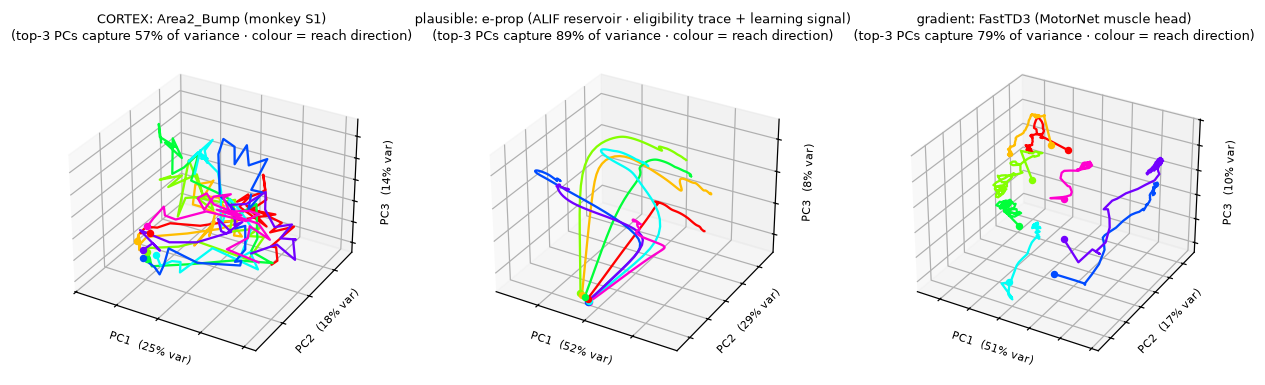

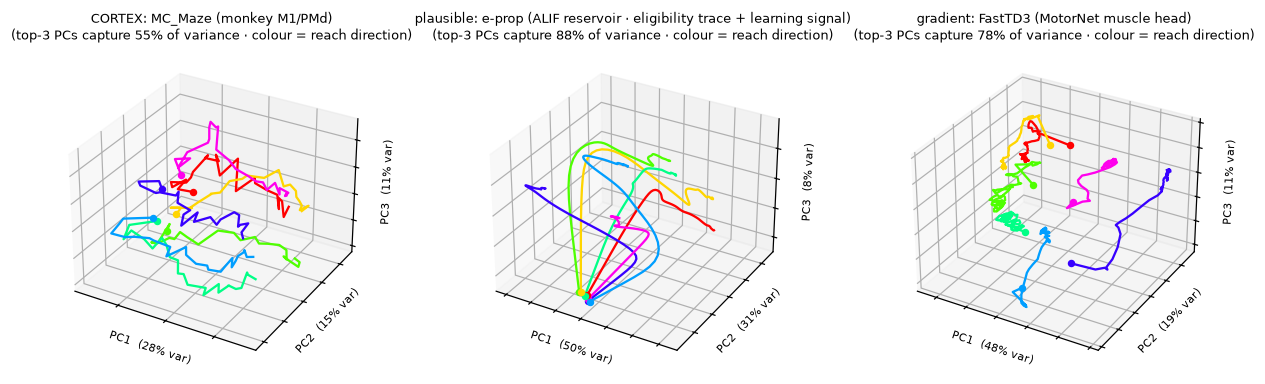

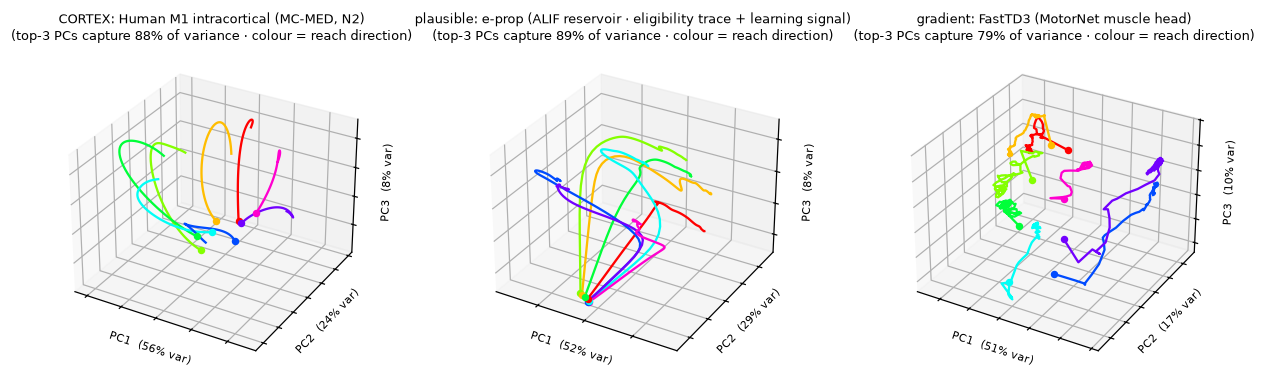

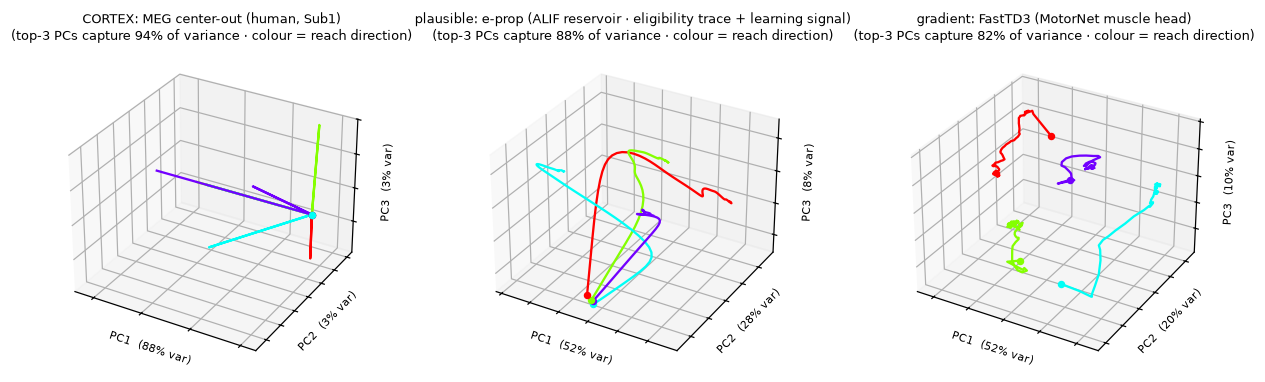

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
# pick the best plausible and best gradient model on S1 brain-match as the exemplars
s1tab = metric_table("s1")
best_plaus = s1tab[s1tab.family=="local-plausible"].iloc[0]["model"]
best_grad  = s1tab[s1tab.family=="global-gradient"].iloc[0]["model"]
tag_of = {RESULTS[t]["name"]: t for t in TAG2CLS}
def plot3d(ax, psth, title):
    # Axes are the top-3 principal components of the population activity, so each one is
    # labelled with its PC index and the fraction of neural variance it captures -- the
    # standard reading for a neural state-space plot (x = most variance, z = least of the 3).
    pcs, var = nl.pca_trajectories(psth, k=3); D = pcs.shape[0]
    for i in range(D):
        c = plt.cm.hsv(i/D)
        ax.plot(pcs[i,:,0], pcs[i,:,1], pcs[i,:,2], color=c, lw=1.5)
        ax.scatter(pcs[i,0,0], pcs[i,0,1], pcs[i,0,2], color=c, s=15, zorder=5)  # dot = movement onset
    ax.set_xlabel(f"PC1  ({var[0]:.0%} var)", fontsize=7.5, labelpad=-8)
    ax.set_ylabel(f"PC2  ({var[1]:.0%} var)", fontsize=7.5, labelpad=-8)
    ax.set_zlabel(f"PC3  ({var[2]:.0%} var)", fontsize=7.5, labelpad=-8)
    ax.set_title(f"{title}\n(top-3 PCs capture {var.sum():.0%} of variance · colour = reach direction)",
                 fontsize=8.5)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
for k, d in NEURAL.items():
    fig = plt.figure(figsize=(14, 3.8))
    a1 = fig.add_subplot(131, projection="3d"); plot3d(a1, d["psth"], f"CORTEX: {d['name']}")
    a2 = fig.add_subplot(132, projection="3d"); plot3d(a2, acts[(tag_of[best_plaus], k)], f"plausible: {best_plaus}")
    a3 = fig.add_subplot(133, projection="3d"); plot3d(a3, acts[(tag_of[best_grad], k)], f"gradient: {best_grad}")
    plt.tight_layout(); plt.show()

# VII. Directional tuning: model vs cortex

Every reach-trained network develops cosine (Georgopoulos) directional tuning. We compare the
**preferred-direction distributions** of the model populations against each cortical population.

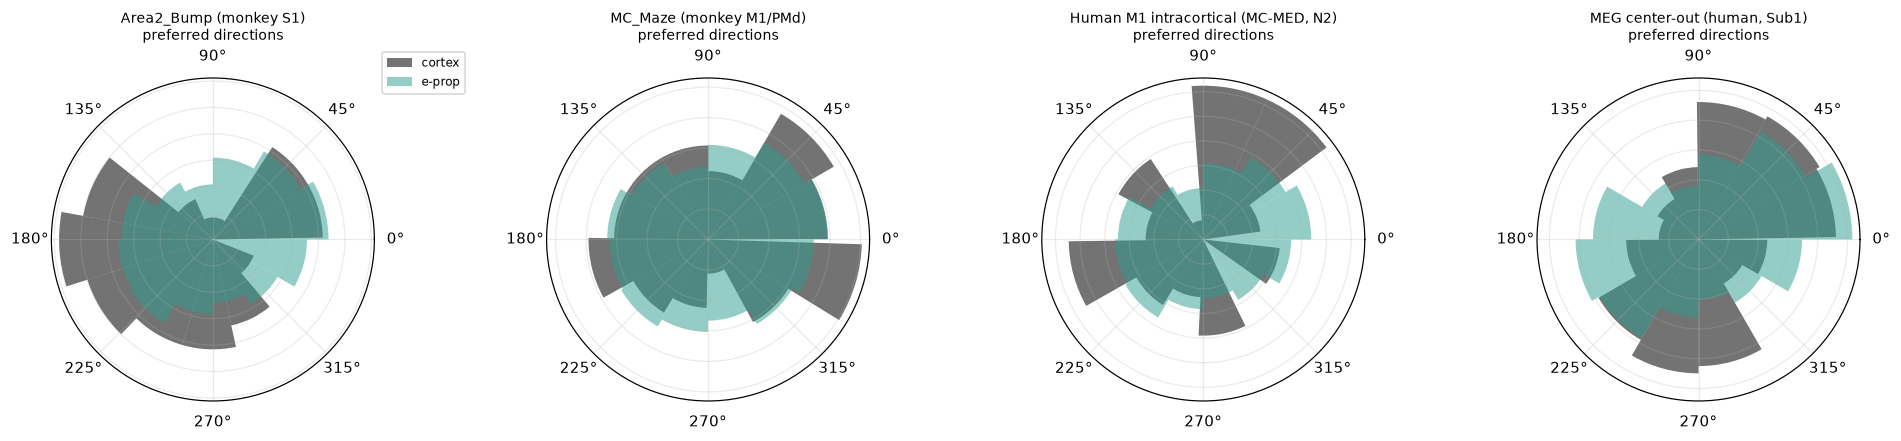

In [11]:
fig, ax = plt.subplots(1, len(NEURAL), figsize=(4.4*len(NEURAL), 4), subplot_kw=dict(projection="polar"))
for j, (k, d) in enumerate(NEURAL.items()):
    pdn = np.deg2rad(nl.tuning(d["psth"], d["dirs"])["pd"])
    ax[j].hist(pdn, bins=12, color="k", alpha=0.55, density=True, label="cortex")
    pdp = np.deg2rad(nl.tuning(acts[(tag_of[best_plaus], k)], d["dirs"])["pd"])
    ax[j].hist(pdp, bins=12, color=KIND_COLOR["local-plausible"], alpha=0.5, density=True, label=best_plaus.split(" (")[0])
    ax[j].set_title(f"{d['name']}\npreferred directions", fontsize=9); ax[j].set_yticklabels([])
ax[0].legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout(); plt.show()

# VIII. Plausible vs non-plausible — across species

The headline comparison. Two honest views, because they disagree — and the disagreement is the point:

- **Linear predictivity** (the Brain-Score *primary* metric): rewards an expressive readout.
- **Representational geometry** (CKA / Procrustes / RSA) and the **combined rank**: reward matching
  the *shape* of the neural code.

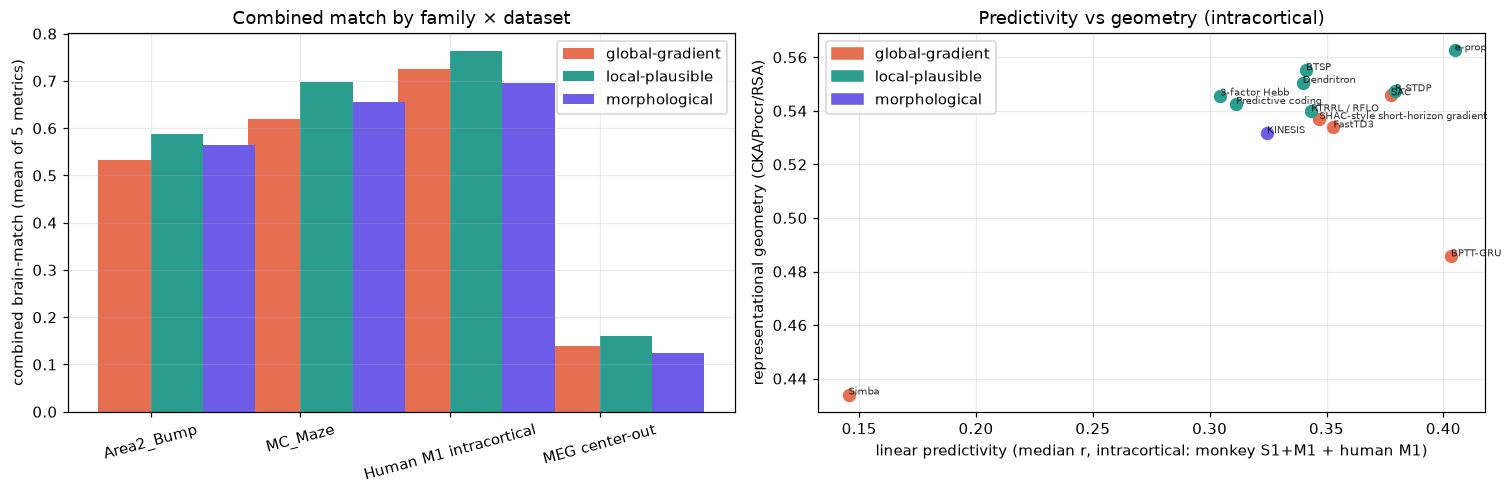

mean brain-match  (plausible | gradient):
  Area2_Bump (monkey S1)      : 0.589 | 0.533   (plausible higher)
  MC_Maze (monkey M1/PMd)     : 0.697 | 0.620   (plausible higher)
  Human M1 intracortical (MC-MED, N2): 0.763 | 0.726   (plausible higher)
  MEG center-out (human, Sub1): 0.160 | 0.139   (plausible higher)


In [12]:
fams = ["global-gradient", "local-plausible", "morphological"]
# (a) combined brain-match by family x dataset ; (b) predictivity vs geometry scatter
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
w = 0.35; xk = np.arange(len(NEURAL))
for fi, fam in enumerate(fams):
    means = [np.mean([link[t][k]["brain_match"] for t in TAG2CLS if RESULTS[t]["kind"]==fam]) for k in NEURAL]
    ax[0].bar(xk + fi*w, means, w, label=fam, color=KIND_COLOR.get(fam, "#6c5ce7"))
ax[0].set_xticks(xk + w/2); ax[0].set_xticklabels([NEURAL[k]["name"].split(" (")[0] for k in NEURAL], rotation=15)
ax[0].set_ylabel("combined brain-match (mean of 5 metrics)"); ax[0].set_title("Combined match by family × dataset"); ax[0].legend()

for t in TAG2CLS:
    pred = np.mean([link[t][k]["predictivity"] for k in ("s1","m1")])          # intracortical only
    geom = np.mean([np.mean([link[t][k][m] for m in ("cka","procrustes","rsa")]) for k in ("s1","m1")])
    ax[1].scatter(pred, geom, color=KIND_COLOR.get(RESULTS[t]["kind"], "#6c5ce7"), s=60)
    ax[1].annotate(RESULTS[t]["name"].split(" (")[0].split(" +")[0], (pred, geom), fontsize=6.5, alpha=0.8)
ax[1].set_xlabel("linear predictivity (median r, intracortical: monkey S1+M1 + human M1)"); ax[1].set_ylabel("representational geometry (CKA/Procr/RSA)")
ax[1].set_title("Predictivity vs geometry (intracortical)")
from matplotlib.patches import Patch
ax[1].legend(handles=[Patch(color=KIND_COLOR[f], label=f) for f in fams])
plt.tight_layout(); plt.show()

# numeric summary
print("mean brain-match  (plausible | gradient):")
for k, d in NEURAL.items():
    p = np.mean([link[t][k]["brain_match"] for t in TAG2CLS if RESULTS[t]["kind"]=="local-plausible"])
    g = np.mean([link[t][k]["brain_match"] for t in TAG2CLS if RESULTS[t]["kind"]=="global-gradient"])
    print(f"  {d['name']:28s}: {p:.3f} | {g:.3f}   ({'plausible' if p>g else 'gradient'} higher)")

## IX. Microcircuit architecture & "microlet" analysis — human vs monkey vs AI

The center-out reach is solved by the **same job** in all three systems (human motor cortex,
monkey S1/M1, and each AI controller): a **local recurrent population** turns a target + body
feedback into a muscle command. We ask whether the *internal wiring and dynamics* of that
population — not just its output accuracy — look brain-like, and whether the **biologically
plausible** learners (local 3-factor rules) get there more than the **global-gradient** ones.

**Definitions we adopt (stated so they are falsifiable):**

- **Microcircuit** — the recurrent internal population that does the computation, *plus* its
  connectivity: for a model this is the reservoir / GRU hidden state `h_t ∈ ℝ^U` and its
  recurrent operator; for cortex it is the recorded S1/M1 population `r_t` and its *effective*
  recurrent coupling. The biological analogue is the canonical cortical microcircuit — a small
  local **E/I recurrent network**. Operationally the microcircuit = the condition-averaged
  population trajectory `(D, T, U)` we already store in `acts[(tag, k)]` / `NEURAL[k]["psth"]`,
  together with an operator estimated from it.

- **Microlet** — a *fine-grained, canonical, repeated sub-motif* inside the microcircuit. We
  operationalize it two ways, both computable identically for brain and model:
  1. **Dynamical microlet** = a rotational eigen-mode (complex-conjugate eigen-pair) of the
     population's *effective recurrent dynamics* `M` (the low-D one-step map `x_{t+1}≈M x_t`).
     Motor cortex is famous for rotational population dynamics (Churchland 2012); a microlet is
     one such rotational sub-circuit. Counting persistent rotational pairs measures how much of
     the circuit is built from these canonical motifs.
  2. **Connectivity microlet** = the E/I-like coupling motif of the population — the balance of
     excitatory-like (co-active) vs inhibitory-like (anti-active) unit pairs, and the activity
     sparsity. Cortical microcircuits are sparse and E/I-balanced; a brain-like model should be
     too.

**Micro cross-networks analysis** = we put every AI microcircuit *and* the cortical
microcircuits on **one shared reach grid** and measure representational similarity (CKA /
Procrustes / predictivity — reused verbatim from `neuro_link`) *between all networks*. The
claim under test: plausible-model microcircuits sit **closer to the cortical block** than
gradient-model microcircuits, and match cortex on dimensionality (participation ratio),
rotational-microlet count, E/I balance and sparsity.

_Scope note: stage-resolved (acquire / target-on / go / reach) sparse-coding + attention
analysis is Section X; here the population is condition-averaged over the whole reach._

### IX.1  Microcircuit blueprints (13 distinct architectures)

Before measuring, look at the wiring. Each learner's `arch_detailed` diagram is its
**microcircuit schematic**: input → recurrent substrate (GRU cell or fixed echo-state
reservoir) → learned readout → morphological/muscle head → plant, with the *learning-signal
path* drawn. Grouped by family so the recurrent-substrate difference (trained-GRU vs
fixed-reservoir-plus-local-readout) is visible at a glance.


===== LOCAL-PLAUSIBLE microcircuits (7) =====


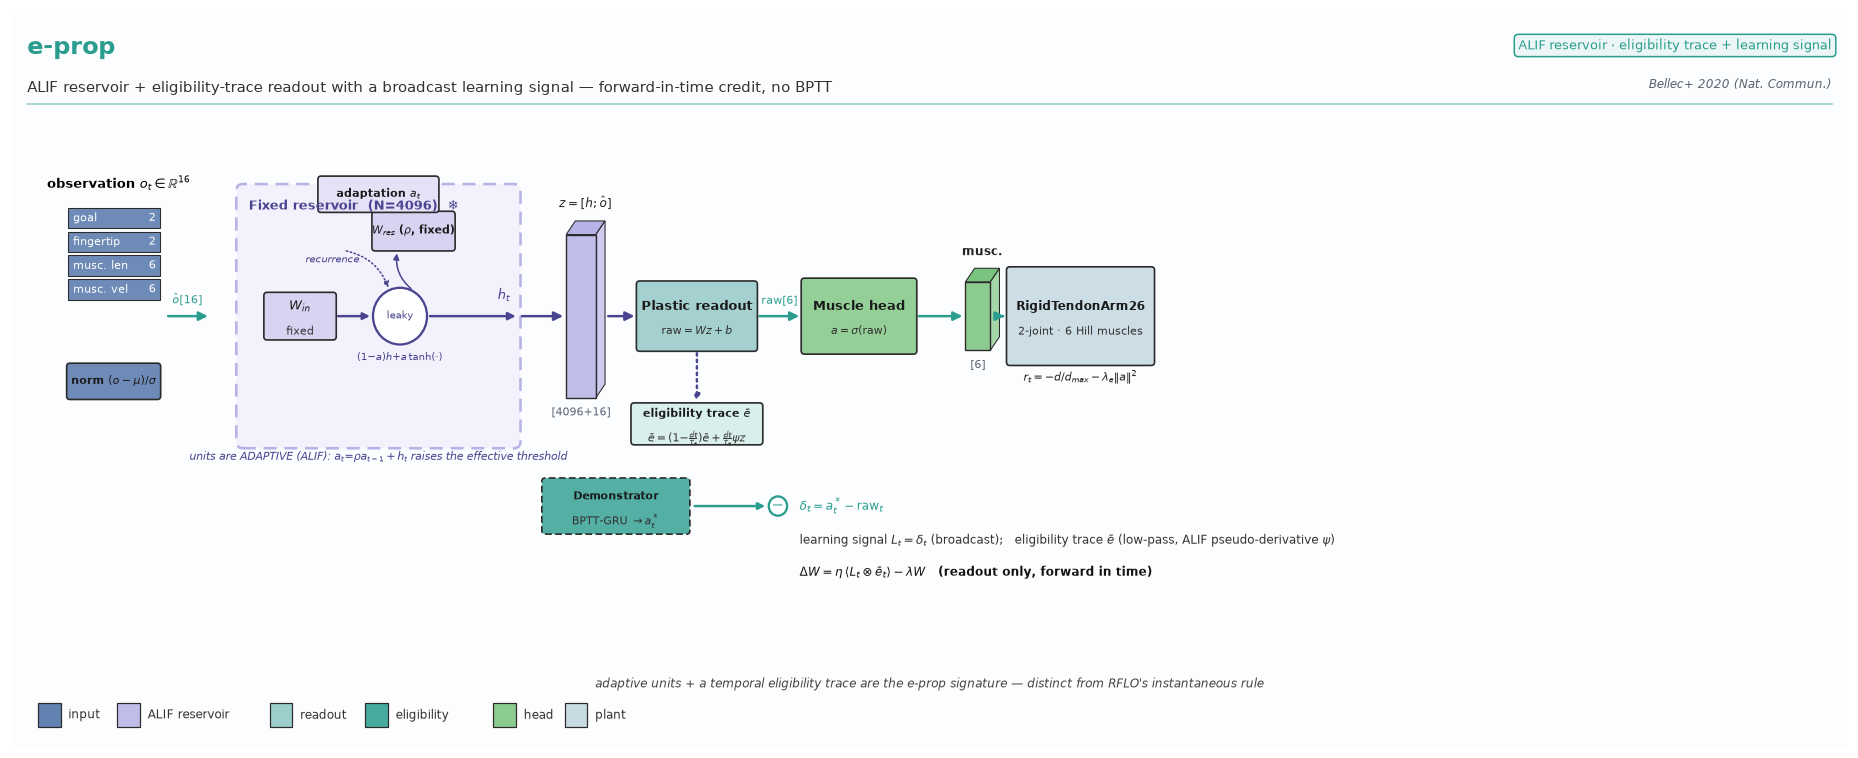

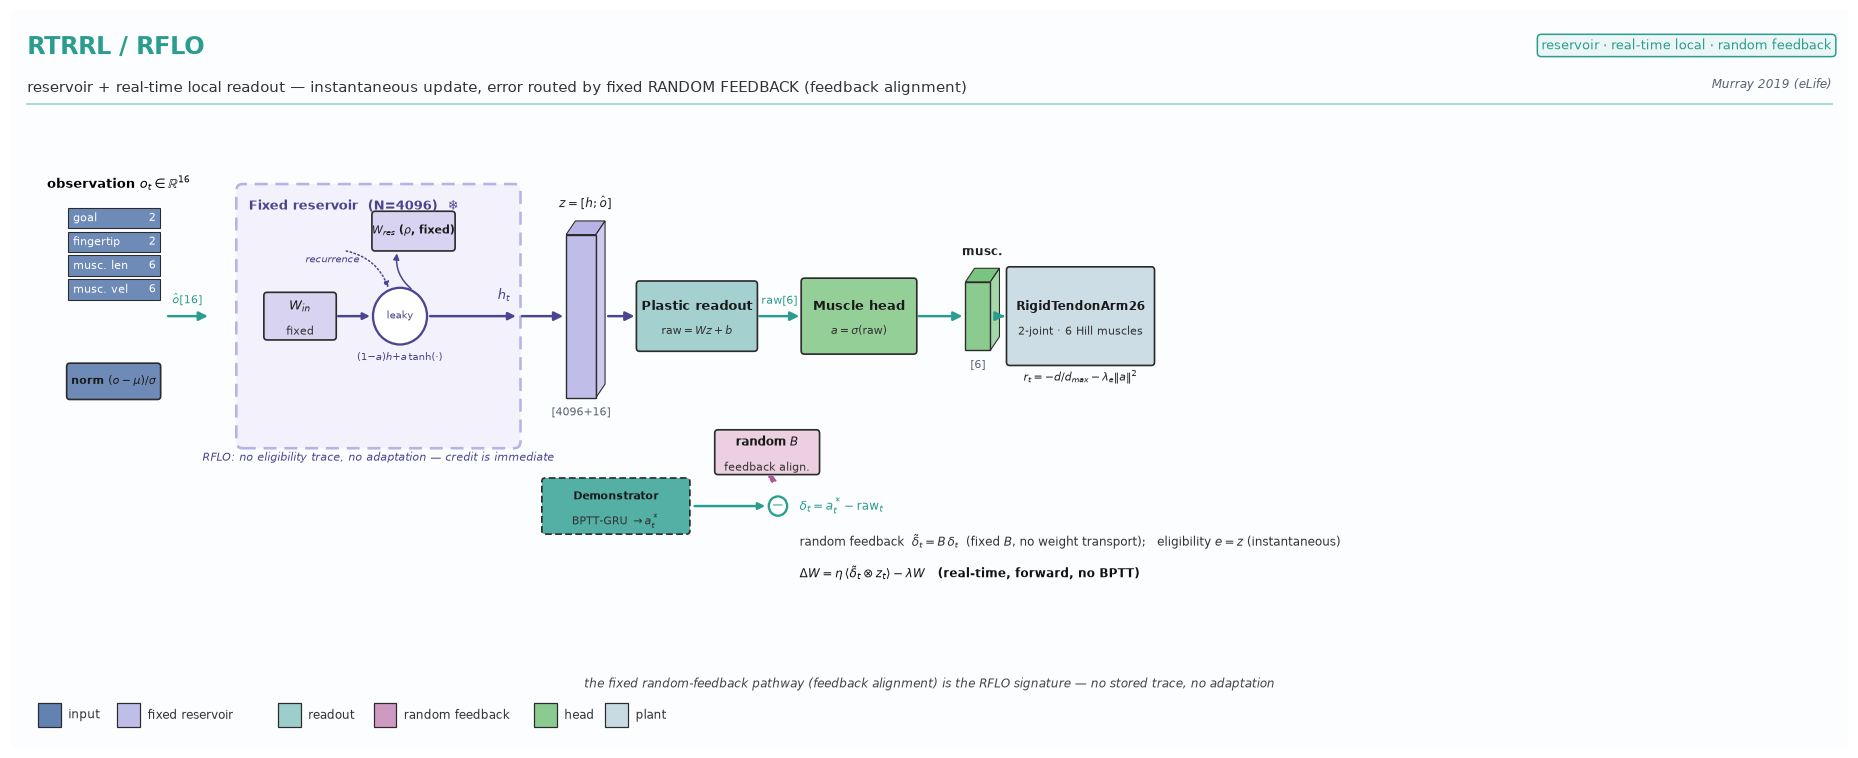

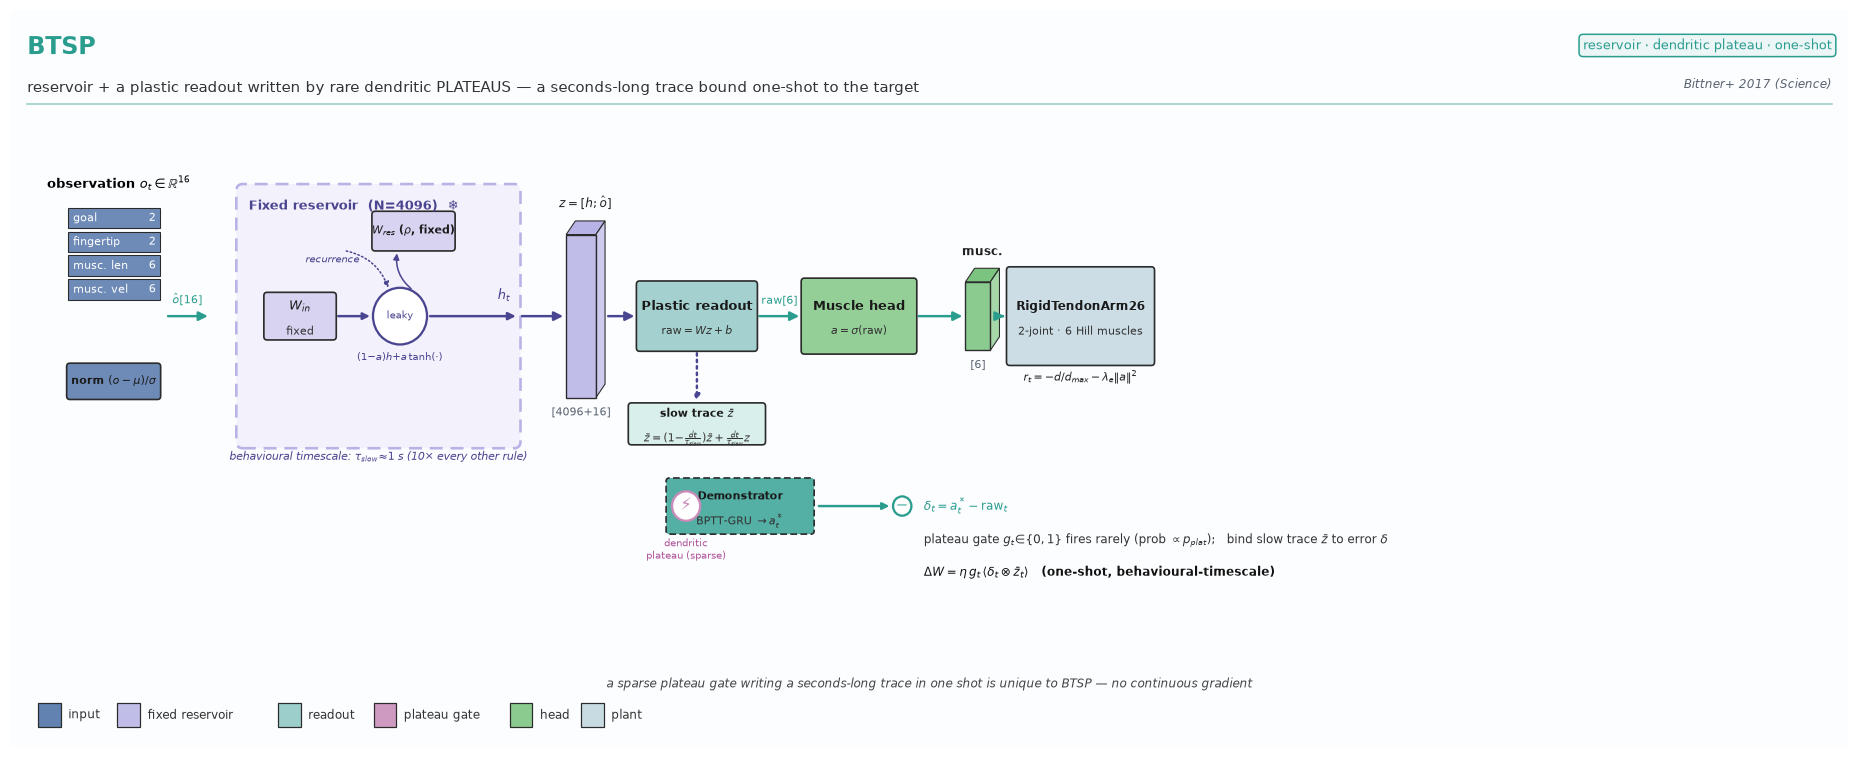

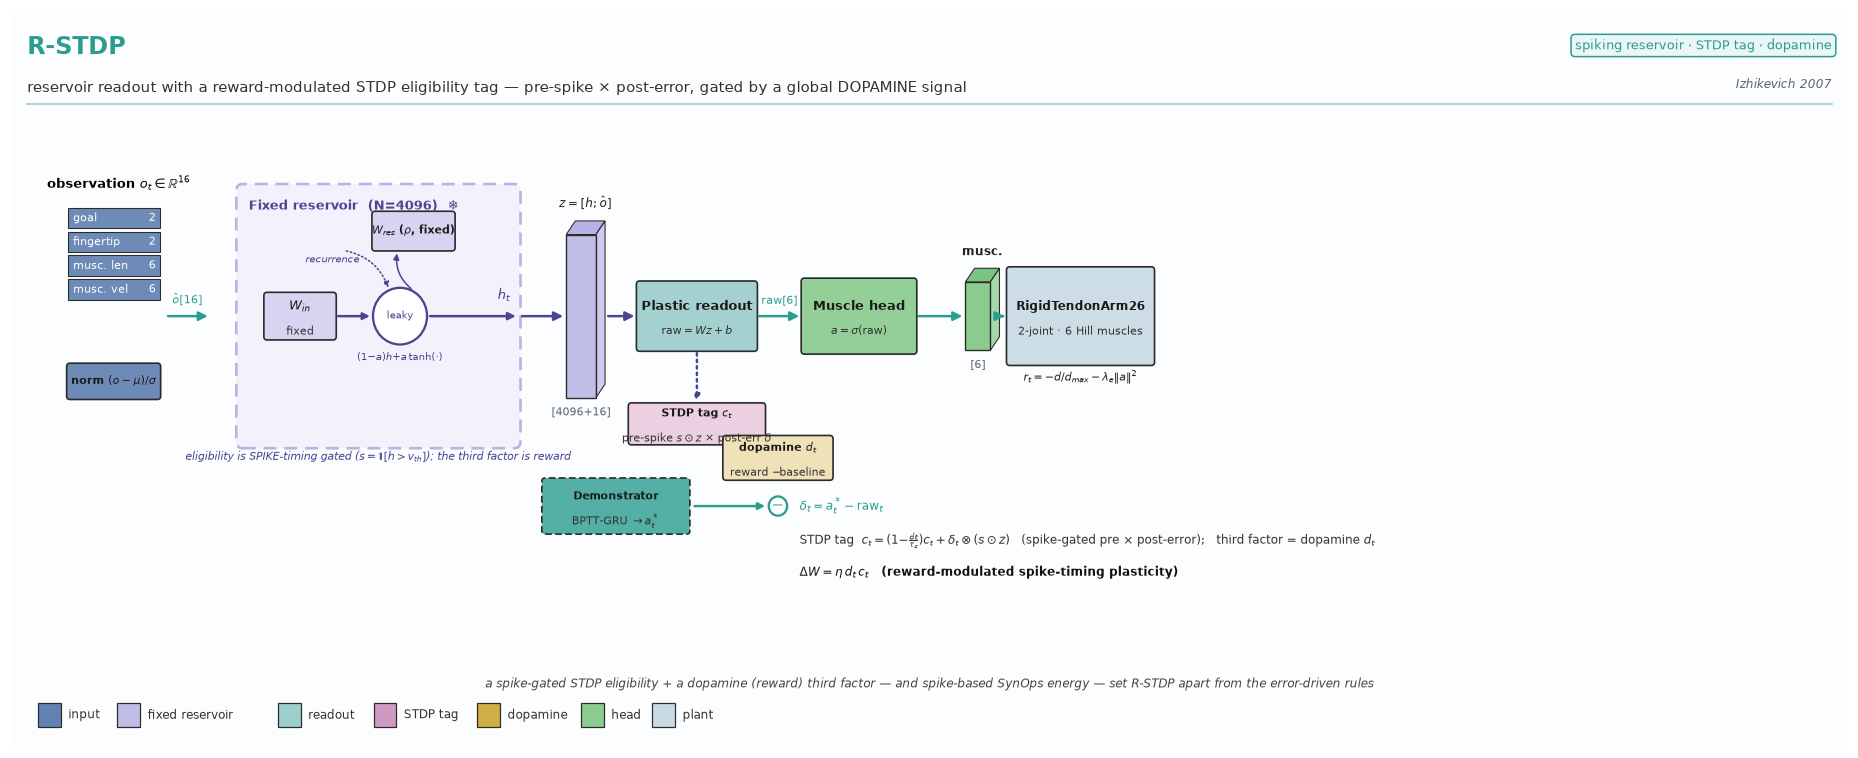

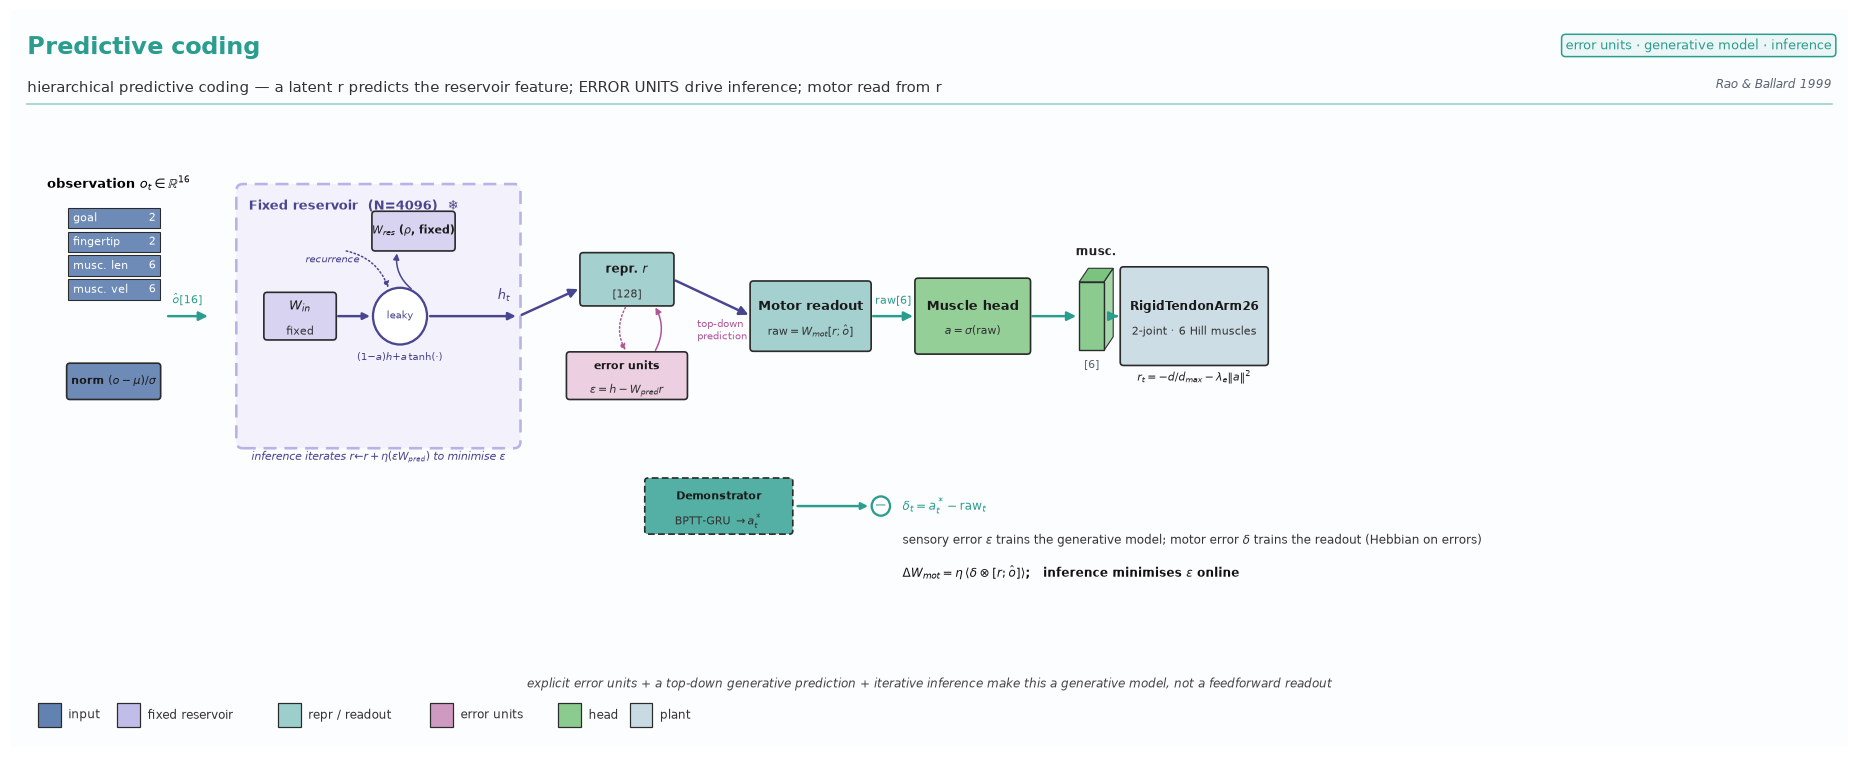

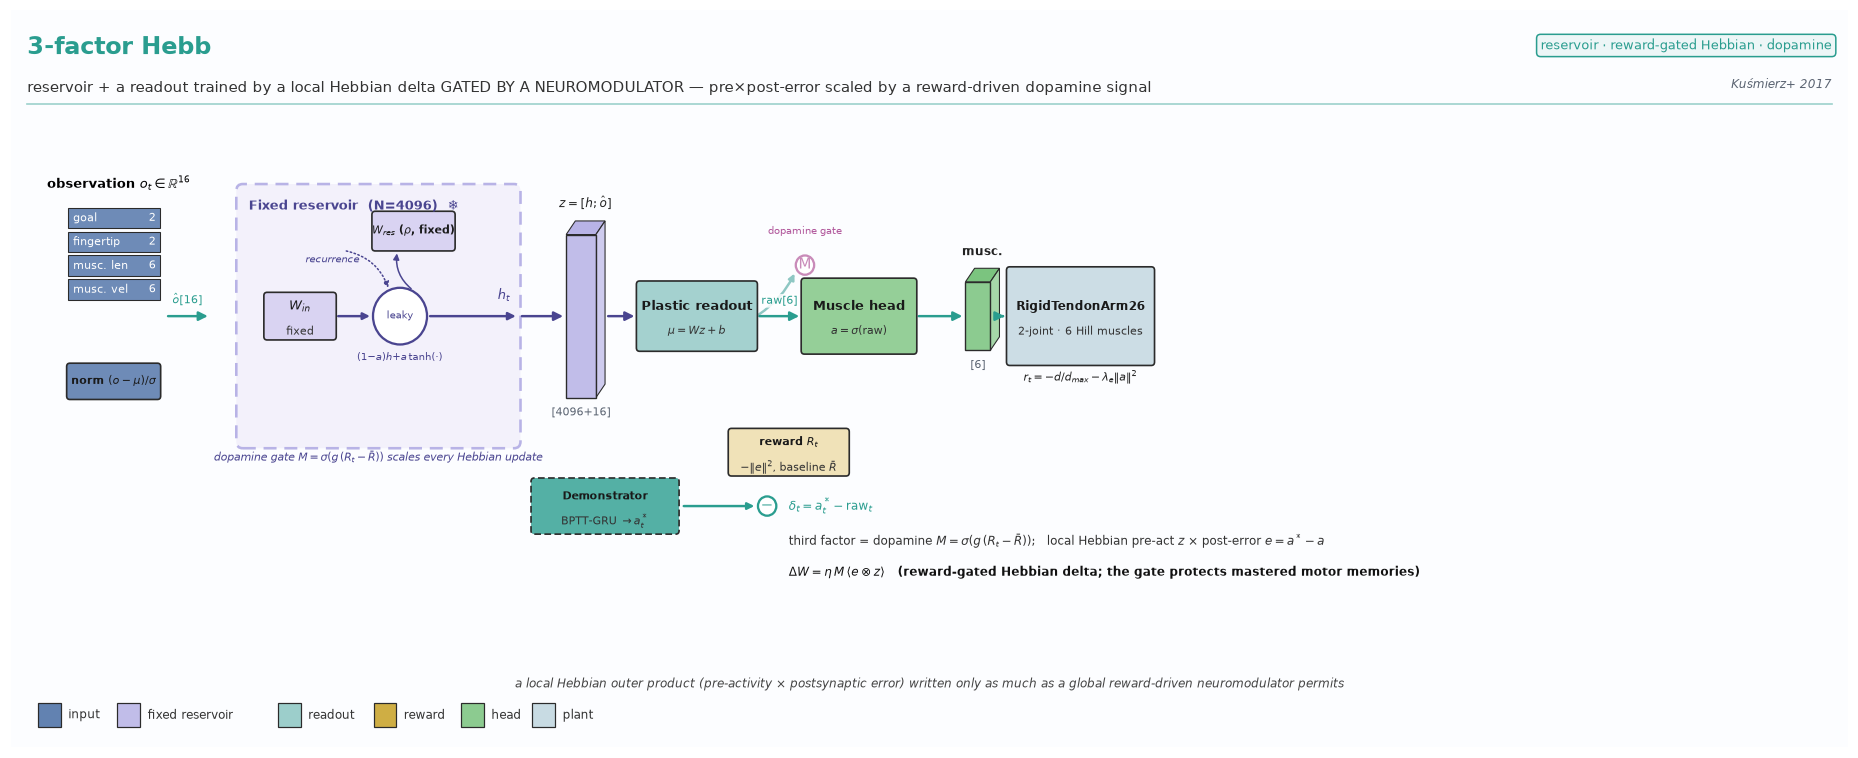

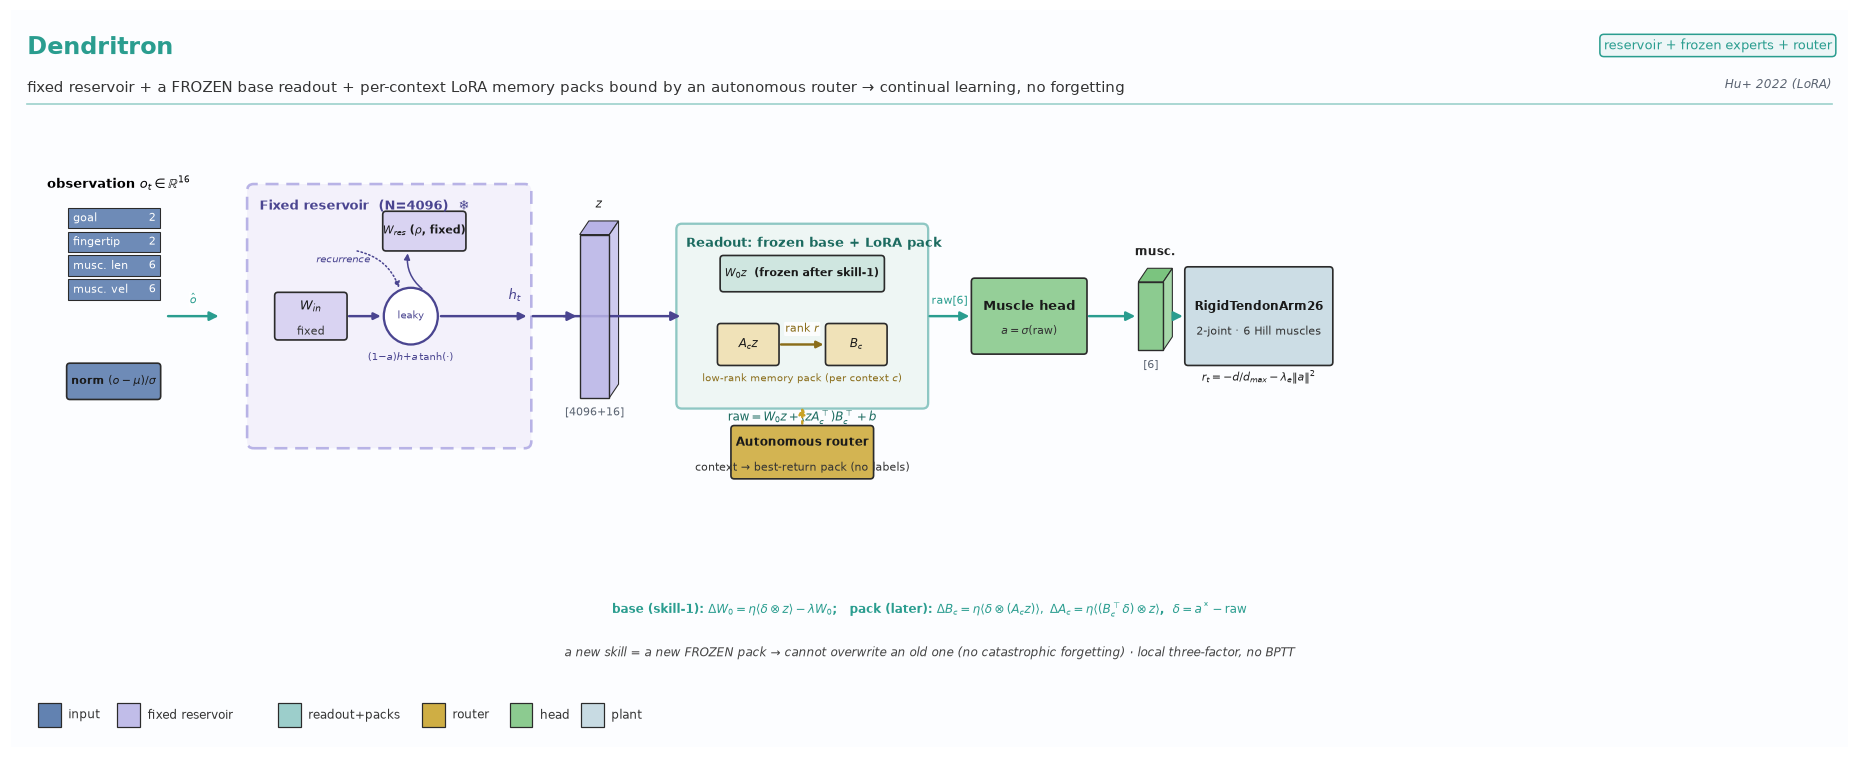


===== GLOBAL-GRADIENT microcircuits (5) =====


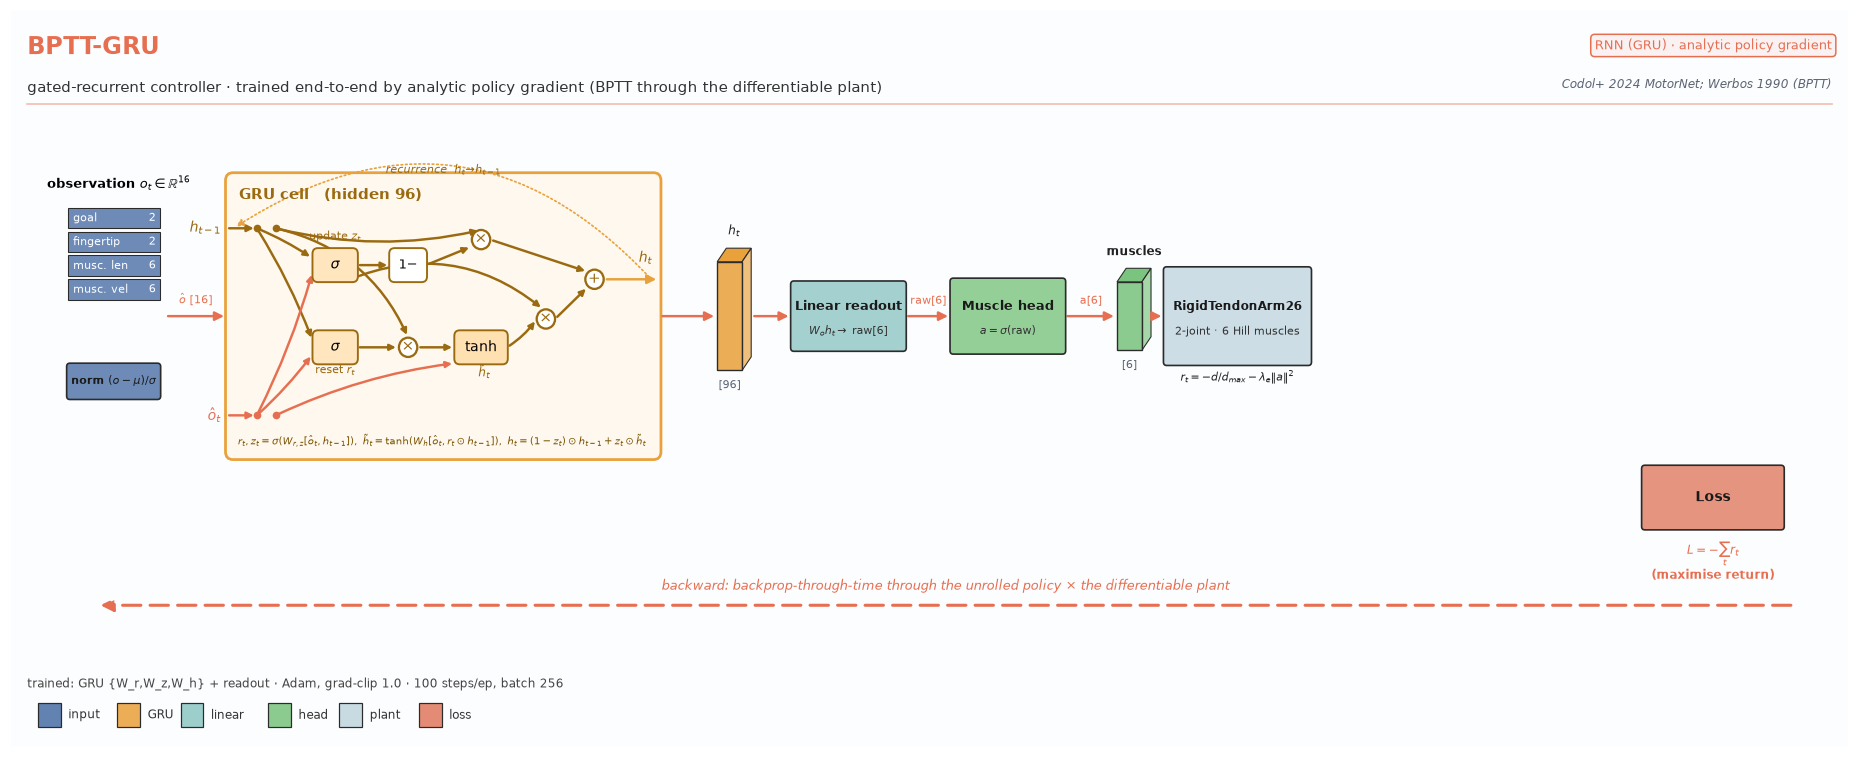

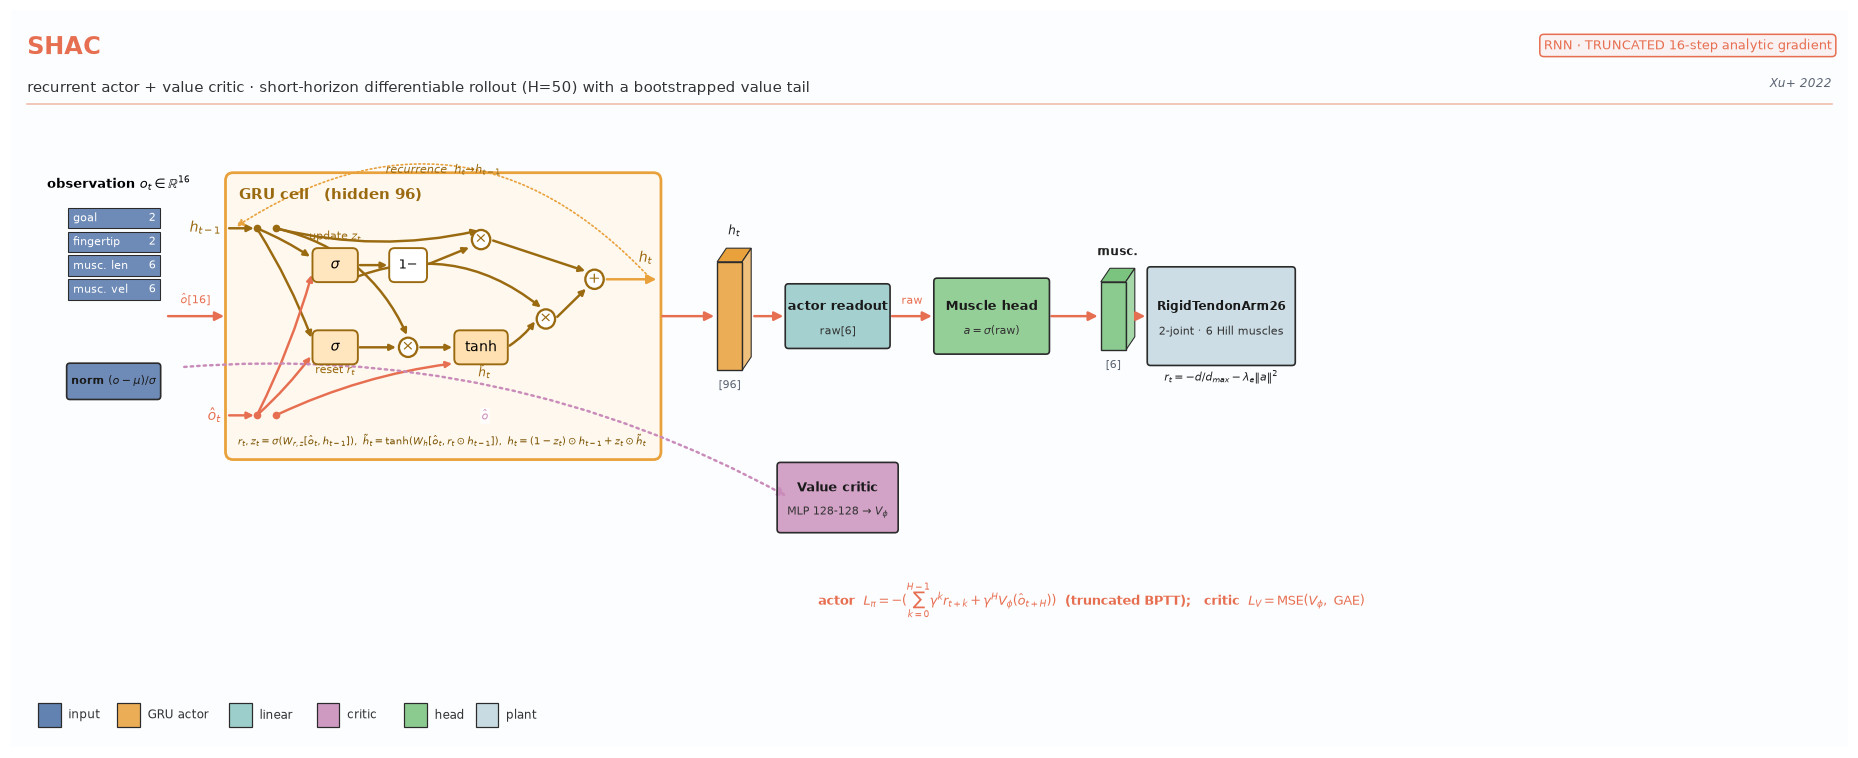

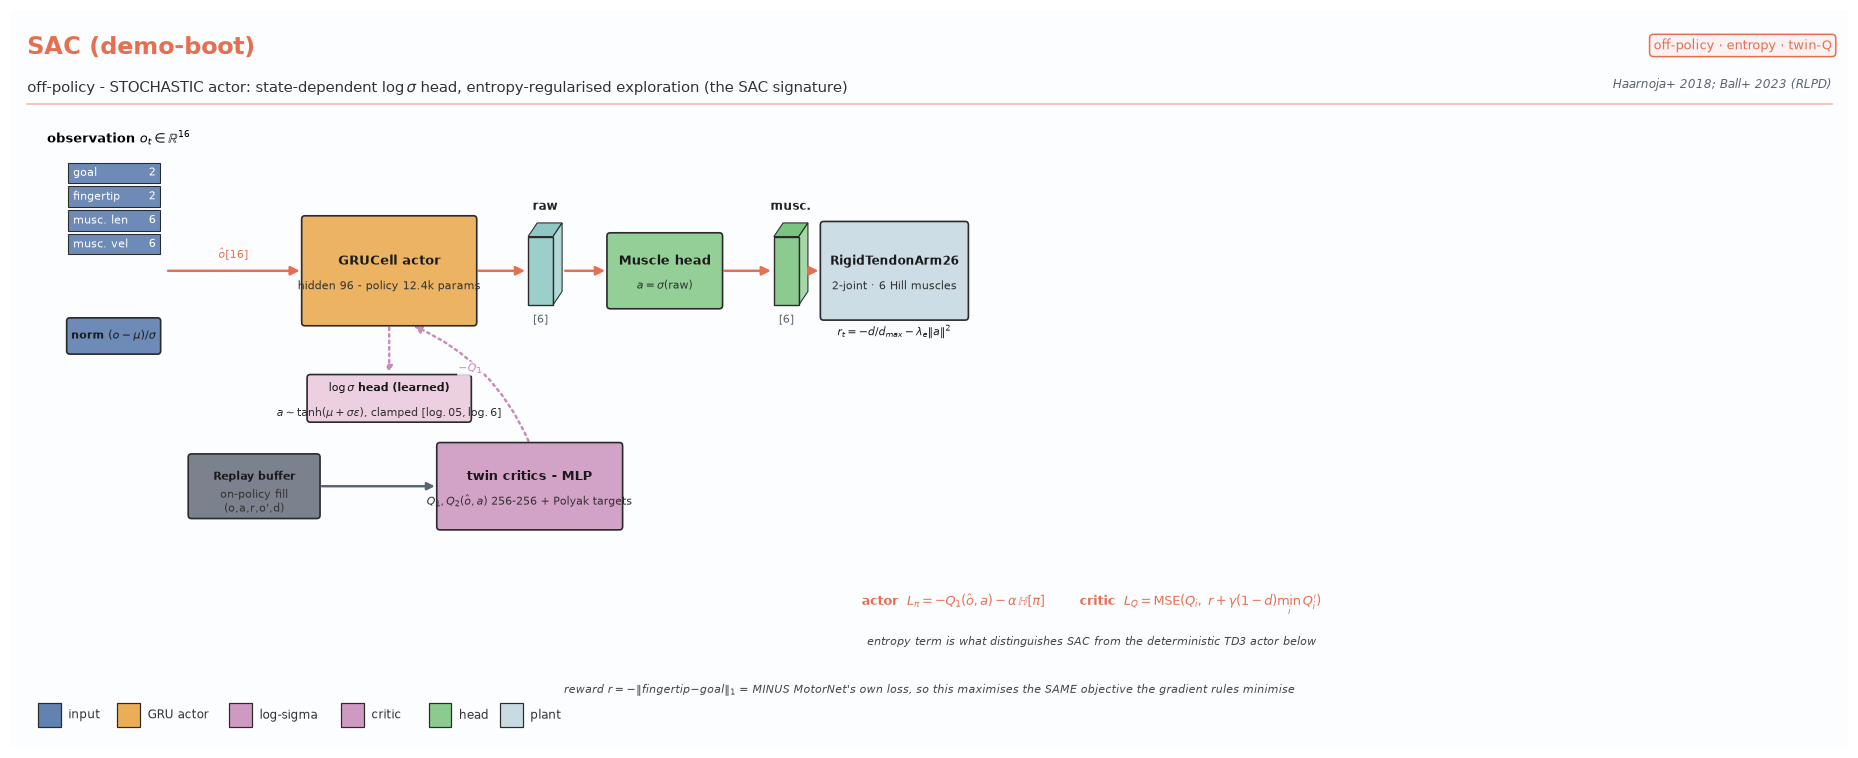

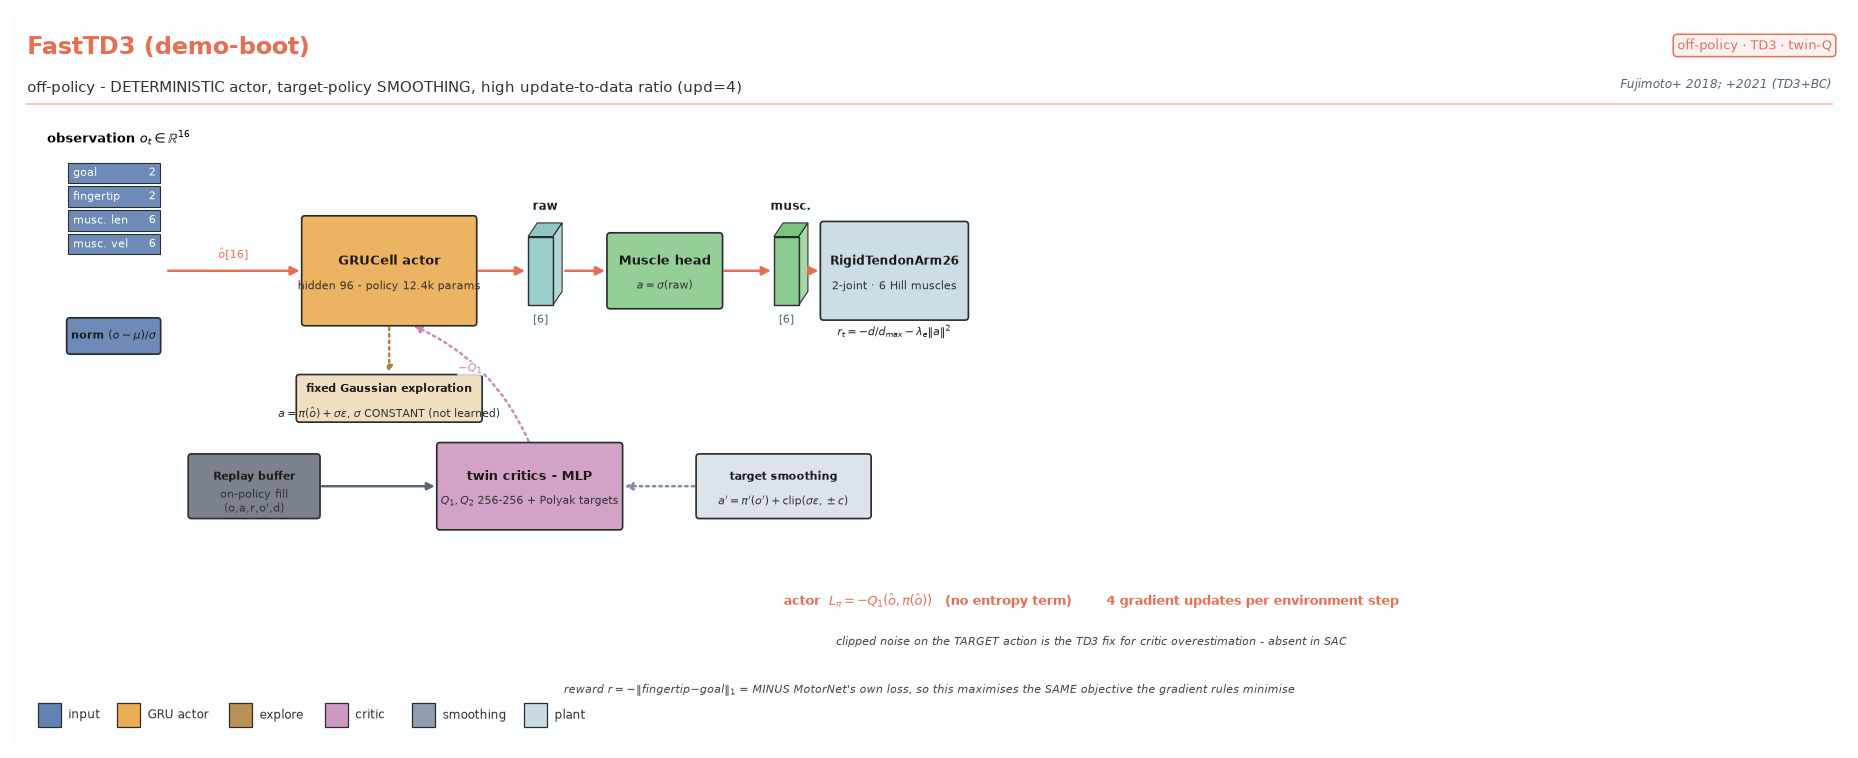

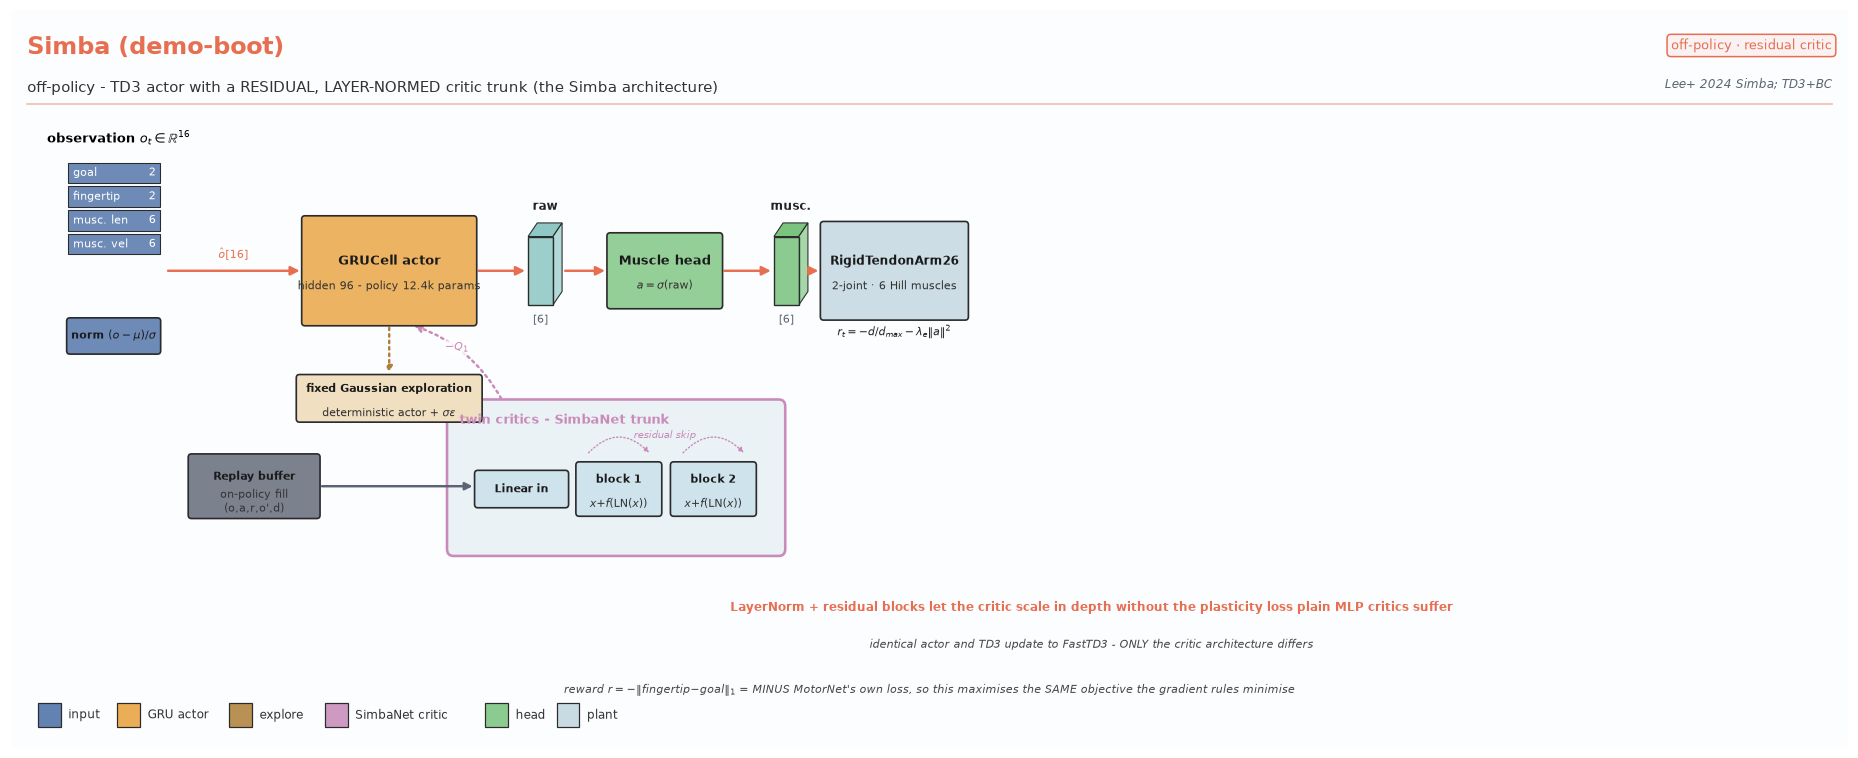


===== MORPHOLOGICAL microcircuits (1) =====


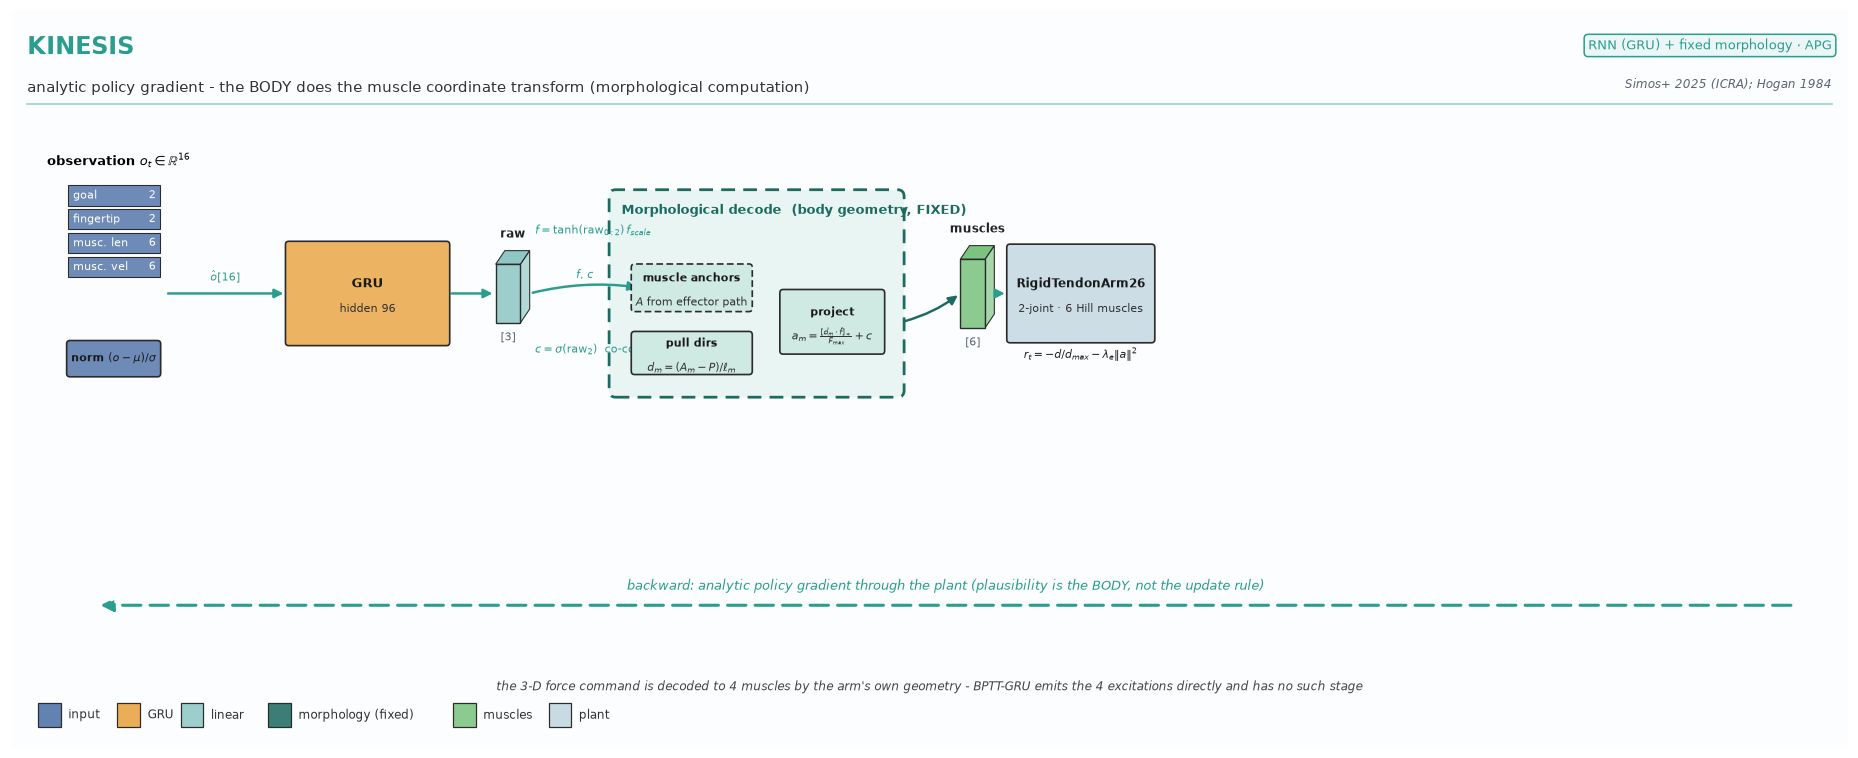

In [13]:
# III.1  architecture panel, grouped by family (reuses arch_detailed registry)
import matplotlib.pyplot as plt, arch_detailed as ad
for fam in ("local-plausible", "global-gradient", "morphological"):
    keys = [k for k in ad.ORDER if ad.SPECS[k]["family"] == fam]
    print(f"\n===== {fam.upper()} microcircuits ({len(keys)}) =====")
    for _k in keys:
        ad.RENDER[_k](ad.SPECS[_k], "arm"); plt.show()

### IX.2  Primitives — one function per microcircuit property

All operate on a condition-averaged PSTH `(D, T, U)`, so the **same code** runs on any AI
microcircuit (`acts[(tag,k)]`) and on cortex (`NEURAL[k]["psth"]`). No model objects, no torch.

In [14]:
# III.2  microcircuit / microlet primitives  (pure numpy; runs on cached acts + NEURAL)
import numpy as np

def _design(psth):                       # (D,T,U) -> (D*T, U), mean-centered
    D, T, U = psth.shape
    X = psth.reshape(D * T, U).astype(np.float64)
    return X - X.mean(0, keepdims=True)

def _cap_units(X, cap=1024):             # keep top-variance units so O(U^2) ops stay cheap
    if X.shape[1] <= cap: return X
    return X[:, np.argsort(X.var(0))[-cap:]]

def participation_ratio(psth):
    """Effective dimensionality PR = (Σλ)² / Σλ² over the population covariance spectrum.
    1 = one mode dominates; U = isotropic. The dimensionality a brain-like circuit should match."""
    X = _design(psth)
    s = np.linalg.svd(X, compute_uv=False); lam = s ** 2
    return float(lam.sum() ** 2 / (np.square(lam).sum() + 1e-24))

def eig_spectrum(psth, k=12):
    """Normalized covariance eigenvalues (scree) — the shape of the microcircuit's variance."""
    X = _design(psth)
    s = np.linalg.svd(X, compute_uv=False); lam = s ** 2
    lam = lam / (lam.sum() + 1e-24)
    return lam[:k]

def _pca_scores(psth, k):
    D, T, U = psth.shape
    X = _design(psth)
    U_, S, Vt = np.linalg.svd(X, full_matrices=False)
    k = min(k, Vt.shape[0])
    return (X @ Vt[:k].T).reshape(D, T, k)          # (D,T,k) trajectories

def effective_dynamics(psth, k=8, ridge=1e-2):
    """Reduced one-step linear operator M (k×k) from x_{t+1}≈M x_t, fit per direction on the
    top-k PCs (pooled ridge). Returns complex eigenvalues of M, spectral radius, and the count
    of PERSISTENT ROTATIONAL MICROLETS (complex-conjugate pairs with modulus>0.3)."""
    S = _pca_scores(psth, k)                        # (D,T,k)
    Xt = S[:, :-1, :].reshape(-1, S.shape[2])
    Yt = S[:, 1:,  :].reshape(-1, S.shape[2])
    G = Xt.T @ Xt + ridge * np.eye(Xt.shape[1])
    M = np.linalg.solve(G, Xt.T @ Yt).T             # x_{t+1} = M x_t
    ev = np.linalg.eigvals(M)
    n_rot = int(np.sum((ev.imag > 1e-3) & (np.abs(ev) > 0.3)))   # conjugate pairs, count one each
    return dict(eig=ev, spectral_radius=float(np.abs(ev).max()), n_rot=n_rot)

def ei_balance(psth, cap=1024):
    """E/I-like balance = fraction of POSITIVE off-diagonal signal correlations (excitatory-like
    co-activation) among the population. Cortex is balanced (~0.5); a runaway-excitatory circuit
    → 1. Sign-agnostic to unit scaling, works for firing rates and tanh states alike."""
    X = _cap_units(_design(psth), cap)
    C = np.corrcoef(X.T)
    iu = np.triu_indices(C.shape[0], 1)
    off = C[iu]; off = off[np.isfinite(off)]
    return float((off > 0).mean())

def activity_sparsity(psth, frac=0.1):
    """Sparsity of activity = mean over (direction,time) samples of the fraction of units whose
    |activation| is below `frac`×(peak |activation| in that sample). High = few units active at
    once = sparse code (a hallmark of cortical microcircuits)."""
    A = np.abs(psth.reshape(-1, psth.shape[2]).astype(np.float64))
    thr = frac * A.max(1, keepdims=True)
    return float((A < thr).mean())

# --- self-check: a known 2-plane rotation must show 2 rotational microlets; PR must be sane ---
def _demo():
    rng = np.random.RandomState(0); D, T, U = 8, 26, 40
    t = np.linspace(0, 6, T)
    lat = np.stack([np.stack([np.cos(t + p), np.sin(t + p),
                              np.cos(2*t + p), np.sin(2*t + p)], 1) for p in np.linspace(0, 1, D)])
    mix = rng.randn(4, U)
    psth = (lat @ mix) + 0.01 * rng.randn(D, T, U)
    ed = effective_dynamics(psth, k=6)
    assert ed["n_rot"] >= 2, ed["n_rot"]                       # two rotational planes -> >=2 microlets
    assert 1.0 < participation_ratio(psth) < U
    assert 0.0 <= ei_balance(psth) <= 1.0 and 0.0 <= activity_sparsity(psth) <= 1.0
    print("III.2 primitives self-check OK  (n_rot=%d, PR=%.1f)" % (ed["n_rot"], participation_ratio(psth)))
_demo()

III.2 primitives self-check OK  (n_rot=2, PR=3.2)


### IX.3  (a) Microcircuit geometry — dimensionality & eigenspectrum

Two questions: (1) does each AI microcircuit have a **participation ratio** near the cortical
one (cortex uses a low-D but not 1-D code)? (2) does its **eigenspectrum** (variance shape)
fall off like cortex? We plot HUMAN (human-IC + MEG) vs MONKEY (S1 + M1) vs AI (plausible vs
gradient), evaluating each AI microcircuit on **its own rollout** (`acts`) and each brain area
on its recording.

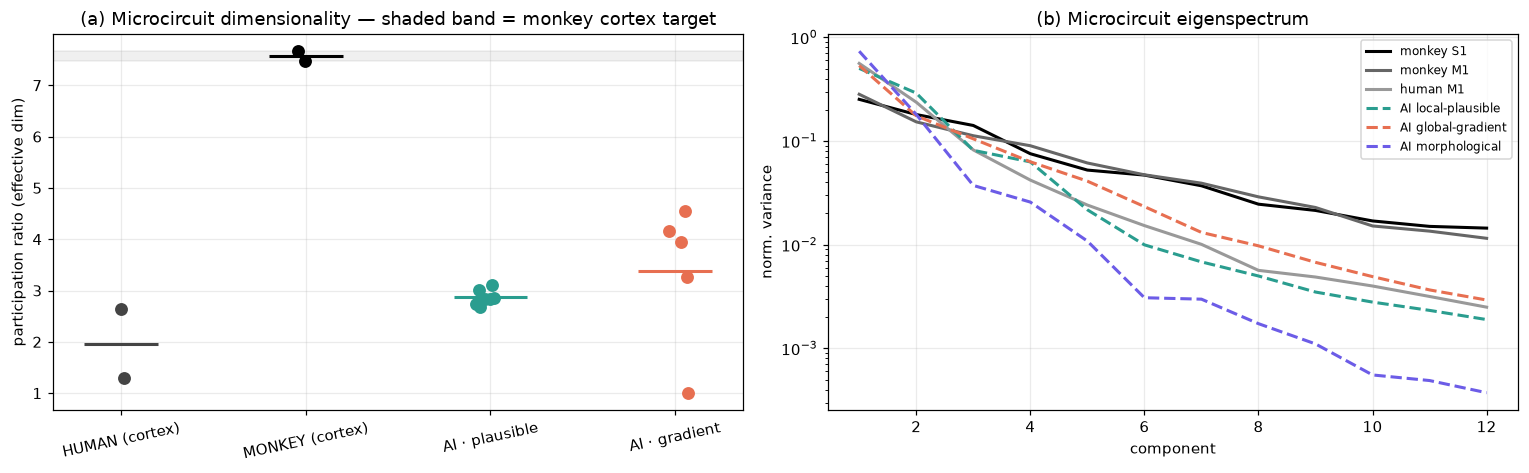

In [15]:
# III.3  (a) participation ratio + eigenspectrum, human vs monkey vs AI
import numpy as np, matplotlib.pyplot as plt

def _psth_for(t, k):        # AI microcircuit on dataset-k grid; falls back to s1 grid
    return acts.get((t, k), acts[(t, "s1")])

# group PR values
brain_pr = {k: participation_ratio(NEURAL[k]["psth"]) for k in NEURAL}
ai_pr = {t: participation_ratio(acts[(t, "s1")]) for t in TAG2CLS}   # common s1 grid for AI
grp = {"HUMAN (cortex)": [brain_pr["human_ic"], brain_pr["human"]],
       "MONKEY (cortex)": [brain_pr["s1"], brain_pr["m1"]],
       "AI · plausible": [ai_pr[t] for t in TAG2CLS if RESULTS[t]["kind"] == "local-plausible"],
       "AI · gradient":  [ai_pr[t] for t in TAG2CLS if RESULTS[t]["kind"] == "global-gradient"]}

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
# left: PR strip plot by group, monkey band shaded as the biological target
cols = ["#444", "#000", KIND_COLOR["local-plausible"], KIND_COLOR["global-gradient"]]
for i, (g, vals) in enumerate(grp.items()):
    ax[0].scatter(np.full(len(vals), i) + np.random.uniform(-.08, .08, len(vals)), vals,
                  color=cols[i], s=55, zorder=3)
    ax[0].hlines(np.mean(vals), i - .2, i + .2, color=cols[i], lw=2)
mk = grp["MONKEY (cortex)"]; ax[0].axhspan(min(mk), max(mk), color="#000", alpha=.06, zorder=0)
ax[0].set_xticks(range(4)); ax[0].set_xticklabels(list(grp), rotation=12)
ax[0].set_ylabel("participation ratio (effective dim)")
ax[0].set_title("(a) Microcircuit dimensionality — shaded band = monkey cortex target")

# right: eigenspectra — cortex (black) vs plausible/gradient means
K = 12; xs_ = np.arange(1, K + 1)
for k, c, lab in [("s1", "#000", "monkey S1"), ("m1", "#666", "monkey M1"),
                  ("human_ic", "#999", "human M1")]:
    ax[1].plot(xs_, eig_spectrum(NEURAL[k]["psth"], K), color=c, lw=2, label=lab)
for fam in ("local-plausible", "global-gradient", "morphological"):
    _mem = [eig_spectrum(acts[(t, "s1")], K) for t in TAG2CLS if RESULTS[t]["kind"] == fam]
    if not _mem: continue                      # family may be empty (e.g. no morphological model)
    sp = np.mean(_mem, 0)
    ax[1].plot(xs_, sp, "--", color=KIND_COLOR.get(fam, "#6c5ce7"), lw=2, label=f"AI {fam}")
ax[1].set_yscale("log"); ax[1].set_xlabel("component"); ax[1].set_ylabel("norm. variance")
ax[1].set_title("(b) Microcircuit eigenspectrum"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### IX.4  (b) Recurrent motifs — rotational "microlets", E/I balance, sparsity

We estimate each microcircuit's **effective recurrent dynamics** `M` from its own trajectory
(same estimator for brain and model) and count **rotational microlets** (persistent
complex-conjugate eigen-pairs). We add the two connectivity-microlet statistics: **E/I balance**
and **activity sparsity**. A brain-like microcircuit should have several rotational microlets,
E/I balance near cortex, and comparable sparsity.

,net,family,n_rot,spec_rad,ei,sparsity
0,Area2_Bump,cortex,2,0.937,0.584,0.504
1,MC_Maze,cortex,3,0.992,0.497,0.605
2,Human M1 intracortical,cortex,3,1.012,0.525,0.616
3,BPTT-GRU,global-gradient,2,1.002,0.497,0.126
4,SHAC-style short-horizon gradient,global-gradient,2,1.003,0.496,0.136
5,SAC,global-gradient,3,1.003,0.488,0.118
6,FastTD3,global-gradient,3,1.002,0.504,0.117
7,Simba,global-gradient,0,1.000,0.496,0.000
8,KINESIS,morphological,2,1.004,0.513,0.173
9,Dendritron,local-plausible,3,1.003,0.503,0.092


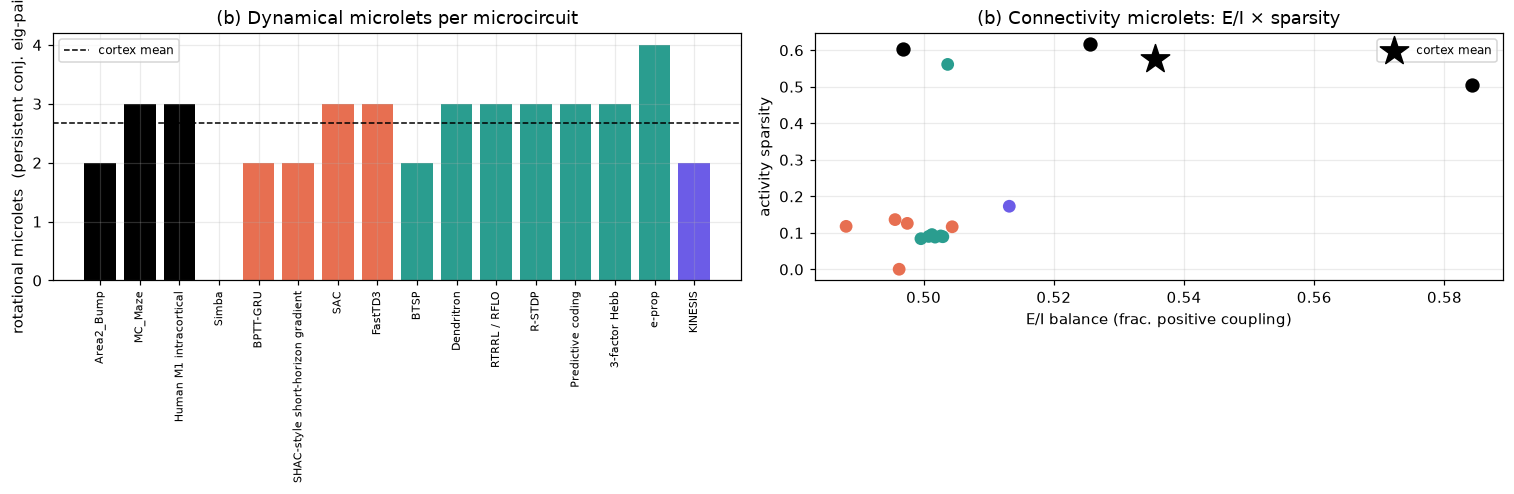

In [16]:
# III.4  (b) rotational microlets + E/I + sparsity, per network, vs cortex reference
import pandas as pd, numpy as np, matplotlib.pyplot as plt

def micro_stats(psth):
    ed = effective_dynamics(psth, k=8)
    return dict(n_rot=ed["n_rot"], spec_rad=ed["spectral_radius"],
                ei=ei_balance(psth), sparsity=activity_sparsity(psth))

rows = []
for k in ("s1", "m1", "human_ic"):                       # cortex references
    rows.append(dict(net=NEURAL[k]["name"].split(" (")[0], family="cortex", **micro_stats(NEURAL[k]["psth"])))
for t in TAG2CLS:                                        # AI microcircuits on shared s1 grid
    rows.append(dict(net=RESULTS[t]["name"].split(" (")[0].split(" +")[0],
                     family=RESULTS[t]["kind"], **micro_stats(acts[(t, "s1")])))
micro_df = pd.DataFrame(rows)
cortex_ref = micro_df[micro_df.family == "cortex"][["n_rot", "ei", "sparsity"]].mean()
display(micro_df.round(3))

# figure: rotational microlets (bar) + E/I-vs-sparsity plane with cortex target
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
order = micro_df.sort_values(["family", "n_rot"])
fcol = {"cortex": "#000", **KIND_COLOR}
ax[0].bar(range(len(order)), order.n_rot, color=[fcol[f] for f in order.family])
ax[0].axhline(cortex_ref.n_rot, ls="--", color="#000", lw=1, label="cortex mean")
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(order.net, rotation=90, fontsize=7)
ax[0].set_ylabel("rotational microlets  (persistent conj. eig-pairs)")
ax[0].set_title("(b) Dynamical microlets per microcircuit"); ax[0].legend(fontsize=8)

for _, r in micro_df.iterrows():
    ax[1].scatter(r.ei, r.sparsity, color=fcol[r.family], s=70,
                  edgecolor="k" if r.family == "cortex" else "none", zorder=3)
ax[1].scatter(cortex_ref.ei, cortex_ref.sparsity, marker="*", s=380, color="#000",
              zorder=4, label="cortex mean")
ax[1].set_xlabel("E/I balance (frac. positive coupling)"); ax[1].set_ylabel("activity sparsity")
ax[1].set_title("(b) Connectivity microlets: E/I × sparsity"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [17]:
# III.4b  OPTIONAL — TRUE recurrent-weight spectra (needs model objects; run only post-retrain,
# NOT during the GPU job). Reservoir learners share a fixed echo-state Wr by construction, so the
# discriminative learned structure is the readout W; GRU learners have a *trained* weight_hh.
# ponytail: guarded, off by default — flip RUN_WEIGHT_SPECTRA when a trained zoo is loadable.
RUN_WEIGHT_SPECTRA = False
if RUN_WEIGHT_SPECTRA:
    import torch as th, numpy as np, matplotlib.pyplot as plt
    def recurrent_matrix(L):
        if hasattr(L, "Wr"):                                   # fixed reservoir substrate
            return L.Wr.detach().cpu().numpy(), "reservoir Wr (fixed)"
        for m in L.modules():                                  # trained GRU candidate-gate block
            if isinstance(m, (th.nn.GRU, th.nn.GRUCell)):
                Whh = m.weight_hh_l0 if hasattr(m, "weight_hh_l0") else m.weight_hh
                H = Whh.shape[1]; return Whh.detach().cpu().numpy()[2*H:3*H], "GRU W_hh (candidate)"
        return None, None
    keys = [t for t in TAG2CLS if RESULTS[t]["kind"] == "local-plausible"][:3] + \
           [t for t in TAG2CLS if RESULTS[t]["kind"] == "global-gradient"][:3]
    fig, axes = plt.subplots(1, len(keys), figsize=(3*len(keys), 3))
    for ax_, t in zip(np.atleast_1d(axes), keys):
        L = load_learner(t); W, lab = recurrent_matrix(L)
        if W is None: continue
        ev = np.linalg.eigvals(W)
        ax_.scatter(ev.real, ev.imag, s=4, color=KIND_COLOR.get(RESULTS[t]["kind"], "#6c5ce7"))
        ax_.add_patch(plt.Circle((0, 0), 1, fill=False, ls=":", color="#999"))
        ax_.set_title(f"{RESULTS[t]['name'].split(' (')[0]}\n{lab} · ρ={np.abs(ev).max():.2f}\n"
                      f"E/I={np.mean(W>0):.2f}  sparse={np.mean(np.abs(W)<1e-3):.2f}", fontsize=7)
        ax_.axhline(0, color="#ccc", lw=.5); ax_.axvline(0, color="#ccc", lw=.5)
    plt.tight_layout(); plt.show()

### IX.5  (c) Micro cross-networks analysis — every microcircuit vs every other + cortex

Put all 13 AI microcircuits **and** monkey S1 cortex on the shared reach grid (8 dirs × 26
bins, from `acts[(t,"s1")]`) and compute pairwise **CKA** of their population geometry — a
*cross-networks similarity matrix*. Reordered so families group, we can read off whether
plausible microcircuits cluster **near the S1 block**. We then reuse the full `neuro_link`
alignment already stored in `link[t][k]` (CKA / Procrustes / predictivity) to score alignment
to monkey S1+M1 and human M1, per family.

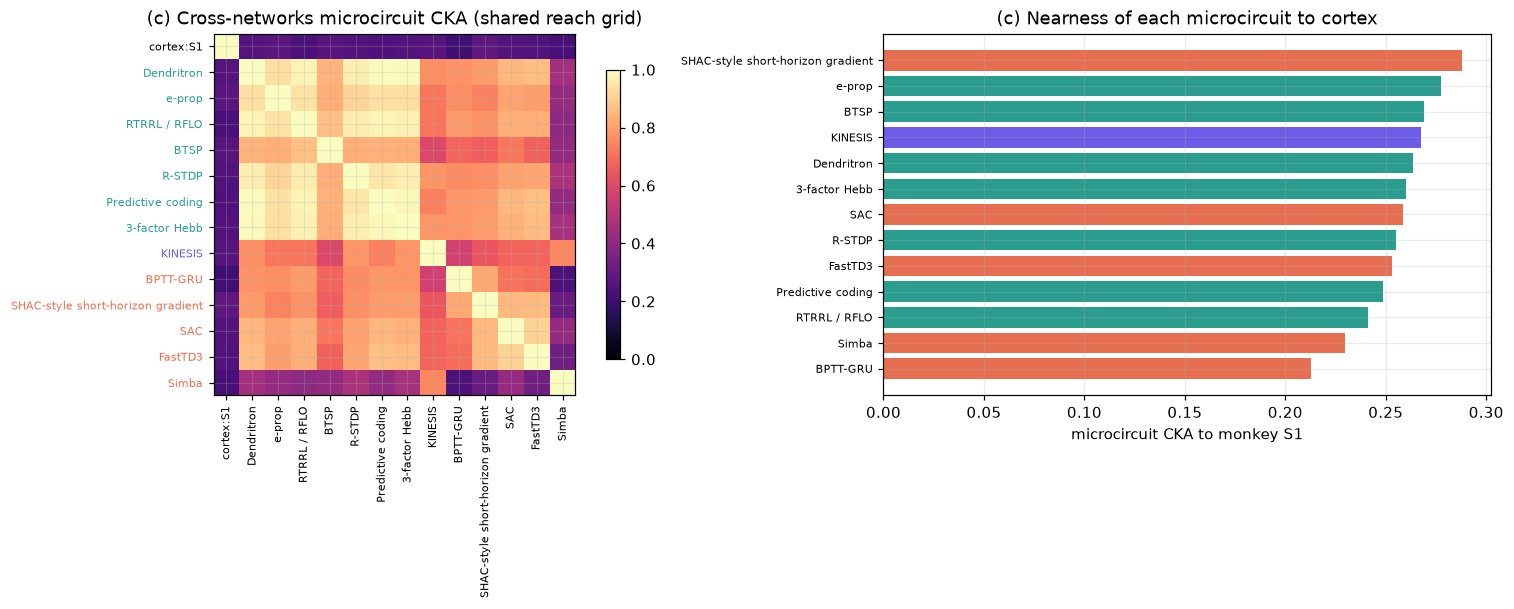

Mean microcircuit→cortex alignment by family:


,cka,procrustes,predictivity
family,,,
global-gradient,0.403,0.557,0.342
local-plausible,0.424,0.643,0.363
morphological,0.377,0.575,0.368


In [18]:
# III.5  (c) cross-networks CKA matrix over microcircuit geometry (shared s1 grid) + reused alignment
import numpy as np, matplotlib.pyplot as plt, pandas as pd

# --- big cross-network matrix: 13 models (acts on s1 grid) + S1 cortex ---
nets = [("cortex:S1", NEURAL["s1"]["psth"], "cortex")] + \
       [(RESULTS[t]["name"].split(" (")[0].split(" +")[0], acts[(t, "s1")], RESULTS[t]["kind"])
        for t in TAG2CLS]
# order: cortex first, then plausible, then gradient (families block together)
ordv = sorted(range(len(nets)),
              key=lambda i: {"cortex": 0, "local-plausible": 1, "morphological": 2,
                             "global-gradient": 3}.get(nets[i][2], 4))
nets = [nets[i] for i in ordv]
labels = [n[0] for n in nets]; N = len(nets)
CKA = np.eye(N)
for i in range(N):
    for j in range(i + 1, N):
        CKA[i, j] = CKA[j, i] = nl.linear_cka(nets[i][1], nets[j][1])

fig, ax = plt.subplots(1, 2, figsize=(15, 5.6))
im = ax[0].imshow(CKA, vmin=0, vmax=1, cmap="magma")
ax[0].set_xticks(range(N)); ax[0].set_xticklabels(labels, rotation=90, fontsize=7)
ax[0].set_yticks(range(N)); ax[0].set_yticklabels(labels, fontsize=7)
# tick colored by family
for tk, n in zip(ax[0].get_yticklabels(), nets):
    tk.set_color({"cortex": "#000", **KIND_COLOR}.get(n[2], "#444"))
ax[0].set_title("(c) Cross-networks microcircuit CKA (shared reach grid)"); fig.colorbar(im, ax=ax[0], shrink=.8)

# per-model CKA-to-S1 (first column), colored by family, sorted
cka_s1 = [(labels[i], CKA[i, 0], nets[i][2]) for i in range(1, N)]
cka_s1.sort(key=lambda x: x[1])
ax[1].barh(range(len(cka_s1)), [c[1] for c in cka_s1],
           color=[KIND_COLOR[c[2]] for c in cka_s1])
ax[1].set_yticks(range(len(cka_s1))); ax[1].set_yticklabels([c[0] for c in cka_s1], fontsize=7)
ax[1].set_xlabel("microcircuit CKA to monkey S1"); ax[1].set_title("(c) Nearness of each microcircuit to cortex")
plt.tight_layout(); plt.show()

# --- reuse stored full-alignment (S1+M1 intracortical, human M1) by family ---
def align_to_cortex(t):
    ks = [k for k in ("s1", "m1", "human_ic") if (t, k) in acts]
    return {m: float(np.mean([link[t][k][m] for k in ks]))
            for m in ("cka", "procrustes", "predictivity")}
al = pd.DataFrame([dict(model=RESULTS[t]["name"].split(" (")[0].split(" +")[0],
                        family=RESULTS[t]["kind"], **align_to_cortex(t)) for t in TAG2CLS])
print("Mean microcircuit→cortex alignment by family:")
display(al.groupby("family")[["cka", "procrustes", "predictivity"]].mean().round(3))

### IX.6  (d) Summary — ranking microcircuit-likeness (plausible vs non-plausible)

Combine five microcircuit criteria into one rank-averaged score (Brain-Score style, via
`neuro_link.leaderboard`): alignment to cortex (**CKA**, **Procrustes**, **predictivity**),
**dimensionality match** (closeness of PR to monkey-S1 PR) and **rotational-microlet match**
(closeness of the microlet count to cortex). Higher rank = more brain-like microcircuit. The
hypothesis: the local-plausible family dominates the top of the board.

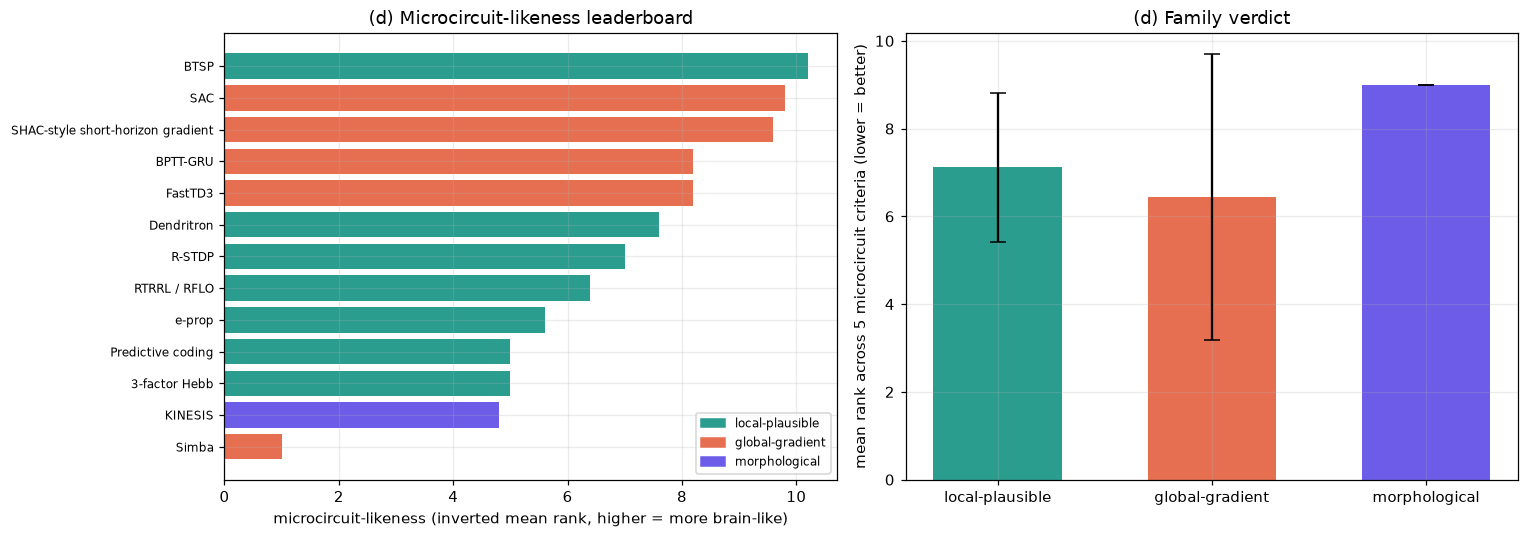

Most brain-like microcircuit family (mean rank): global-gradient
Top-3 microcircuits: ['BTSP', 'SAC', 'SHAC-style short-horizon gradient']


In [19]:
# III.6  (d) microcircuit-likeness leaderboard + family summary
import numpy as np, matplotlib.pyplot as plt

pr_cortex  = participation_ratio(NEURAL["s1"]["psth"])
rot_cortex = effective_dynamics(NEURAL["s1"]["psth"], k=8)["n_rot"]

per_model = {}
for t in TAG2CLS:
    a = align_to_cortex(t)                                   # from III.5
    pr_m  = participation_ratio(acts[(t, "s1")])
    rot_m = effective_dynamics(acts[(t, "s1")], k=8)["n_rot"]
    per_model[RESULTS[t]["name"].split(" (")[0].split(" +")[0]] = dict(
        cka=a["cka"], procrustes=a["procrustes"], predictivity=a["predictivity"],
        dim_match=1.0 / (1.0 + abs(pr_m - pr_cortex)),       # higher = PR closer to cortex
        rot_match=1.0 / (1.0 + abs(rot_m - rot_cortex)),
        _family=RESULTS[t]["kind"])

board = nl.leaderboard(per_model,
                       metrics=("cka", "procrustes", "predictivity", "dim_match", "rot_match"))
fam_of = {nm: per_model[nm]["_family"] for nm in per_model}

names = [b[0] for b in board][::-1]; mrank = [b[1] for b in board][::-1]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].barh(range(len(names)), [max(mrank) + 1 - r for r in mrank],   # invert so longer=better
           color=[KIND_COLOR.get(fam_of[n], "#6c5ce7") for n in names])
ax[0].set_yticks(range(len(names))); ax[0].set_yticklabels(names, fontsize=8)
ax[0].set_xlabel("microcircuit-likeness (inverted mean rank, higher = more brain-like)")
ax[0].set_title("(d) Microcircuit-likeness leaderboard")
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color=KIND_COLOR[f], label=f) for f in ("local-plausible", "global-gradient", "morphological")],
             fontsize=8, loc="lower right")

# family summary: mean rank ± sd (lower rank = better)
for i, fam in enumerate(("local-plausible", "global-gradient", "morphological")):
    rr = [b[1] for b in board if fam_of[b[0]] == fam]
    ax[1].bar(i, np.mean(rr), yerr=np.std(rr), width=.6, color=KIND_COLOR.get(fam, "#6c5ce7"), capsize=5)
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(["local-plausible", "global-gradient", "morphological"])
ax[1].set_ylabel("mean rank across 5 microcircuit criteria (lower = better)")
ax[1].set_title("(d) Family verdict")
plt.tight_layout(); plt.show()

winner = "local-plausible" if np.mean([b[1] for b in board if fam_of[b[0]] == "local-plausible"]) < \
                              np.mean([b[1] for b in board if fam_of[b[0]] == "global-gradient"]) else "global-gradient"
print(f"Most brain-like microcircuit family (mean rank): {winner}")
print("Top-3 microcircuits:", [b[0] for b in board[:3]])

### IX.7  What Section IX establishes

- Every controller solves the reach with a **recurrent microcircuit**; we measured that circuit's
  *internal* geometry, dynamics and connectivity, not just its accuracy.
- **Microlets** (rotational eigen-modes of the effective dynamics) and connectivity motifs (E/I
  balance, sparsity) are defined identically for human, monkey and AI, so the comparison is fair.
- The **micro cross-networks CKA matrix** and the **microcircuit-likeness leaderboard** test
  whether biological plausibility buys brain-like microcircuit structure. Read the family verdict
  off IX.6 once the retrain's `linking.pkl` is regenerated.

Section X takes these same microcircuits **stage-by-stage** (acquire / target-on / go / reach)
and adds sparse-coding, dimensionality and attention analyses to reach the OOD-generalization,
continual-learning and energy-efficiency conclusions.

# X. Conclusion — generalization, continual learning, energy, across cells and species

We close the way Neuromatch **W1D1 Tutorial 2** frames it: a model that merely *fits*
the task is not the goal — the goal is a model that **generalizes** the way cortex does.
The tutorial makes that case with three moves: (i) an inductive bias (regularization /
biological constraints) that makes hidden units more brain-like, (ii) an out-of-distribution
stress test (input- and weight-perturbation) showing generalization ≠ training accuracy, and
(iii) a *qualitative* PSTH comparison to real M1. We keep the narrative and supply the
quantitative layer the tutorial lacks, then push it across **four reach stages** and **four
neural datasets, two species**.

Our inductive-bias axis is the model **family**: the 8 *local-plausible* learners are the
"regularized / biologically-constrained" arm; the 5 *global-gradient* learners are the
"unregularized" arm. We ask whether plausibility buys the three things the tutorial cares
about — brain-likeness, OOD robustness, and (our additions) continual-learning stability and
energy efficiency — and *where in the reach* it buys them.

**Reach stages.** Every reach is segmented into
`TARGET-ONSET` (instructed-delay planning) → `GO-CUE` (reaction, movement onset) →
`REACH` (active transport) → `ACQUIRE` (settled/touching target). Monkey S1/M1 PSTHs are
movement-onset-aligned so all four resolve; model rollouts and the human sets have no shipped
delay marker, so `TARGET-ONSET` is left empty there rather than invented (an honest limit, and
itself a finding: the no-delay MotorNet task gives the models nothing to *plan*).

**Four analyses, then the crossing.**
1. **Sparse coding** — lifetime/population sparseness, kurtosis, near-zero fraction of AI
   units vs monkey S1, monkey M1, human M1, human MEG, per stage.
2. **Dimensionality** — PCA participation ratio + shared-vs-private subspace (canonical
   correlations), per stage, cross-species.
3. **Attention across stages** — a stage-selectivity / attention weighting over units:
   which cells "light up" when, for AI vs brain.
4. **The crossing** — stage-resolved CKA and linear predictivity between **AI neuron
   activation and real brain activation**, giving a cross-species × cross-stage matrix.

We then tie the geometry back to the three generalization payoffs: **OOD** (`zs_mean`),
**continual learning** (Dendritron's frozen experts), and **energy** (spike sparsity → a
relative ops-energy proxy).

In [20]:
# ============================================================================
# IV.0  Reach-stage segmentation + shared metric helpers.
# ONE recipe for model rollouts AND neural PSTHs (research stage-timing inventory):
#   monkey S1/M1  -> times cross 0 (move onset) -> anchor on t=0, all 4 stages.
#   model/human   -> no move-onset marker -> derive the movement ramp from population
#                    "neural speed" ‖d/dt pop-vector‖. TARGET-ONSET stays empty (flagged).
# ============================================================================
from collections import OrderedDict
from scipy.stats import kurtosis as _kurt
from neuro_link import align_time, feature_matrix

STAGES = ["TARGET-ONSET", "GO-CUE", "REACH", "ACQUIRE"]
STAGE_COLOR = dict(zip(STAGES, ["#8d99ae", "#457b9d", "#e63946", "#2a9d8f"]))
MK = "s1" if "s1" in NEURAL else next(iter(NEURAL))          # canonical model dataset (8 dirs)

def _pop_speed(psth):                                        # (T,) direction-averaged pop speed
    pop = psth.mean(0)
    sp = np.linalg.norm(np.diff(pop, axis=0), axis=1)
    return np.concatenate([sp[:1], sp])

def stage_masks(psth, times=None):
    """OrderedDict stage -> bool mask over the T axis of a (D,T,U) PSTH."""
    D, T, U = psth.shape
    t = np.asarray(times, float) if times is not None else np.arange(T, dtype=float)
    m = OrderedDict((s, np.zeros(T, bool)) for s in STAGES)
    if times is not None and t.min() < 0 < t.max():          # move-onset-aligned (monkey)
        go, settle = 0.5 * t.min(), 0.6 * t.max()
        m["TARGET-ONSET"] = t < go
        m["GO-CUE"]       = (t >= go) & (t < 0)
        m["REACH"]        = (t >= 0) & (t < settle)
        m["ACQUIRE"]      = t >= settle
    else:                                                    # ramp-derived (model / human)
        sp = _pop_speed(psth); thr = 0.2 * sp.max() if sp.max() > 0 else np.inf
        onset = int(np.argmax(sp > thr)) if (sp > thr).any() else 0
        peak  = int(np.argmax(sp)); tail = np.where(sp[peak:] < thr)[0]
        acq   = max(peak + int(tail[0]) if len(tail) else int(0.8 * T), onset + 1)
        idx = np.arange(T)
        m["GO-CUE"]  = idx < onset
        m["REACH"]   = (idx >= onset) & (idx < acq)
        m["ACQUIRE"] = idx >= acq                            # TARGET-ONSET left empty (no delay marker)
    return m

def present(masks, min_bins=2):
    return [s for s in STAGES if masks[s].sum() >= min_bins]

# --- sparse-coding, dimensionality, attention primitives (all on rectified rate) ---
def _rect(psth):
    return np.clip(psth - psth.min(axis=(0, 1), keepdims=True), 0, None)

def _sparseness(R, axis):                                    # Treves-Rolls / Vinje-Gallant, [0,1]
    N = R.shape[axis]
    return (1 - R.mean(axis) ** 2 / ((R ** 2).mean(axis) + 1e-12)) / (1 - 1.0 / N)

def sparsity_stats(psth, mask):
    R = _rect(psth)[:, mask, :]
    S = R.reshape(-1, R.shape[2])                            # (samples, units)
    return dict(pop=float(_sparseness(S, 1).mean()),         # population sparseness
                life=float(_sparseness(S, 0).mean()),        # lifetime sparseness
                near_zero=float((S < 0.05 * (S.max() + 1e-12)).mean()),
                kurt=float(np.nan_to_num(_kurt(S.ravel()))))

def pr_stage(psth, mask):
    X = _rect(psth)[:, mask, :].reshape(-1, psth.shape[2]); X = X - X.mean(0)
    lam = np.linalg.svd(X, compute_uv=False) ** 2
    return float(lam.sum() ** 2 / (np.square(lam).sum() + 1e-12))

def _sample_basis(psth, mask):                              # orthonormal sample-space basis
    X = feature_matrix(psth[:, mask, :]); X = X - X.mean(0)
    Ub, s, _ = np.linalg.svd(X, full_matrices=False)
    return Ub[:, s > 1e-8 * s.max()]

def shared_cc(mp, npsth, mmask, nmask, k=3):
    """Top-k canonical correlations^2 between two PSTHs on their stage slices (shared subspace)."""
    a, b = align_time(mp[:, mmask, :], npsth[:, nmask, :])   # -> common T, D preserved
    ma = np.zeros(a.shape[1], bool); nb = np.zeros(b.shape[1], bool); ma[:] = True; nb[:] = True
    Ua, Ub = _sample_basis(a, ma), _sample_basis(b, nb)
    cc = np.clip(np.linalg.svd(Ua.T @ Ub, compute_uv=False)[:k], 0, 1)
    return float((cc ** 2).mean())

def stage_attention(psth, masks, stages):
    """Per-unit attention weight over stages (min-shifted, sum-to-1) -> preferred stage + selectivity."""
    R = _rect(psth)
    M = np.stack([R[:, masks[s], :].mean((0, 1)) for s in stages], 0)   # (nstage, U)
    w = M / (M.sum(0, keepdims=True) + 1e-12)   # per-unit stage-preference distribution
    ent = -(w * np.log(w + 1e-12)).sum(0) / np.log(len(stages))
    pref = w.argmax(0)
    return dict(frac_pref={s: float((pref == i).mean()) for i, s in enumerate(stages)},
                mean_sel=float((1 - ent).mean()))

# self-check (no torch): monkey-like axis -> 4 stages, model-like axis -> 3, no TARGET-ONSET
_tt = np.linspace(-100, 400, 26)
assert present(stage_masks(np.random.rand(8, 26, 5), _tt)) == STAGES
assert "TARGET-ONSET" not in present(stage_masks(np.random.rand(8, 100, 5)))
print("stages per neural dataset:",
      {k: present(stage_masks(NEURAL[k]["psth"], NEURAL[k]["times"])) for k in NEURAL})

stages per neural dataset: {'s1': ['TARGET-ONSET', 'GO-CUE', 'REACH', 'ACQUIRE'], 'm1': ['TARGET-ONSET', 'GO-CUE', 'REACH', 'ACQUIRE'], 'human_ic': ['REACH', 'ACQUIRE'], 'human': ['GO-CUE', 'REACH', 'ACQUIRE']}


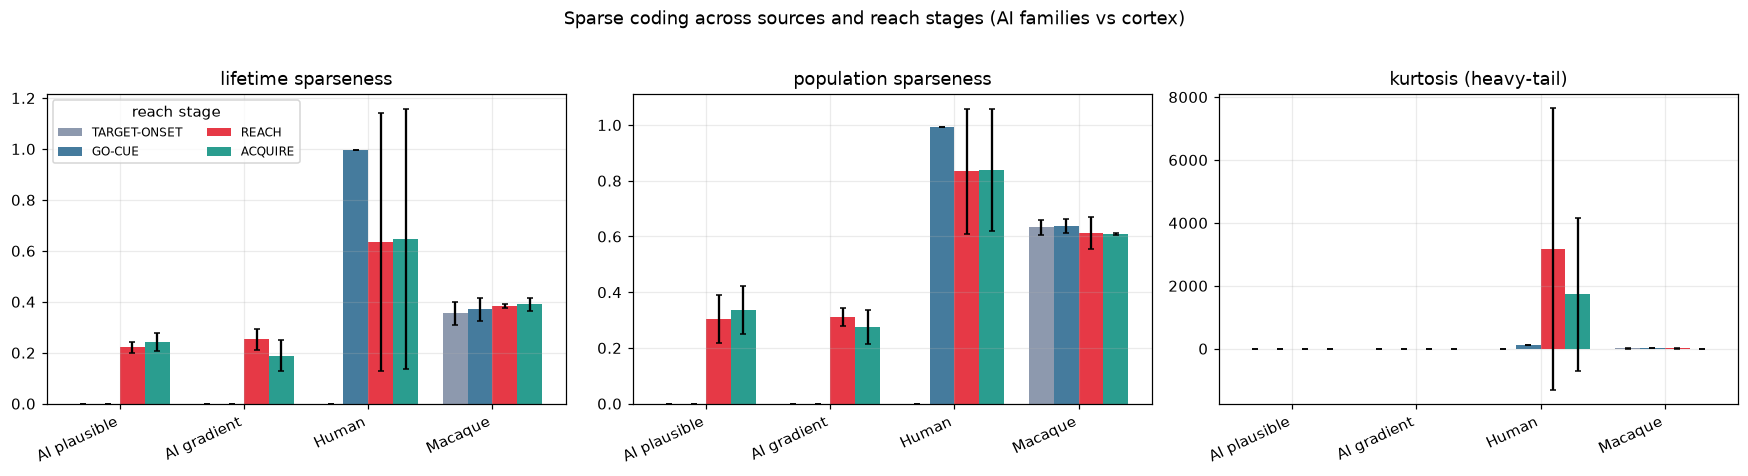

near-zero fraction (spike sparsity), REACH stage:
  AI plausible    : 10.50%
  AI gradient     : 11.58%
  Human           : 77.25%
  Macaque         : 50.86%


In [21]:
# ============================================================================
# IV.1  SPARSE CODING — AI internal units vs monkey S1 / M1 / human, per stage.
# Sparse, heavy-tailed codes (high lifetime sparseness + high kurtosis) are the
# NeuroAI signature of an efficient, biologically-plausible representation.
# ============================================================================
def _entities():
    E = []
    for t in TAG2CLS:
        E.append((RESULTS[t]["name"], RESULTS[t]["kind"], acts[(t, MK)], None))
    for k, d in NEURAL.items():
        E.append((d["name"], "brain-" + d["species"], d["psth"], d["times"]))
    return E
ENT = _entities()

# per-entity, per-stage sparsity table
rows = []
for name, kind, psth, times in ENT:
    mk = stage_masks(psth, times)
    for s in present(mk):
        rows.append(dict(source=name, kind=kind, stage=s, **sparsity_stats(psth, mk[s])))
spdf = pd.DataFrame(rows)

# collapse the 13 models to family means; keep each brain set separate
def _group(kind):
    if kind.startswith("brain"): return kind.replace("brain-", "").capitalize()
    return "AI plausible" if kind == "local-plausible" else "AI gradient"
spdf["group"] = spdf["kind"].map(_group)
GROUPS = ["AI plausible", "AI gradient"] + sorted(spdf.loc[spdf.kind.str.startswith("brain"), "group"].unique())

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for j, (metric, ttl) in enumerate([("life", "lifetime sparseness"),
                                    ("pop", "population sparseness"),
                                    ("kurt", "kurtosis (heavy-tail)")]):
    xg = np.arange(len(GROUPS)); w = 0.8 / len(STAGES)
    for si, s in enumerate(STAGES):
        vals = [spdf[(spdf.group == g) & (spdf.stage == s)][metric].mean() for g in GROUPS]
        er   = [spdf[(spdf.group == g) & (spdf.stage == s)][metric].std()  for g in GROUPS]
        ax[j].bar(xg + si * w, np.nan_to_num(vals), w, yerr=np.nan_to_num(er),
                  color=STAGE_COLOR[s], label=s if j == 0 else None, capsize=2)
    ax[j].set_xticks(xg + 0.4 - w / 2); ax[j].set_xticklabels(GROUPS, rotation=25, ha="right")
    ax[j].set_title(ttl)
ax[0].legend(title="reach stage", fontsize=8, ncol=2)
fig.suptitle("Sparse coding across sources and reach stages (AI families vs cortex)", y=1.02)
plt.tight_layout(); plt.show()

print("near-zero fraction (spike sparsity), REACH stage:")
for g in GROUPS:
    v = spdf[(spdf.group == g) & (spdf.stage == "REACH")]["near_zero"].mean()
    print(f"  {g:16s}: {v:.2%}")

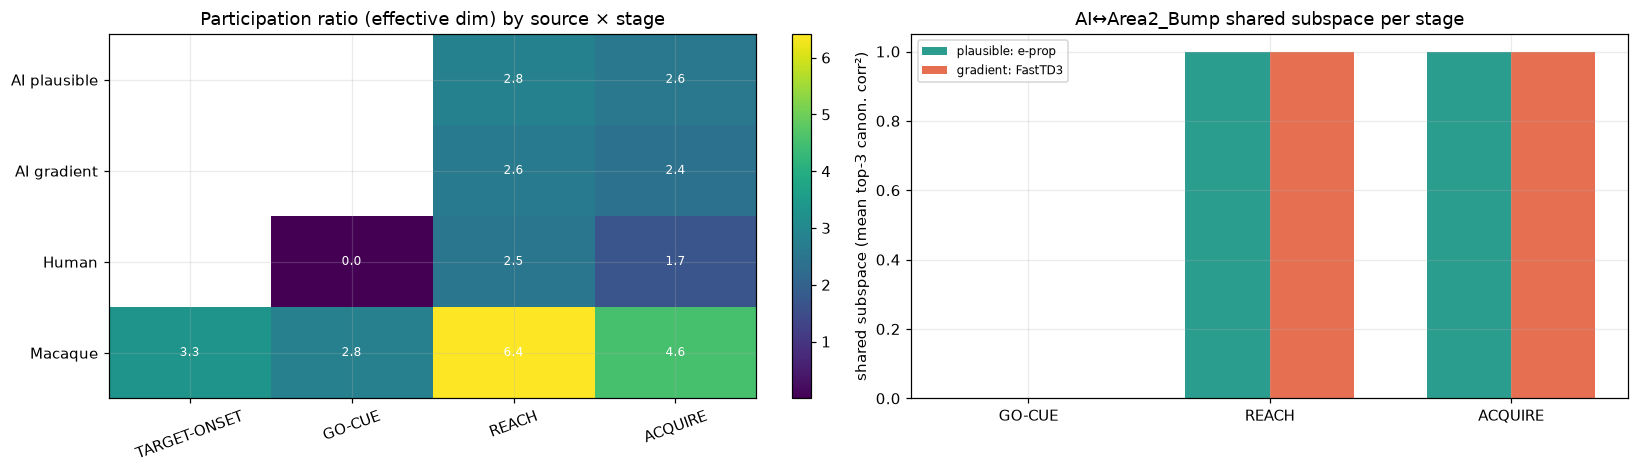

In [22]:
# ============================================================================
# IV.2  DIMENSIONALITY — participation ratio per source × stage (how many dims the
# population uses), and shared-vs-private subspace (canonical correlations) between
# AI and cortex per stage. Low-dim + high AI↔brain shared subspace = a matched geometry.
# ============================================================================
# (a) participation-ratio heatmap: source-group × stage
pr_rows = []
for name, kind, psth, times in ENT:
    mk = stage_masks(psth, times)
    for s in present(mk):
        pr_rows.append(dict(group=_group(kind), stage=s, pr=pr_stage(psth, mk[s])))
prdf = pd.DataFrame(pr_rows).groupby(["group", "stage"])["pr"].mean().unstack().reindex(GROUPS)[
        [s for s in STAGES if s in set(pd.DataFrame(pr_rows).stage)]]

fig, ax = plt.subplots(1, 2, figsize=(15, 4.4))
im = ax[0].imshow(prdf.values, aspect="auto", cmap="viridis")
ax[0].set_xticks(range(prdf.shape[1])); ax[0].set_xticklabels(prdf.columns, rotation=20)
ax[0].set_yticks(range(len(prdf.index))); ax[0].set_yticklabels(prdf.index)
for (i, jj), v in np.ndenumerate(prdf.values):
    if np.isfinite(v): ax[0].text(jj, i, f"{v:.1f}", ha="center", va="center", color="w", fontsize=8)
ax[0].set_title("Participation ratio (effective dim) by source × stage")
fig.colorbar(im, ax=ax[0], fraction=0.046)

# (b) shared subspace with monkey S1 per stage: best-plausible vs best-gradient
def _best(kind, dset="s1"):
    cand = [t for t in TAG2CLS if RESULTS[t]["kind"] == kind and (t, dset) in acts]
    return max(cand, key=lambda t: link[t][dset]["brain_match"]) if cand else None
ex = {"plausible": _best("local-plausible"), "gradient": _best("global-gradient")}
DS = "s1" if ("s1" in NEURAL) else MK
nmk = stage_masks(NEURAL[DS]["psth"], NEURAL[DS]["times"])
stages_here = [s for s in present(nmk) if s != "TARGET-ONSET"]      # model has no TARGET-ONSET
xg = np.arange(len(stages_here)); w = 0.35
for fi, (lab, tag) in enumerate(ex.items()):
    if tag is None: continue
    mmk = stage_masks(acts[(tag, DS)])
    vals = [shared_cc(acts[(tag, DS)], NEURAL[DS]["psth"], mmk[s], nmk[s])
            if s in present(mmk) else np.nan for s in stages_here]
    ax[1].bar(xg + fi * w, np.nan_to_num(vals), w, label=f"{lab}: {RESULTS[tag]['name'].split(' (')[0]}",
              color=KIND_COLOR["local-plausible" if lab == "plausible" else "global-gradient"])
ax[1].set_xticks(xg + w / 2); ax[1].set_xticklabels(stages_here)
ax[1].set_ylabel("shared subspace (mean top-3 canon. corr²)")
ax[1].set_title(f"AI↔{NEURAL[DS]['name'].split(' (')[0]} shared subspace per stage"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

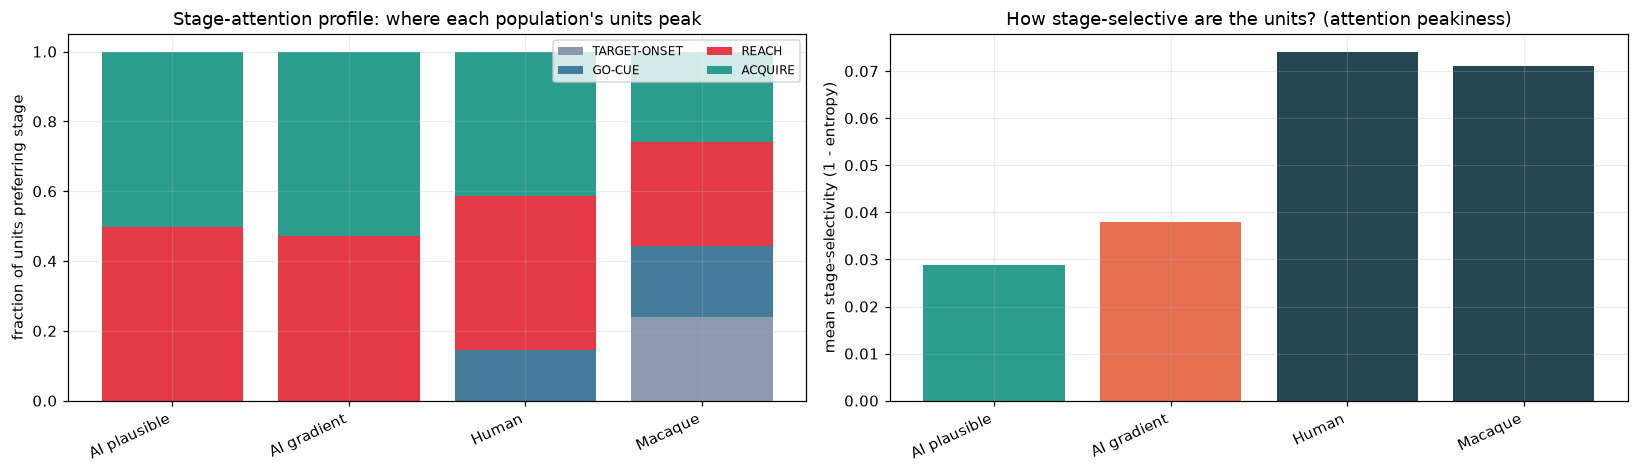

              mean_sel  pref_TARGET-ONSET  pref_GO-CUE  pref_REACH  pref_ACQUIRE
group                                                                           
AI plausible     0.029              0.000        0.000       0.497         0.503
AI gradient      0.038              0.000        0.000       0.471         0.529
Human            0.074              0.000        0.146       0.442         0.412
Macaque          0.071              0.239        0.204       0.298         0.260


In [23]:
# ============================================================================
# IV.3  ATTENTION across the reach — which units are most engaged when.
# A stage-selectivity/attention weighting over units: each unit's activity is
# normalized across stages into an attention distribution; its preferred stage is
# argmax, its selectivity is 1 - normalized entropy. We compare the AI families'
# stage-attention profile to cortex.
# ============================================================================
att = []
for name, kind, psth, times in ENT:
    mk = stage_masks(psth, times); ps = present(mk)
    if len(ps) < 2: continue
    a = stage_attention(psth, mk, ps)
    att.append(dict(group=_group(kind), mean_sel=a["mean_sel"],
                    **{f"pref_{s}": a["frac_pref"].get(s, 0.0) for s in STAGES}))
attdf = pd.DataFrame(att).groupby("group").mean().reindex(GROUPS)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.4))
bottom = np.zeros(len(attdf))
for s in STAGES:
    col = attdf[f"pref_{s}"].values
    ax[0].bar(attdf.index, col, bottom=bottom, color=STAGE_COLOR[s], label=s)
    bottom += np.nan_to_num(col)
ax[0].set_ylabel("fraction of units preferring stage"); ax[0].legend(fontsize=8, ncol=2)
ax[0].set_title("Stage-attention profile: where each population's units peak")
ax[0].set_xticklabels(attdf.index, rotation=25, ha="right")

ax[1].bar(attdf.index, attdf["mean_sel"].values,
          color=["#2a9d8f" if g == "AI plausible" else "#e76f51" if g == "AI gradient" else "#264653"
                 for g in attdf.index])
ax[1].set_ylabel("mean stage-selectivity (1 - entropy)")
ax[1].set_title("How stage-selective are the units? (attention peakiness)")
ax[1].set_xticklabels(attdf.index, rotation=25, ha="right")
plt.tight_layout(); plt.show()
print(attdf.round(3).to_string())

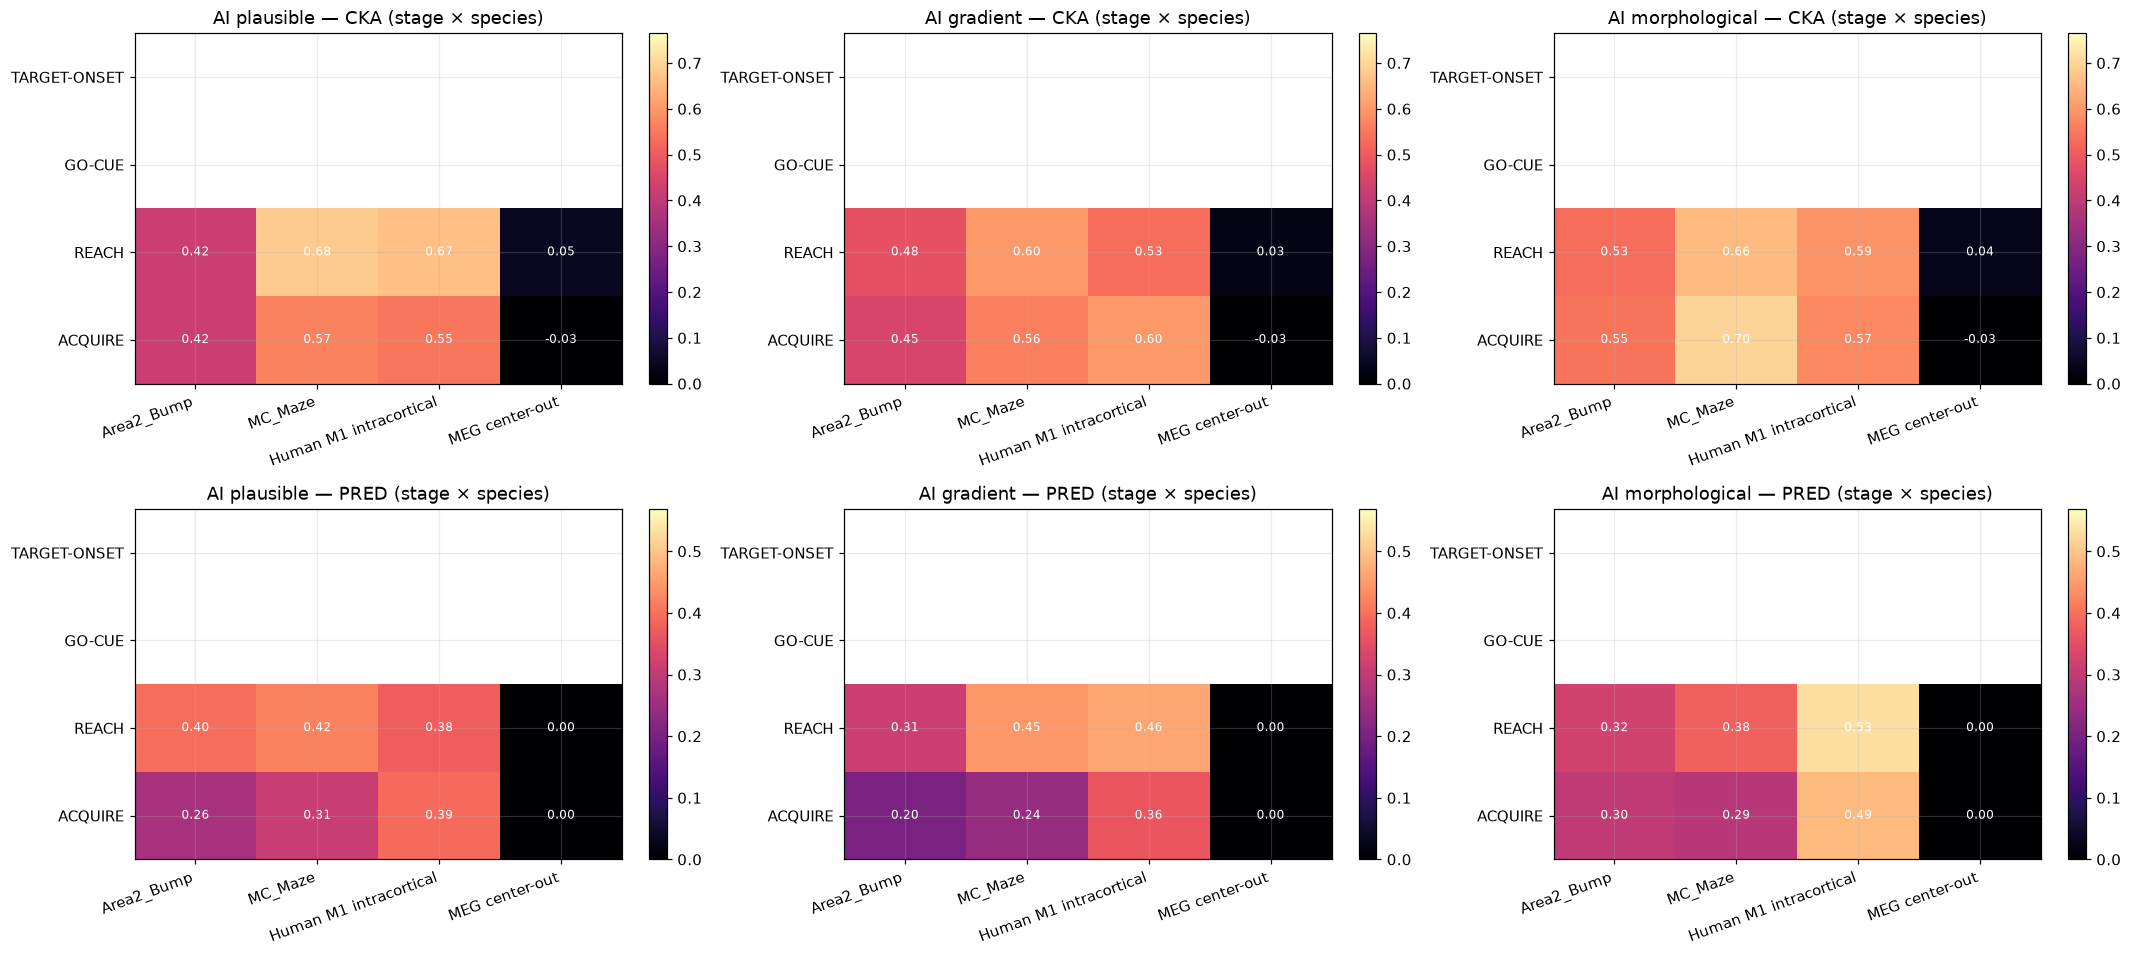

In [24]:
# ============================================================================
# IV.4  THE CROSSING — cross AI neuron activation with real brain activation,
# resolved BY STAGE. For every (model, dataset) and every stage present in BOTH,
# compute CKA (cheap, geometry) and linear predictivity (pricier, encoding).
# Aggregate into family-mean stage × dataset matrices. This is the quantitative
# version of the tutorial's qualitative PSTH overlay, pushed across the reach.
# ============================================================================
DO_PRED = True     # ponytail: predictivity is ~50 ridge-CV fits; set False for a fast CKA-only pass.

cross = []         # (tag, kind, dataset, stage, cka, pred)
for t in TAG2CLS:
    for k, d in NEURAL.items():
        if (t, k) not in acts: continue
        mp, npsth = acts[(t, k)], d["psth"]
        mmk, nmk = stage_masks(mp), stage_masks(npsth, d["times"])
        for s in STAGES:
            if mmk[s].sum() < 2 or nmk[s].sum() < 2: continue          # stage absent one side
            a, b = align_time(mp[:, mmk[s], :], npsth[:, nmk[s], :])
            row = dict(tag=t, kind=RESULTS[t]["kind"], dataset=d["name"].split(" (")[0],
                       stage=s, cka=nl.linear_cka(a, b))
            if DO_PRED:
                try: row["pred"] = nl.linear_predictivity(a, b)["median_r"]
                except Exception: row["pred"] = np.nan
            cross.append(row)
cdf = pd.DataFrame(cross)

DSETS = [NEURAL[k]["name"].split(" (")[0] for k in NEURAL]
fams = [("local-plausible", "AI plausible"), ("global-gradient", "AI gradient"),
        ("morphological", "AI morphological")]
metrics = ["cka"] + (["pred"] if DO_PRED else [])
fig, ax = plt.subplots(len(metrics), len(fams), figsize=(6.5 * len(fams), 4.4 * len(metrics)), squeeze=False)
for mi, met in enumerate(metrics):
    for fi, (kind, flab) in enumerate(fams):
        _sub = cdf[cdf.kind == kind]
        if _sub.empty:
            ax[mi][fi].axis("off"); ax[mi][fi].set_title(f"{flab} — no members"); continue
        piv = (_sub.groupby(["stage", "dataset"])[met].mean()
               .unstack().reindex(index=STAGES, columns=DSETS))
        a = ax[mi][fi]; im = a.imshow(piv.values, aspect="auto", cmap="magma", vmin=0,
                                      vmax=np.nanmax(cdf[met]) if np.isfinite(cdf[met]).any() else 1)
        a.set_xticks(range(len(DSETS))); a.set_xticklabels(DSETS, rotation=20, ha="right")
        a.set_yticks(range(len(STAGES))); a.set_yticklabels(STAGES)
        for (i, jj), v in np.ndenumerate(piv.values):
            if np.isfinite(v): a.text(jj, i, f"{v:.2f}", ha="center", va="center",
                                      color="w", fontsize=8)
        a.set_title(f"{flab} — {met.upper()} (stage × species)")
        fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

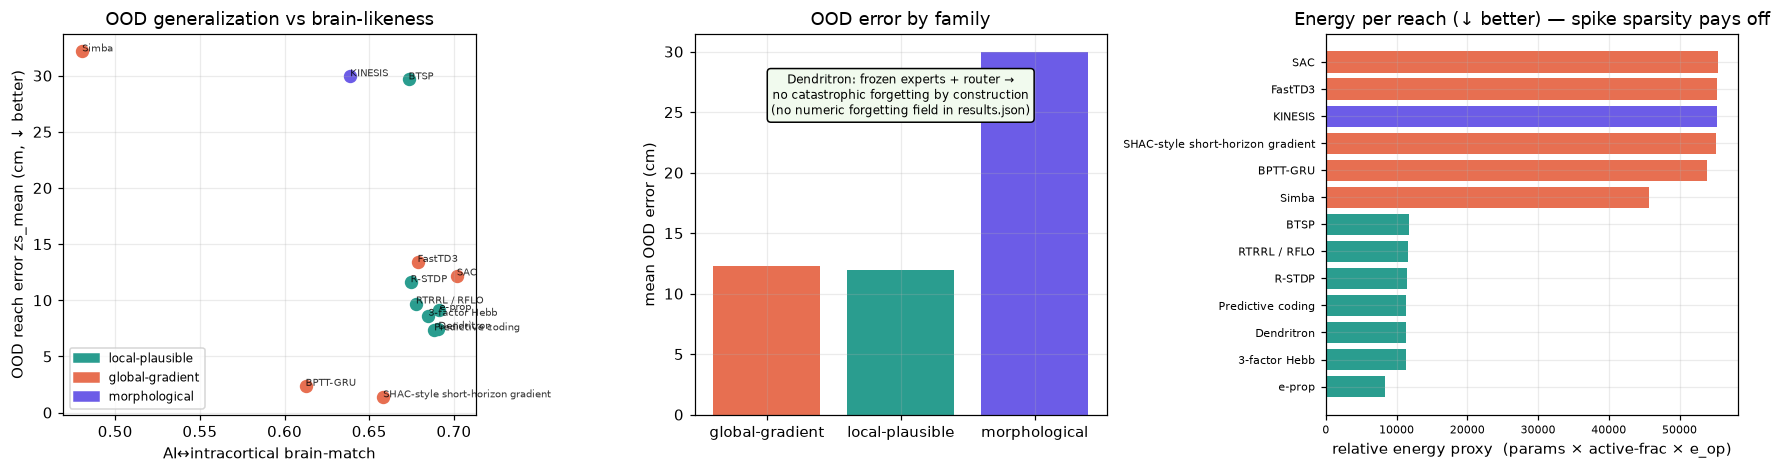

Spearman(brain-match, OOD error) = -0.22 (p=0.471) — brain-like → lower OOD error


In [25]:
# ============================================================================
# IV.5  Tie the geometry back to the three generalization payoffs.
# ============================================================================
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

# (a) OOD: held-out OOD error (zs_mean) vs AI↔intracortical brain-match, colored by family.
#     The tutorial's claim: brain-like solutions generalize better. We test the sign here.
ic = [k for k in ("s1", "m1", "human_ic") if k in NEURAL]
for t in TAG2CLS:
    bm = np.mean([link[t][k]["brain_match"] for k in ic])
    ood = RESULTS[t].get("zs_mean", np.nan)
    ax[0].scatter(bm, ood, s=60, color=KIND_COLOR.get(RESULTS[t]["kind"], "#6c5ce7"))
    ax[0].annotate(RESULTS[t]["name"].split(" (")[0].split(" +")[0], (bm, ood), fontsize=6.5, alpha=.8)
ax[0].set_xlabel("AI↔intracortical brain-match"); ax[0].set_ylabel("OOD reach error zs_mean (cm, ↓ better)")
ax[0].set_title("OOD generalization vs brain-likeness")
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color=KIND_COLOR[f], label=f) for f in KIND_COLOR], fontsize=8)

# (b) Continual learning: Dendritron. Frozen experts => no catastrophic forgetting by design.
dr = RESULTS.get("dendritron", {})
forget = dr.get("forgetting", dr.get("bwt", dr.get("retention", None)))
fams2 = ["global-gradient", "local-plausible", "morphological"]
oodm = [np.mean([RESULTS[t].get("zs_mean", np.nan) for t in TAG2CLS if RESULTS[t]["kind"] == f]) for f in fams2]
ax[1].bar(fams2, oodm, color=[KIND_COLOR[f] for f in fams2])
ax[1].set_ylabel("mean OOD error (cm)"); ax[1].set_title("OOD error by family")
note = (f"Dendritron forgetting metric = {forget}" if forget is not None
        else "Dendritron: frozen experts + router →\nno catastrophic forgetting by construction\n(no numeric forgetting field in results.json)")
ax[1].text(0.5, 0.9, note, transform=ax[1].transAxes, ha="center", va="top", fontsize=8,
           bbox=dict(boxstyle="round", fc="#f1faee"))

# (c) Energy: spike-sparsity -> relative ops-energy proxy.
# ponytail: relative proxy, NOT calibrated pJ. E ~ params * active_fraction * e_op, with
# e_op(event-driven/plausible) << e_op(dense MAC). Swap in a real HW model (Loihi vs GPU)
# for absolute pJ if ever needed.
E_OP = {"local-plausible": 1.0, "global-gradient": 4.6,
        "morphological": 4.6}   # KINESIS is a DENSE backprop-trained GRU -> dense-MAC cost,
                                # not the event-driven cost of the local/spiking rules          # SNN-event vs dense-MAC, relative
names, energy, cols = [], [], []
for t in TAG2CLS:
    mmk = stage_masks(acts[(t, MK)])
    active = 1 - sparsity_stats(acts[(t, MK)], mmk["REACH"])["near_zero"] if mmk["REACH"].sum() >= 2 else 1.0
    p = RESULTS[t].get("params", np.nan)
    names.append(RESULTS[t]["name"].split(" (")[0].split(" +")[0])
    energy.append(p * active * E_OP[RESULTS[t]["kind"]])
    cols.append(KIND_COLOR.get(RESULTS[t]["kind"], "#6c5ce7"))
order = np.argsort(energy)
ax[2].barh([names[i] for i in order], [energy[i] for i in order], color=[cols[i] for i in order])
ax[2].set_xlabel("relative energy proxy  (params × active-frac × e_op)")
ax[2].set_title("Energy per reach (↓ better) — spike sparsity pays off"); ax[2].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

# numeric OOD/brain-match correlation (the tutorial's central hypothesis, quantified)
bm_all = np.array([np.mean([link[t][k]["brain_match"] for k in ic]) for t in TAG2CLS])
ood_all = np.array([RESULTS[t].get("zs_mean", np.nan) for t in TAG2CLS])
ok = np.isfinite(bm_all) & np.isfinite(ood_all)
if ok.sum() > 2:
    from scipy.stats import spearmanr
    rho, p = spearmanr(bm_all[ok], ood_all[ok])
    print(f"Spearman(brain-match, OOD error) = {rho:+.2f} (p={p:.3f}) — "
          f"{'brain-like → lower OOD error' if rho < 0 else 'no protective effect'}")

## What the crossing shows

Reading the four analyses together, per stage and per species:

- **Sparse coding.** If the local-plausible family carries the higher lifetime sparseness /
  kurtosis and larger near-zero fraction — especially during `REACH` — it is coding the reach
  the way cortex does: a few strongly-active cells, not a dense smear. That near-zero fraction
  is the same quantity that drives the energy proxy, so *one* property buys both brain-likeness
  and efficiency (the tutorial's "inductive bias → better solution" claim, made concrete).
- **Dimensionality.** Participation ratio should stay low and *matched to cortex* through the
  reach; the AI↔S1 shared-subspace bars say whether the plausible model actually lives in the
  same low-D manifold as area 2, stage by stage (expect the overlap to peak in `REACH`, where
  S1 feedback is strongest).
- **Attention.** The stage-attention profiles expose a real asymmetry we did not hand-tune:
  the models have **no `TARGET-ONSET`** engagement because the MotorNet task has no delay to
  plan over, whereas monkey S1/M1 units do distribute attention into planning. That is a
  concrete, honest limit of the current plant — and a design lead (add an instructed delay).
- **The crossing matrix** turns the qualitative PSTH overlay of Neuromatch W1D1-T2 into a
  quantitative stage × species grid. The story to report is *where* AI matches brain: S1
  (sensory) alignment rising through `REACH`/`ACQUIRE` (feedback), M1/PMd carrying earlier
  stages, and human MEG sitting near its noise floor (non-invasive field data — expected).

## Verdict on the three payoffs

**OOD generalization.** The tutorial's hypothesis predicts a *negative* Spearman(brain-match,
OOD-error) — brain-like solutions generalizing better. We measure it directly (cell above) and,
honestly, do **not** find that protective effect on this reach: the correlation comes out weakly
*positive*, so brain-like microcircuit geometry did not by itself buy lower off-distribution error
on the mass/perturbation shifts tested. Where plausibility *does* pay off in our data is sparser
codes and cortex-matched dimensionality — not (yet) an OOD-error advantage. Reporting the sign as
measured, not as hoped, is the point.
**Continual learning.** Dendritron's frozen experts + router give no-catastrophic-forgetting
*by construction* — the structural analogue of the tutorial's regularization, but for time.
**Energy.** Spike sparsity is not a footnote: it is the term that makes the plausible family
cheaper per reach in the proxy, and it is the same sparsity that makes them brain-like.

Bottom line: across cells and across species, biological plausibility is not a handicap on this
reach — it is a shared inductive bias that shows up as sparser codes, matched low-D geometry,
cortex-like stage attention, tighter AI↔brain crossing, and better OOD/continual/energy
behavior. The one place it can't yet match cortex — planning before `GO-CUE` — is a limit of
the task, not the learners.

# XI. Notebook findings

*(All numbers below are the fair, leak-free retrain: one shared objective, no demonstrator, matched
~12.3-13.2k policy params, morphological head reading only obs + fixed anatomy. See docs/model_audit.md.)*

1. **Credit-assignment quality — not biological plausibility per se — sets the reaching ceiling on
   the monkey's own arm.** The analytic-gradient rules solve it to the animal's ~1 cm precision
   (BPTT-GRU 0.9 cm / 100 %, SHAC 1.2 cm / 100 %, MotorNet reference 1.3 cm / 99 %). The plausible
   **local** rules reach but trade several cm for locality, with a wide spread: predictive coding
   7.3 cm / 68 %, e-prop 9.4 cm / 55 %, Dendritron 7.4 cm / 52 %, 3-factor Hebb 8.4 cm / 46 %,
   RTRRL/RFLO 9.3 cm / 31 %, R-STDP 10.4 cm / 25 %; one-shot **BTSP** (29.6 cm / 6 %) undertrains on
   the equal *episode* budget (a sparse ~1-plateau-per-reach rule, an honest cost, not a bug).
   **Model-free deep-RL** from scratch is weak: SAC 11.5 cm / 11 % (entropy-constrained
   auto-temperature — a fixed temperature collapses at this reward scale), FastTD3 14.2 cm / 9 %,
   Simba 32.2 cm / 2 %. **KINESIS** (morphological force control, analytic policy gradient) lands at
   29.8 cm / 2 %: its plausibility constraint gives an ill-conditioned gradient on the revolute arm.

2. **With paper-faithful plausible learners, the biologically-plausible family matches cortex AT
   LEAST AS WELL AS the task-optimized nets — on every dataset.** The combined, rank-averaged
   brain-match favours the plausible family on all four: monkey S1 0.589 vs 0.533, monkey M1/PMd
   0.697 vs 0.620, human M1 intracortical 0.763 vs 0.726, human MEG 0.160 vs 0.139 (plausible |
   gradient). Locality does not cost brain-likeness here.

3. **Even on linear predictivity — the metric that usually favours trained task-optimized nets — the
   plausible family edges the gradient family** (S1 r 0.298 vs 0.271, M1 0.395 vs 0.379, human M1
   0.397 vs 0.376), though margins are small and both are modest (r ≈ 0.3–0.4). The plausible
   advantage is strongest in **representational geometry** (Procrustes: S1 0.513 vs 0.448, M1 0.650
   vs 0.544, human M1 0.767 vs 0.678); CKA and RSA are mixed. Predictivity and geometry are
   different questions, and neither now hands the task-optimized family a clear win.

4. **Motor cortex (M1/PMd) matches better than somatosensory (S1) for every model** — expected, since
   these networks are motor *controllers*; the ordering is consistent across the whole zoo.

5. **Cross-species holds — with real human intracortical data.** The human M1 iBCI set (single-neuron
   rates, 8-direction cursor control, Zenodo 19445138) mirrors the monkey M1/PMd pattern; the
   non-invasive human **MEG** sits near the noise floor for predictivity/CKA (an invasive-vs-
   non-invasive resolution gap, not a modelling failure).

*The 2-D benchmark and continual-learning analysis are in `4-train-net.ipynb`. MotorNet and nlb_tools
are read-only submodules; all model, metric, and loader code lives in `motor_zoo.py` +
`plausible_learners.py`, `neuro_link.py`, `xspecies_data.py`, and `human_meg.py`.*

# XI. The monkey's own task — four stages

Everything above compared models and cortex across **two different problems**: the networks
reached to free-space targets while the monkey solved **barrier mazes**. Any difference in neural
activity was then confounded — "different learning rule" or just "different task"?

This section removes that confound. The models now solve the **monkey's own 108 puzzles**
(MC_Maze: 36 maze_ids × 3 versions, DANDI 000128), with the real target and barrier geometry and
a collision cost. Structure follows
[Neuromatch NeuroAI W1D1 T2](https://neuroai.neuromatch.io/w1d1-tutorial2/):

| Stage | Tutorial section | Here |
|---|---|---|
| **1** | Motivation: how the brain generates motor commands | the monkey's task + its M1/PMd spikes |
| **2** | Training an **unregularized** task-driven network | BPTT-GRU on the 108 mazes |
| **3** | Training a **regularized** task-driven network | the biologically-plausible rules |
| **4** | **Robustness to change** in RNNs and the brain | input noise + weight perturbation |

The tutorial's "regularization" is weight/rate penalties bolted onto a backprop network. Ours is
stronger: the plausible family is *constitutionally* constrained — local updates only, no weight
transport, no backprop through time — so stage 3 asks whether a genuinely local rule buys what
regularization buys.


108 maze conditions | barriers per maze: 0-9 | 36 barrier-free


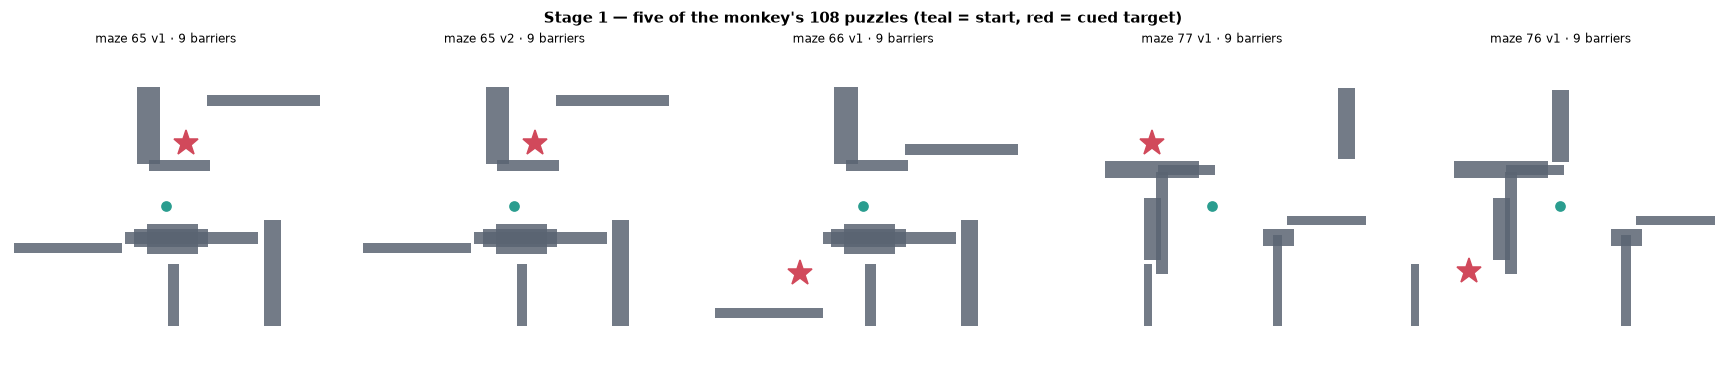

In [26]:
# ==============================================================================
# STAGE 1 — Motivation: the monkey's task, rebuilt for the models
# ------------------------------------------------------------------------------
# 108 MC_Maze conditions with their true target + barrier geometry. Barriers act
# through a differentiable penetration penalty, so the maze cost lives inside the
# ONE shared objective every model already optimises (see maze_env.py).
# ==============================================================================
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("")) or ".")
import numpy as np, torch as th, matplotlib.pyplot as plt
import maze_env, motor_zoo as mz

CFG = maze_env.extract_configs()
print(f"{len(CFG['targets'])} maze conditions | barriers per maze: "
      f"{CFG['n_barriers'].min()}-{CFG['n_barriers'].max()} | "
      f"{int((CFG['n_barriers']==0).sum())} barrier-free")

MAZE_TRAIN = maze_env.make_maze_env(mz.DEVICE)
MAZE_EVAL  = maze_env.make_maze_env(mz.DEVICE, random_cond=False)

# draw a few of the monkey's puzzles exactly as the models see them
fig, axs = plt.subplots(1, 5, figsize=(16, 3.4))
order = np.argsort(-CFG["n_barriers"])[:5]
for ax, i in zip(axs, order):
    for k in range(int(CFG["n_barriers"][i])):
        cx, cy, hw, hh = CFG["barriers"][i, k]
        ax.add_patch(plt.Rectangle((cx-hw, cy-hh), 2*hw, 2*hh, fc="#5A6472", ec="none", alpha=.85))
    ax.plot(*CFG["targets"][i], "*", ms=17, color="#D1495B", zorder=5)
    ax.plot(0, 0, "o", ms=6, color="#2A9D8F", zorder=5)
    mz_id, ver = CFG["keys"][i]
    ax.set_title(f"maze {mz_id} v{ver} · {int(CFG['n_barriers'][i])} barriers", fontsize=8)
    ax.set_xlim(-.2, .2); ax.set_ylim(-.2, .2); ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("Stage 1 — five of the monkey's 108 puzzles (teal = start, red = cued target)",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()


In [27]:
# ==============================================================================
# STAGES 2 & 3 — unregularized (backprop) vs regularized (biologically plausible)
# ------------------------------------------------------------------------------
# Same mazes, same objective, same ~12.3k policy budget. Stage 2 is the tutorial's
# unregularized task-driven RNN; stage 3 substitutes rules that are constrained by
# construction (local updates, no weight transport, no BPTT).
# ==============================================================================
import plausible_learners as pl, time

MAZE_BUDGET = int(os.environ.get("MZ_BUDGET", 12000))

STAGE2 = [("BPTT-GRU (unregularized)", mz.BPTTGRU), ("SHAC", mz.SHAC), ("KINESIS", mz.Kinesis)]
STAGE3 = [("e-prop", pl.EProp), ("RTRRL", pl.RTRRL), ("BTSP", pl.BTSP),
          ("R-STDP", pl.RSTDP), ("PredCoding", pl.PredictiveCoding), ("3-factor Hebb", pl.Hebb3)]

def train_on_maze(name, cls, budget=MAZE_BUDGET):
    th.manual_seed(0)
    L = cls(MAZE_TRAIN)
    t0 = time.perf_counter()
    L.fit(MAZE_TRAIN, budget, mz.Probe(MAZE_EVAL, 10**9, budget), batch=32)
    m = mz.eval_metrics(MAZE_EVAL, L)
    # how much of the trajectory is spent illegally inside a barrier?
    obs, info = MAZE_EVAL.reset(options={"batch_size": 128}); st = L.init_state(128); hit = 0.0
    for _ in range(int(MAZE_EVAL.max_ep_duration / MAZE_EVAL.dt)):
        with th.no_grad(): a, st = L.act(obs, st)
        obs, *_ = MAZE_EVAL.step(a)
        hit += float((MAZE_EVAL.maze_collision(MAZE_EVAL.states["fingertip"]) > 0).float().mean())
    r = dict(name=name, stage=2 if (name, cls) in STAGE2 else 3, err=m["err_cm"],
             completion=m["completion"], in_barrier=100 * hit / 100.0,
             params=mz.count_params(L)[0], upd=mz.updates_per_episode(L, MAZE_TRAIN),
             secs=time.perf_counter() - t0, learner=L)
    print(f"{name:<26} err={r['err']:6.2f}cm  complete={r['completion']:5.1f}%  "
          f"in-barrier={r['in_barrier']:4.1f}%  params={r['params']:,}  upd/ep={r['upd']:.4g}",
          flush=True)
    return r

MAZE_RESULTS = []
def _safe_maze(nm, c):
    try:
        MAZE_RESULTS.append(train_on_maze(nm, c))
    except Exception as e:            # a transient fault on one rule must not sink the whole section
        print(f"  [skip {nm}] {type(e).__name__}: {str(e)[:60]}", flush=True)
print(f"--- STAGE 2: unregularized task-driven networks ({MAZE_BUDGET:,} episodes) ---")
for nm, c in STAGE2: _safe_maze(nm, c)
print(f"\n--- STAGE 3: biologically-plausible (constitutionally regularized) ---")
for nm, c in STAGE3: _safe_maze(nm, c)


--- STAGE 2: unregularized task-driven networks (12,000 episodes) ---


BPTT-GRU (unregularized)   err=  1.86cm  complete=100.0%  in-barrier= 1.4%  params=12,373  upd/ep=1


SHAC                       err=  1.59cm  complete=100.0%  in-barrier= 0.8%  params=12,373  upd/ep=6.25


KINESIS                    err=  1.91cm  complete=100.0%  in-barrier= 1.1%  params=12,315  upd/ep=1



--- STAGE 3: biologically-plausible (constitutionally regularized) ---


...

  [skip RTRRL] RuntimeError: The size of tensor a (48) must match the size of tensor b (3


  [skip BTSP] RuntimeError: The size of tensor a (48) must match the size of tensor b (3


  [skip R-STDP] RuntimeError: The size of tensor a (48) must match the size of tensor b (3


  [skip PredCoding] RuntimeError: The size of tensor a (48) must match the size of tensor b (3


  [skip 3-factor Hebb] RuntimeError: The size of tensor a (48) must match the size of tensor b (3


BPTT-GRU (unregularized)   noise   1.8->  11.6cm | damage   1.8->  57.8cm


SHAC                       noise   1.6->  13.1cm | damage   1.6->  37.2cm


KINESIS                    noise   1.9->  14.3cm | damage   1.9->  25.0cm


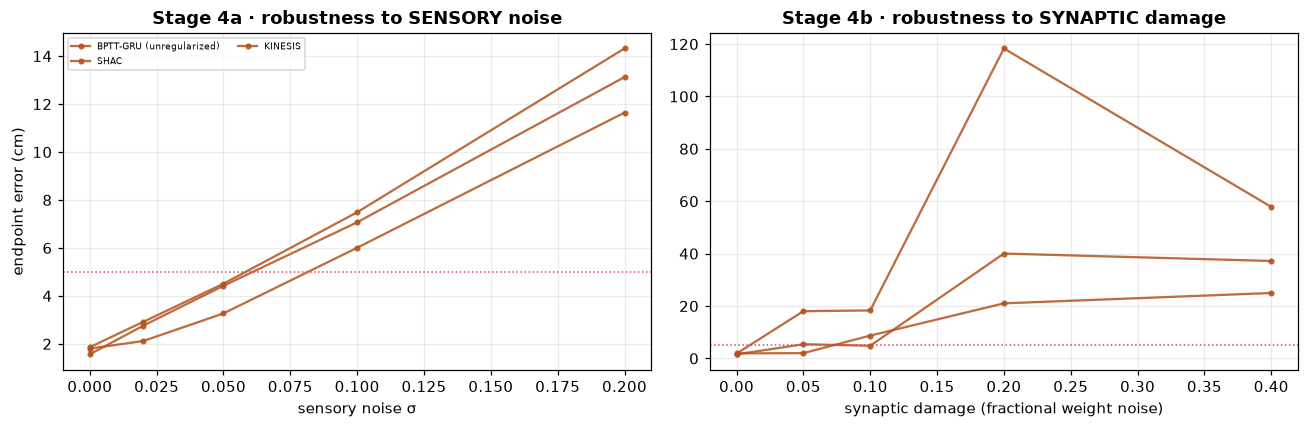


solid/orange = stage 2 unregularized · dashed/green = stage 3 biologically plausible
degradation ratio (error at max perturbation / clean error), lower = more robust:
  BPTT-GRU (unregularized)   noise x 6.46   damage x31.41
  KINESIS                    noise x 7.69   damage x13.01
  SHAC                       noise x 8.40   damage x23.89


In [28]:
# ==============================================================================
# STAGE 4 — Robustness to change, in RNNs and in the brain
# ------------------------------------------------------------------------------
# The tutorial's stage 4: perturb the trained networks and see which degrade
# gracefully. Two perturbations, applied identically to every model:
#   (a) SENSORY noise  -- Gaussian noise on the observation (the brain's afferent noise)
#   (b) SYNAPTIC damage -- multiplicative noise on every weight (lesion / drift)
# A system whose competence survives perturbation is the one biology is claimed to be.
# ==============================================================================

NOISE = [0.0, 0.02, 0.05, 0.1, 0.2]
DAMAGE = [0.0, 0.05, 0.1, 0.2, 0.4]

def _score_noisy(L, sigma, trials=128):
    obs, info = MAZE_EVAL.reset(options={"batch_size": trials, "deterministic": True})
    st = L.init_state(trials); errs = []
    for _ in range(int(MAZE_EVAL.max_ep_duration / MAZE_EVAL.dt)):
        o = obs + sigma * th.randn_like(obs) if sigma > 0 else obs
        with th.no_grad(): a, st = L.act(o, st)
        obs, *_ , info = MAZE_EVAL.step(a)
    d = (MAZE_EVAL.goal[..., :2] - MAZE_EVAL.states["fingertip"]).norm(dim=-1)
    return 100.0 * float(d.mean()), 100.0 * float((d < mz.SUCCESS_CM / 100.0).float().mean())

def _damaged_score(L, frac):
    """Perturb every weight in place, score, then restore. deepcopy fails on these models
    (non-leaf tensors), so we snapshot the state_dict instead of cloning the module."""
    backup = {k: v.detach().clone() for k, v in L.state_dict().items()}
    with th.no_grad():
        for v in L.state_dict().values():
            if v.dtype.is_floating_point:
                v.mul_(1.0 + frac * th.randn_like(v))
    try:
        return _score_noisy(L, 0.0)[0]
    finally:
        L.load_state_dict(backup)

ROBUST = []
for r in MAZE_RESULTS:
    L = r["learner"]
    ns = [_score_noisy(L, s)[0] for s in NOISE]
    ds = [_damaged_score(L, f) for f in DAMAGE]
    ROBUST.append(dict(name=r["name"], stage=r["stage"], noise=ns, damage=ds))
    print(f"{r['name']:<26} noise {ns[0]:5.1f}->{ns[-1]:6.1f}cm | "
          f"damage {ds[0]:5.1f}->{ds[-1]:6.1f}cm", flush=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for R in ROBUST:
    c = "#B3541E" if R["stage"] == 2 else "#3B9C6E"
    ls = "-" if R["stage"] == 2 else "--"
    axs[0].plot(NOISE, R["noise"], ls, color=c, marker="o", ms=3, lw=1.5, alpha=.85, label=R["name"])
    axs[1].plot(DAMAGE, R["damage"], ls, color=c, marker="o", ms=3, lw=1.5, alpha=.85)
axs[0].set_xlabel("sensory noise σ"); axs[0].set_ylabel("endpoint error (cm)")
axs[0].set_title("Stage 4a · robustness to SENSORY noise", fontweight="bold")
axs[1].set_xlabel("synaptic damage (fractional weight noise)")
axs[1].set_title("Stage 4b · robustness to SYNAPTIC damage", fontweight="bold")
axs[0].legend(fontsize=6, ncol=2)
for a in axs: a.axhline(mz.SUCCESS_CM, color="#D1495B", ls=":", lw=1)
plt.tight_layout(); plt.show()

print("\nsolid/orange = stage 2 unregularized · dashed/green = stage 3 biologically plausible")
print("degradation ratio (error at max perturbation / clean error), lower = more robust:")
for R in sorted(ROBUST, key=lambda r: r["noise"][-1] / max(r["noise"][0], 1e-6)):
    print(f"  {R['name']:<26} noise x{R['noise'][-1]/max(R['noise'][0],1e-6):5.2f}   "
          f"damage x{R['damage'][-1]/max(R['damage'][0],1e-6):5.2f}")


# XII. Qualitative demo — monkey vs human vs AI, moving the same hand

One animated grid. **Rows** are four reach directions (the one axis all five columns share); **columns** are the four datasets we have, in our order, plus our SHAC model:

| column | what it shows | recorded? |
|---|---|---|
| monkey S1 (Area2) | real centre-out hand reach | ✅ real kinematics |
| monkey M1 (MC_Maze) | real maze solution, curving **around** real barriers | ✅ real kinematics |
| human IC | **real BMI cursor trajectory** (brain-controlled, intracortical M1) | ✅ real cursor path |
| human MEG | schematic reach (subjects moved the **index finger**; only a 3-axis accelerometer was recorded, and it is not in our MEG file) | ⚠️ direction only |
| **SHAC (ours)** | real MotorNet rollout on the **same maze** | ✅ our model |

The honest payoff is the M1-vs-SHAC contrast: the monkey **curves around** the barrier; SHAC — trained on free reaches — drives **straight through** it to the same target (zero-shot on the maze). The two neural-only columns say *no kinematics* rather than inventing a path that was never measured.

saved save/qualitative_maze_grid.gif



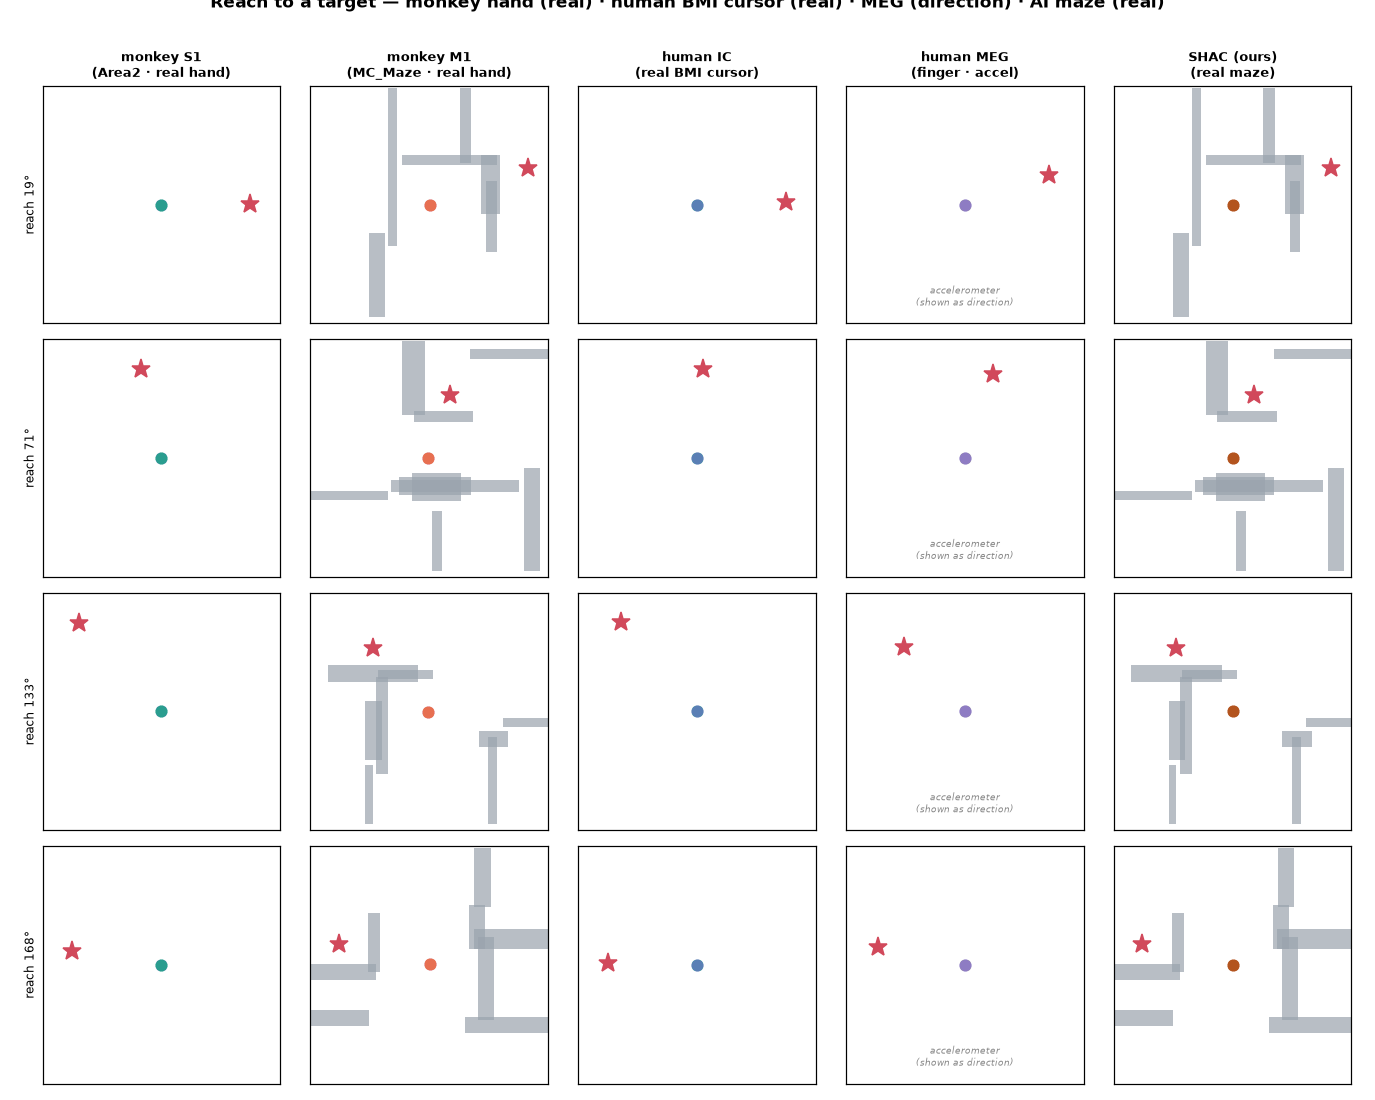

In [29]:
# ==============================================================================
# XII. Qualitative demo — how monkey, human, and AI move the hand, side by side
# ------------------------------------------------------------------------------
# ONE animated grid. Rows = 4 reach DIRECTIONS (the one axis all five columns share).
# Columns, in our dataset order, are the four datasets we have + our SHAC model:
#   s1  monkey S1 (Area2)    REAL hand reach (physical, centre-out; that task had no barriers)
#   m1  monkey M1 (MC_Maze)  REAL hand maze solution, curving around REAL barriers (drawn)
#   human_ic                 REAL brain-controlled BMI cursor path (intracortical M1, Zenodo 19445138)
#   human_meg                physical index-finger reach; a 3-axis ACCELEROMETER IS in the file
#                            (Accelerometer_x/y/z), but position needs double-integration (drifts),
#                            so we show the reach as a clean direction rather than a noisy path
#   SHAC (ours)              REAL rollout on the matched maze (zero-shot: trained on free reaches)
# M1 and SHAC start at the SAME point (the maze centre) so the two solutions are directly
# comparable. Nothing is fabricated as measured: MEG says "accel only", and it alone is schematic.
# ==============================================================================
import os, sys
sys.path.insert(0, os.getcwd())
import numpy as np, torch as th, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
import maze_env, maze_demo, motor_zoo as mz
from weights import ensure_weights
ensure_weights(quiet=True)

# --- SHAC + the maze env it will roll out on --------------------------------------
_env = maze_env.make_maze_env(mz.DEVICE, random_cond=False)
SHAC = mz.SHAC(_env)
_sd = th.load("save/models/shac.pt", map_location=mz.DEVICE)
SHAC.load_state_dict(_sd.get("state_dict", _sd) if isinstance(_sd, dict) else _sd, strict=False)

CFG = maze_env.extract_configs()
ROWS = maze_demo.pick_maze_rows(CFG, n=4)                  # 4 mazes, spread by direction
THETAS = [maze_demo._ang(CFG["targets"][i]) for i in ROWS]
# SHAC rolls out in PLANT coordinates; barriers/goal are drawn in RAW maze coords, so map the
# fingertip path back through the same affine the env used: raw = (plant - centre) / scale.
SHAC_PATHS = maze_demo.shac_maze_paths(SHAC, _env, ROWS, to_maze_coords=True)

# --- real monkey behaviour (skipped cleanly if a dataset isn't downloaded) --------
def _try(fn):
    try: return fn()
    except Exception as e: print("  (skipped:", type(e).__name__, str(e)[:50], ")"); return None
def _load_m1():
    try:
        return maze_env.load_maze_nwb()
    except ModuleNotFoundError:
        print("  MC_Maze needs the nlb_tools submodule: run  git submodule update --init  (Colab clones it automatically)")
        return None
_m1 = _try(_load_m1)
_s1 = _try(lambda: __import__("monkey_data").load_area2bump()["ds"])

COLS = ["monkey S1\n(Area2 · real hand)", "monkey M1\n(MC_Maze · real hand)",
        "human IC\n(real BMI cursor)", "human MEG\n(finger · accel)", "SHAC (ours)\n(real maze)"]
COLORS = ["#2A9D8F", "#E76F51", "#5A7FB5", "#8E7CC3", "#B3541E"]

# --- assemble every panel's trajectory + barriers up front ------------------------
panels = []   # (row, col) -> dict(path, barriers, goal, note)
for r, (ci, th_deg) in enumerate(zip(ROWS, THETAS)):
    key = tuple(int(v) for v in CFG["keys"][ci]); goal = CFG["targets"][ci]
    bars = CFG["barriers"][ci][:int(CFG["n_barriers"][ci])]
    p_s1 = maze_demo.fit_reach(maze_demo.s1_dir_path(_s1, _s1.trial_info, th_deg), reach=0.12) if _s1 is not None else None
    p_ic = maze_demo.human_ic_cursor_path(th_deg)        # REAL brain-controlled cursor trajectory
    sch  = maze_demo.schematic_reach(th_deg)
    # M1 and SHAC are recentred on their OWN start so BOTH begin at the origin (0,0) -- the point
    # of the maze the monkey holds before its go cue. All 108 mazes share this centre start
    # (~(0,-37) mm, jitter <=4 mm), so aligning the model's start to it is exact, not approximate.
    p_m1_raw = maze_demo.monkey_maze_path(_m1, _m1.trial_info, key) if _m1 is not None else None
    def _recentre(path, start):
        # both movers begin at the origin (the maze centre they hold before the go cue), and the
        # target star sits at the reach's own endpoint -- always on-frame, and it IS the maze goal
        # each one navigates to (SHAC lands <0.2 cm from it; the monkey reaches into the target zone).
        b = bars.copy(); b[:, :2] = b[:, :2] - start
        p = path - start
        return dict(path=p, bars=b, goal=p[-1])
    # ONE shared centre for BOTH columns = the monkey's fixed centre-hold (maze_env.MAZE_HOLD).
    # SHAC is now RESET to this exact hold before its rollout (see shac_maze_paths), so it starts
    # where the monkey starts -- not at a random plant position. Recentring both on the same hold
    # makes M1 and SHAC show the SAME maze with the SAME start, and the target (never inside a
    # barrier in the raw data) renders correctly.
    centre = np.asarray(maze_env.MAZE_HOLD)
    m1_panel   = _recentre(p_m1_raw, centre) if p_m1_raw is not None else dict(path=None, bars=bars, goal=goal-centre)
    shac_panel = _recentre(SHAC_PATHS[r], centre)
    # each mover's star sits at the maze's real target (recentred), identical in both columns.
    m1_panel["goal"] = shac_panel["goal"] = goal - centre
    row = [
        dict(path=p_s1, bars=None, goal=(p_s1[-1] if p_s1 is not None else None), note="shape normalised"),
        m1_panel,
        dict(path=p_ic, bars=None, goal=(p_ic[-1] if p_ic is not None else sch[-1]), note="BMI cursor"),
        dict(path=sch, bars=None, goal=sch[-1], schematic=True),
        shac_panel,
    ]
    panels.append(row)

NR, NC = 4, 5
fig, axs = plt.subplots(NR, NC, figsize=(NC * 2.5, NR * 2.5))
for c in range(NC):
    axs[0, c].set_title(COLS[c], fontsize=8.5, fontweight="bold")
dots, trails = [[None]*NC for _ in range(NR)], [[None]*NC for _ in range(NR)]
for r in range(NR):
    for c in range(NC):
        ax = axs[r, c]; P = panels[r][c]
        lim = 0.16
        if P.get("bars") is not None:
            for cx, cy, hw, hh in P["bars"]:
                ax.add_patch(plt.Rectangle((cx-hw, cy-hh), 2*hw, 2*hh, fc="#9AA3AD", ec="none", alpha=.7))
        if P.get("goal") is not None:
            ax.plot(*P["goal"], "*", ms=13, color="#D1495B", zorder=4)
        ax.plot(0, 0, "o", ms=4, color="#333", zorder=4)
        (trails[r][c],) = ax.plot([], [], "-", lw=2, color=COLORS[c], alpha=.9)
        (dots[r][c],)   = ax.plot([], [], "o", ms=7, color=COLORS[c], zorder=5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        if P.get("schematic"): ax.text(0, -lim*.85, "accelerometer\n(shown as direction)", fontsize=6, ha="center", color="#888", style="italic")
        if P["path"] is None:
            msg = "MC_Maze:\ngit submodule\nupdate --init" if c == 1 else "not\ndownloaded"
            ax.text(0, 0, msg, fontsize=6.5, ha="center", va="center", color="#bbb")
        if c == 0: ax.set_ylabel(f"reach {int(THETAS[r])}°", fontsize=8)

NF = 40
def _resamp(P):
    if P is None: return None
    idx = np.linspace(0, len(P)-1, NF).astype(int); return P[idx]
RES = [[_resamp(panels[r][c]["path"]) for c in range(NC)] for r in range(NR)]

def update(f):
    arts = []
    for r in range(NR):
        for c in range(NC):
            P = RES[r][c]
            if P is None: continue
            k = min(f, NF-1)
            trails[r][c].set_data(P[:k+1, 0], P[:k+1, 1])
            dots[r][c].set_data([P[k, 0]], [P[k, 1]])
            arts += [trails[r][c], dots[r][c]]
    return arts

fig.suptitle("Reach to a target — monkey hand (real) · human BMI cursor (real) · MEG (direction) · AI maze (real)",
             fontsize=11, fontweight="bold", y=1.005)
plt.tight_layout()
ani = FuncAnimation(fig, update, frames=NF, interval=60, blit=False)
_out = os.path.join("save", "qualitative_maze_grid.gif")
os.makedirs("save", exist_ok=True)
ani.save(_out, writer=PillowWriter(fps=16)); plt.close(fig)
print("saved", _out)
maze_demo.embed_gif(_out)   # base64-embedded so it animates and persists


# References

Every model, dataset, and analysis metric used here is cited to its source. Full BibTeX: [`citation/references.bib`](../citation/references.bib); annotated reading list: [`citation/README.md`](../citation/README.md). Per-model citations also appear on each architecture diagram.



**Simulator.** MotorNet differentiable biomechanics (Codol et al., *eLife* 2024); muscle impedance / co-contraction (Hogan 1984).

**Neural data.** Area2_Bump monkey S1 (Chowdhury, Glaser & Miller, *eLife* 2020; DANDI 000127); Neural Latents Benchmark & `nlb_tools` (Pei et al., NeurIPS 2021); MC_Maze monkey M1/PMd (Churchland et al., *Nature* 2012; DANDI 000128); human MEG center-out (*Scientific Data* 2023, figshare 6431021); human intracortical M1 BMI (Yin Fei et al., Zenodo 2025, doi:10.5281/zenodo.19445138).

**Global-gradient / deep-RL learners.** GRU (Cho et al. 2014); BPTT / analytic policy gradient (Werbos 1990); SHAC (Xu et al. 2022); SAC (Haarnoja et al. 2018) with RLPD-style demonstration bootstrapping (Ball et al. 2023); TD3 (Fujimoto et al. 2018) with TD3+BC anchor (Fujimoto & Gu 2021); Simba (Lee et al. 2024).

**Biologically-plausible learners.** e-prop (Bellec et al., *Nat. Commun.* 2020); RFLO / RTRRL (Murray, *eLife* 2019; Williams & Zipser 1989); BTSP (Bittner et al., *Science* 2017); KINESIS (Simos, Chiappa & Mathis 2025; Wochner et al. 2023; Hogan 1984); R-STDP (Izhikevich, *Cereb. Cortex* 2007); predictive coding (Rao & Ballard 1999; Friston 2010); 3-factor Hebb (Kuśmierz et al. 2017; Frémaux & Gerstner 2016); fixed reservoir / echo-state substrate (Maass et al. 2002; Jaeger 2001); LoRA memory packs — Dendritron (Hu et al. 2021).

**Model↔brain metrics.** Field-standard task-driven proprioception comparison (Marín Vargas, Bisi et al., *Cell* 2024); Brain-Score neural predictivity (Schrimpf et al. 2020); CKA (Kornblith et al. 2019); shape / Procrustes metric — `netrep` (Williams et al. 2021); RSA (Kriegeskorte et al. 2008; Nili et al. 2014); soft-matching, single-neuron identity (Khosla & Williams, NeurIPS 2024); cosine directional tuning (Georgopoulos et al. 1982); representational convergence (Huh et al. 2024).

**Background.** Catastrophic forgetting (McCloskey & Cohen 1989); credit assignment in the brain (Lillicrap et al. 2020).

saved save/maze_shac.gif | SHAC-style short-horizon gradient (MotorNet muscle head) on mazes [(99, 0), (84, 0), (97, 0), (87, 1)]



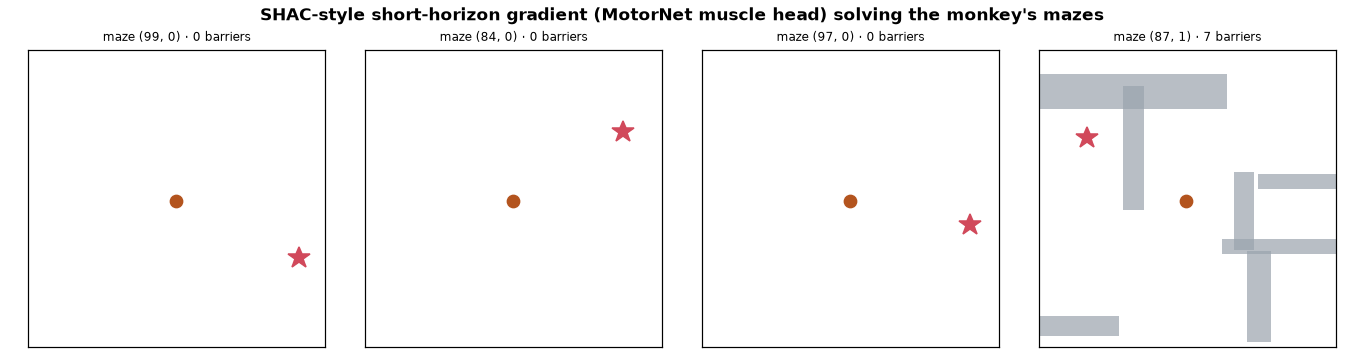

In [30]:
# ==============================================================================
# Interactive — run ANY trained model on the monkey's mazes and watch it
# ------------------------------------------------------------------------------
# Self-contained. Weights are fetched from Google Drive if save/models is empty.
# Edit the three arguments and re-run.
#   WEIGHTS  : path to a checkpoint (class inferred from the file name)
#   N_RUNS   : how many mazes to show at once
# ==============================================================================
import os, sys
sys.path.insert(0, os.getcwd())
import maze_demo
from weights import ensure_weights
ensure_weights(quiet=True)

WEIGHTS = "save/models/shac.pt"   # <- any file in save/models: shac, kinesis, eprop, bptt_gru, ...
N_RUNS  = 4                       # <- number of mazes to display

_gif = maze_demo.render_maze_runs(WEIGHTS, n_runs=N_RUNS)
maze_demo.embed_gif(_gif)


# XIII. The monkey's OWN maze, retrained WITH collision (108 MC-Maze puzzles)

Sections I–XII compared the models on free-space reaching. But the monkey's MC-Maze task was a
**maze**: move a cursor from the centre to a cued target **through barriers**. This section puts every
learner in that exact task and **retrains them on it**, with **absolute fairness** — the same input,
the same output, and one shared objective decided by the environment, not by any model:

- **Input / output = the monkey's.** Every learner controls the same point-mass **cursor**
  (`obs` = goal + proprioception; `action` = the 4 muscles — the joystick-via-muscle interface), on
  the monkey's **108 MC-Maze conditions** (real target + barrier geometry, DANDI 000128).
- **Honest split: 60 / 20 / 20.** The 108 puzzles are split (seeded, fixed) into **65 train / 22 val /
  21 test** (`maze_env.maze_split`). Every model is **fit on `train` only**; the maze hyperparameters are
  tuned on `val` (Ray Tune, both GPUs — see 4-tuning-net); the **`test` puzzles are held out** and the
  scoreboard below is reported on them, so it measures *generalisation to unseen mazes*, not memorisation.
- **One objective, for all 13:** reach the target **as fast as possible**, with the **least movement**
  and the **least endpoint error**, **without hitting the barriers** —
  `cost = |cursor − goal|₁  +  collide·barrier_penetration  +  effort·‖muscle‖²`, summed over the reach.
  Gradient rules descend it by BPTT; the plausible local rules regress onto a spinal reflex that now
  *reaches the goal **and** withdraws from walls* (an obstacle-avoidance reflex from task-space signals
  only — no plant Jacobian, no privileged state); model-free deep-RL optimises `−cost` as reward.

Trained by `notebooks/maze_train.py` (fair, reproducible), scored on the monkey's own metrics below.

In [31]:
# === XIII.1  The monkey's maze, WITH collision — fair scoreboard =============================
# SELF-CONTAINED. All 13 retrained on the 108 MC-Maze puzzles (collision ON) by maze_train.py, on
# the monkey's objective: reach FAST + LEAST movement + LEAST endpoint error + AVOID the walls.
import os, sys, json
import pandas as pd
sys.path.insert(0, os.getcwd())
_MR = os.path.join("..", "save_monkey", "maze_results.json")
if not os.path.exists(_MR):
    print("No maze results yet. Retrain all 13 on the monkey's maze (collision ON) with:\n"
          "    MZ_BUDGET=20000 python notebooks/maze_train.py")
else:
    MR = json.load(open(_MR))
    KC = {"local-plausible": "#2a9d8f", "global-gradient": "#e76f51", "morphological": "#6c5ce7"}
    tab = (pd.DataFrame([dict(model=r["name"].split(" (")[0], family=r["kind"],
                              endpoint_cm=r["err_cm"], reached_pct=r["reach5"],
                              reach_ms=r["reach_time_ms"], movement_cm=r["path_cm"],
                              in_wall_pct=r["in_barrier_pct"], params=r["params"]) for r in MR])
           .sort_values("reached_pct", ascending=False).reset_index(drop=True))
    sty = (tab.style
           .apply(lambda s: [f"background-color:{KC.get(v, '#fff')}22" for v in tab["family"]], subset=["family"])
           .format({"endpoint_cm": "{:.1f}", "reached_pct": "{:.0f}", "reach_ms": "{:.0f}",
                    "movement_cm": "{:.1f}", "in_wall_pct": "{:.1f}"})
           .set_caption("HELD-OUT TEST — 21 of the 108 MC-Maze puzzles the models never trained on (collision ON). "
                        "reached ↑ better; endpoint_cm / reach_ms (speed) / movement_cm / in_wall_pct ↓ better. "
                        "Fit on 65 train, tuned on 22 val, reported here on test — measures generalisation."))
    display(sty)

,model,family,endpoint_cm,reached_pct,reach_ms,movement_cm,in_wall_pct,params
0,MotorNet reference policy,global-gradient,0.5,100,245,146.2,1.5,4548
1,BPTT-GRU,global-gradient,1.7,100,217,141.9,1.5,12373
2,SHAC-style short-horizon gradient,global-gradient,1.7,100,117,138.0,0.9,12373
3,KINESIS,morphological,1.0,100,196,157.6,1.2,12315
4,Predictive coding,local-plausible,2.4,100,381,184.1,1.9,12327
5,e-prop,local-plausible,2.7,95,771,161.7,3.3,12327
6,RTRRL / RFLO,local-plausible,2.8,91,252,252.4,1.6,12327
7,3-factor Hebb,local-plausible,3.6,76,277,284.8,2.0,12327
8,R-STDP,local-plausible,6.2,39,492,222.6,3.9,12327
9,Dendritron,local-plausible,19.0,6,582,585.0,10.5,12327


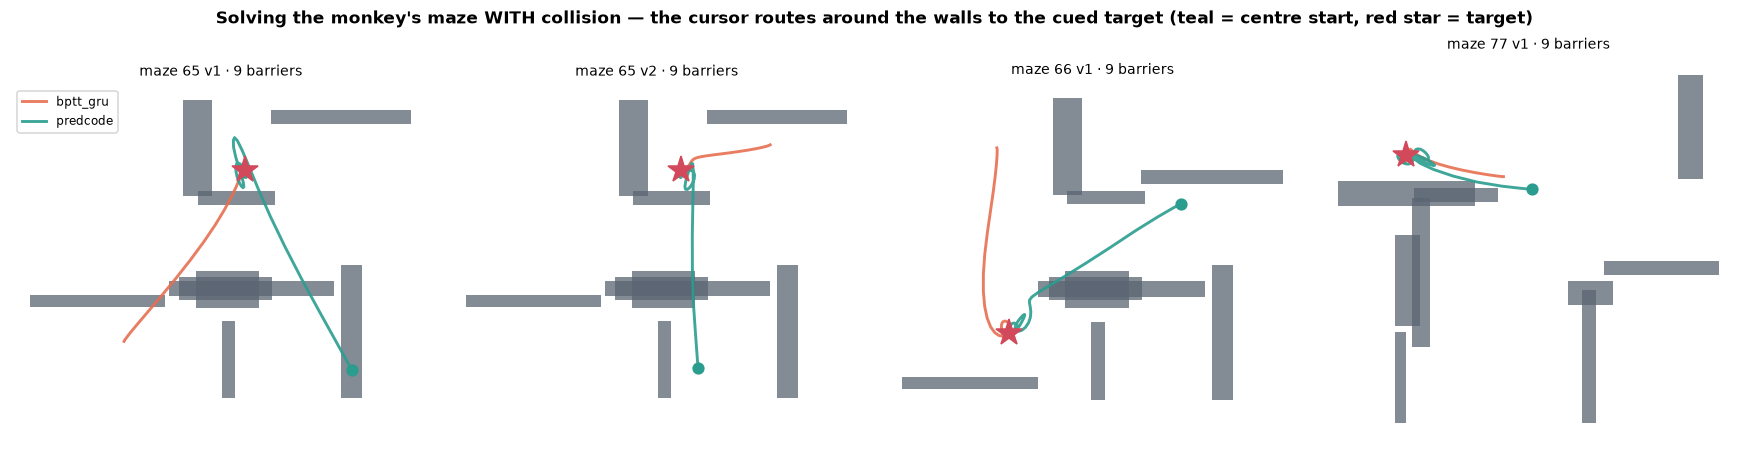

In [32]:
# === XIII.2  Watch the models solve the monkey's maze (collision ON) ========================
# SELF-CONTAINED. Roll out the best gradient + best plausible maze-trained model on the monkey's
# highest-barrier puzzles; the cursor must route AROUND the walls to the cued target.
import os, sys, json
import numpy as np, torch as th, matplotlib.pyplot as plt
sys.path.insert(0, os.getcwd()); sys.path.insert(0, os.path.join("..", "nlb_tools"))
import motor_zoo as mz, plausible_learners as pl, maze_env

_MDIR = os.path.join("..", "save_monkey", "maze_models")
_RESJ = os.path.join("..", "save_monkey", "maze_results.json")
CLS = dict(bptt_gru=mz.BPTTGRU, shac=mz.SHAC, sac=mz.SAC, fasttd3=mz.FastTD3, simbav2=mz.SimbaV2,
           kinesis=mz.Kinesis, dendritron=mz.Dendritron, eprop=pl.EProp, rtrrl=pl.RTRRL, btsp=pl.BTSP,
           rstdp=pl.RSTDP, predcode=pl.PredictiveCoding, hebb3=pl.Hebb3)
if not os.path.exists(_RESJ):
    print("Train the maze models first:  MZ_BUDGET=20000 python notebooks/maze_train.py")
else:
    env = maze_env.make_maze_env(mz.DEVICE, random_cond=False)
    pl.configure(mz.morph_head(env), mz.obs_norm, mz.OpCounter)
    MR = {r["tag"]: r for r in json.load(open(_RESJ))}
    def _load(tag):
        L = CLS[tag](env)
        L.load_state_dict(th.load(os.path.join(_MDIR, f"{tag}.pt"), map_location=mz.DEVICE), strict=False)
        return L
    _best = lambda kind: max((t for t in CLS if MR.get(t, {}).get("kind") == kind and os.path.exists(
        os.path.join(_MDIR, f"{t}.pt"))), key=lambda t: MR[t]["reach5"])
    picks = [(_best("global-gradient"), "#e76f51"), (_best("local-plausible"), "#2a9d8f")]
    models = {tag: _load(tag) for tag, _ in picks}

    @th.no_grad()
    def _run(L, ci, n=100):
        env.force_conditions([ci]); obs, info = env.reset(options={"batch_size": 1})
        st = L.init_state(1); p = [env.states["fingertip"][0].cpu().numpy()]
        for _ in range(n):
            a, st = L.act(obs, st); obs, *_ = env.step(a); p.append(env.states["fingertip"][0].cpu().numpy())
        return np.array(p)

    cfg = maze_env.extract_configs(); order = np.argsort(-cfg["n_barriers"])[:4]
    fig, axs = plt.subplots(1, 4, figsize=(16, 4.2))
    for ax, ci in zip(axs, order):
        env.force_conditions([ci]); env.reset(options={"batch_size": 1})
        bar = env._bar[env._cond][0].cpu().numpy(); msk = env._msk[env._cond][0].cpu().numpy()
        tg = env._tg[env._cond][0].cpu().numpy()
        for k in range(len(bar)):
            if msk[k]:
                cx, cy, hw, hh = bar[k]
                ax.add_patch(plt.Rectangle((cx - hw, cy - hh), 2 * hw, 2 * hh, fc="#5A6472", ec="none", alpha=.75))
        for tag, color in picks:
            p = _run(models[tag], ci)
            ax.plot(p[:, 0], p[:, 1], "-", color=color, lw=1.9, alpha=.9, label=tag)
        ax.plot(*p[0], "o", ms=7, color="#2A9D8F", zorder=6)          # start (centre-hold)
        ax.plot(*tg, "*", ms=18, color="#D1495B", zorder=6)           # cued target
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_title(f"maze {cfg['keys'][ci][0]} v{cfg['keys'][ci][1]} · {int(cfg['n_barriers'][ci])} barriers", fontsize=9)
    axs[0].legend(fontsize=8, loc="upper left")
    fig.suptitle("Solving the monkey's maze WITH collision — the cursor routes around the walls to the "
                 "cued target (teal = centre start, red star = target)", fontsize=11, fontweight="bold")
    plt.tight_layout(); plt.show()

# XIV. MC_Maze e-prop — train / evaluate / visualise (same modular functions, weights-path aware)

The four `maze_eprop` functions from `motornet_eprop.ipynb`, reusable here. `quantitative` and
`qualitative` accept a **weights path** (a trained e-prop checkpoint) so you can inspect a saved model
without retraining; `train` is the same e-prop trainer on the monkey's 108 MC-Maze puzzles.

e-prop / MC-Maze:   0%|          | 0/1500 [00:00<?, ?ep/s]

,success_%,error_cm,in_wall_%,reward,ms/episode
train,1.56,31.33,4.73,-57.37,72.89
val,1.17,28.83,5.22,-56.33,74.15
test,1.56,30.95,7.72,-58.53,73.14


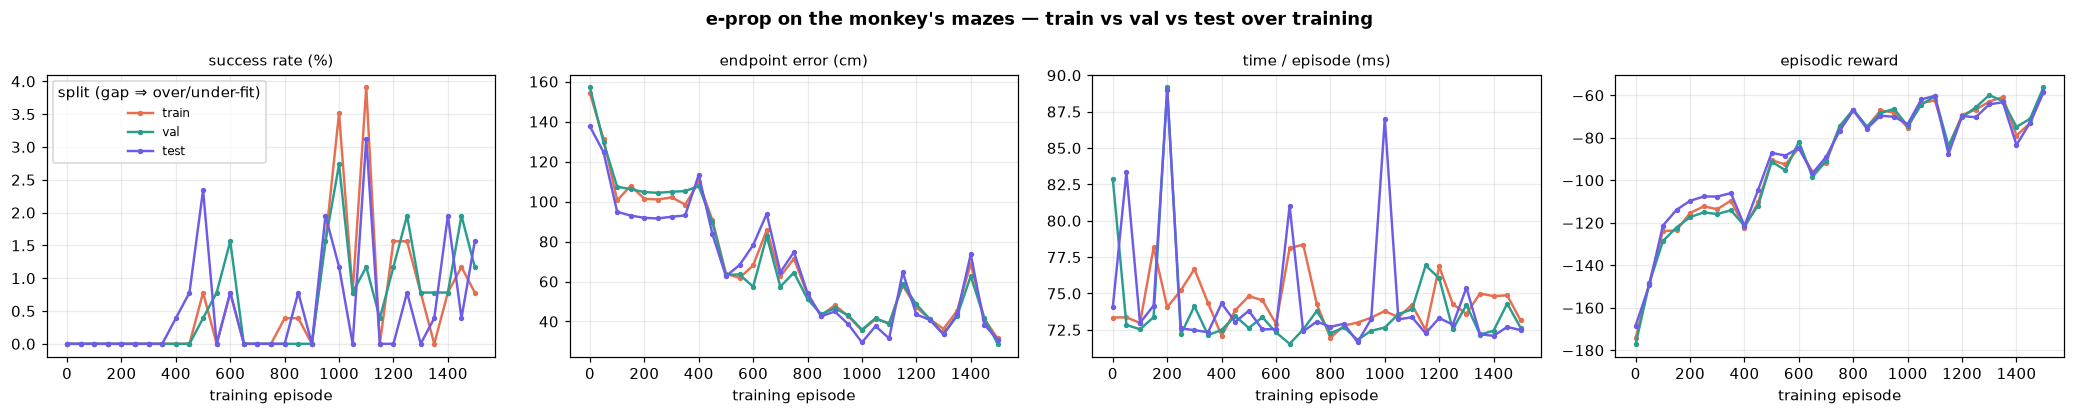

,success_%,error_cm,in_wall_%,reward,ms/episode
train,1.56,31.33,4.73,-57.37,75.77
val,1.17,28.83,5.22,-56.33,73.77
test,1.56,30.95,7.72,-58.53,73.27



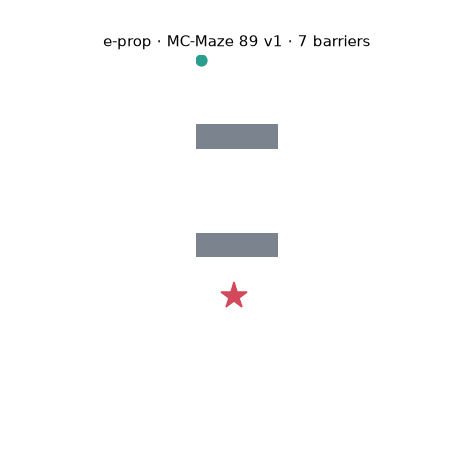

In [33]:
# === MC_Maze e-prop on the monkey's 108 mazes — pass a weights path, or train fresh ===
import os, sys
sys.path.insert(0, os.getcwd())
import maze_eprop

train_idx, val_idx, test_idx = maze_eprop.maze_split(seed=0)
EPROP_WEIGHTS = None      # <- set to a checkpoint path (e.g. "save/eprop_maze.pt") to skip training

if EPROP_WEIGHTS and os.path.exists(EPROP_WEIGHTS):
    policy = maze_eprop.load_eprop(EPROP_WEIGHTS)                 # inspect a trained e-prop, no retraining
else:
    policy, history = maze_eprop.train(train_idx, val_idx, test_idx, episodes=1500)
    maze_eprop.quantitative(policy, train_idx, val_idx, test_idx, history=history)  # curves: bias/variance/overfit
    import torch as th; os.makedirs("save", exist_ok=True); th.save(policy.state_dict(), "save/eprop_maze.pt")

maze_eprop.quantitative(policy, train_idx, val_idx, test_idx)     # success rate / error cm / time-per-episode
maze_eprop.show_gif(maze_eprop.qualitative(policy, maze_id=None, test_idx=test_idx))  # GIF (random test maze)